# HGQA mk08 — Classical Analysis: QUBO Tuning, GA Tuning & Pruning Effect

Pure classical solver — no quantum components.

| Section | Focus |
|---------|-------|
| 1 | Data → Grid → QUBO → Pruning (pipeline from mk07) |
| 2 | **QUBO parameter sensitivity** — how each weight/radius shifts the solution |
| 3 | GA hyperparameter tuning on the pruned QUBO |
| 4 | Pruning effect — GA on full N=196 vs pruned K |

**Key questions:**
- Which QUBO parameters matter most? Are the suggested values near-optimal?
- Which GA hyperparameters matter most for quality and speed?
- How much does pruning help — does it cost solution quality?

All results saved to `results/tuning/`.

In [1]:
import sys
from pathlib import Path

_proj_root = Path.cwd().parent
if str(_proj_root / 'src') not in sys.path:
    sys.path.insert(0, str(_proj_root / 'src'))

DATA_DIR = str(_proj_root / 'data')
print(f'Project root: {_proj_root}')
print(f'src in sys.path: {str(_proj_root / "src") in sys.path}')

Project root: /Users/abhimuvva/Documents/Proj_HGQA
src in sys.path: True


In [2]:
import math
import os
import time
import json as _json
import numpy as np
from datetime import datetime
from pathlib import Path as _Path
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from tabulate import tabulate

from data_loader import load_dataset, print_dataset_summary
from helpers import (
    divide_graph_into_parts,
    calculate_cell_weights,
    plot_cell_weights,
    plot_qubo_diagonal,
    print_weight_summary,
    suggest_parameters,
    print_parameter_suggestions,
)
from qubo_builder import build_qubo, calibrate_alphas, print_qubo_diagnostics
from cell_pruner import prune_cells, remap_qubo_for_qaoa, compute_solo_scores
from ga_solver import run_ga

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# All tunable knobs — change here, re-run everything below
# ─────────────────────────────────────────────────────────────────────────────

# ── Dataset registry ──────────────────────────────────────────────────────────
# Paths are relative to DATA_DIR (data/).
# n_qubits is scaled by area from medium city (14×14=196q baseline):
#   small  25×27 → 10×10 = 100q  |  medium 28×27 → 14×14 = 196q
#   large  35×30 → 16×16 = 256q  |  metro  40×35 → 18×18 = 324q
DATASETS = {
    # ── Medium city  (196q, m=5, x=[0,28], y=[0,27]) ─────────────────────────
    'medium_city_polycentric':         {'file': 'dataset_medium_city_polycentric.xlsx',                          'n_qubits': 196},
    'medium_city_corridor':            {'file': 'dataset_medium_city_corridor.xlsx',                             'n_qubits': 196},
    'medium_city_dense_core':          {'file': 'dataset_medium_city_dense_core.xlsx',                           'n_qubits': 196},
    'medium_city_edge_growth':         {'file': 'dataset_medium_city_edge_growth.xlsx',                          'n_qubits': 196},
    'medium_city_sparse_suburban':     {'file': 'dataset_medium_city_sparse_suburban.xlsx',                      'n_qubits': 196},
    'medium_city_underserved_corner':  {'file': 'dataset_medium_city_underserved_corner.xlsx',                   'n_qubits': 196},
    'medium_city':                     {'file': 'dataset_medium_city.xlsx',                                      'n_qubits': 196},
    # ── Small city   (100q, m=4, x=[0,25], y=[0,27]) ─────────────────────────
    'small_city_polycentric':          {'file': 'small_city/dataset_small_city_polycentric.xlsx',                'n_qubits': 100},
    'small_city_corridor':             {'file': 'small_city/dataset_small_city_corridor.xlsx',                   'n_qubits': 100},
    'small_city_dense_core':           {'file': 'small_city/dataset_small_city_dense_core.xlsx',                 'n_qubits': 100},
    'small_city_edge_growth':          {'file': 'small_city/dataset_small_city_edge_growth.xlsx',                'n_qubits': 100},
    'small_city_sparse_suburban':      {'file': 'small_city/dataset_small_city_sparse_suburban.xlsx',            'n_qubits': 100},
    'small_city_underserved_corner':   {'file': 'small_city/dataset_small_city_underserved_corner.xlsx',         'n_qubits': 100},
    'small_city':                      {'file': 'small_city/dataset_small_city.xlsx',                            'n_qubits': 100},
    # ── Large city   (256q, m=7, x=[0,35], y=[0,30]) ─────────────────────────
    'large_city_polycentric':          {'file': 'large_city/dataset_large_city_polycentric.xlsx',                'n_qubits': 256},
    'large_city_corridor':             {'file': 'large_city/dataset_large_city_corridor.xlsx',                   'n_qubits': 256},
    'large_city_dense_core':           {'file': 'large_city/dataset_large_city_dense_core.xlsx',                 'n_qubits': 256},
    'large_city_edge_growth':          {'file': 'large_city/dataset_large_city_edge_growth.xlsx',                'n_qubits': 256},
    'large_city_sparse_suburban':      {'file': 'large_city/dataset_large_city_sparse_suburban.xlsx',            'n_qubits': 256},
    'large_city_underserved_corner':   {'file': 'large_city/dataset_large_city_underserved_corner.xlsx',         'n_qubits': 256},
    'large_city':                      {'file': 'large_city/dataset_large_city.xlsx',                            'n_qubits': 256},
    # ── Metro region (324q, m=10, x=[0,40], y=[0,35]) ────────────────────────
    'metro_region_polycentric':        {'file': 'metro_region/dataset_metro_region_polycentric.xlsx',            'n_qubits': 324},
    'metro_region_corridor':           {'file': 'metro_region/dataset_metro_region_corridor.xlsx',               'n_qubits': 324},
    'metro_region_dense_core':         {'file': 'metro_region/dataset_metro_region_dense_core.xlsx',             'n_qubits': 324},
    'metro_region_edge_growth':        {'file': 'metro_region/dataset_metro_region_edge_growth.xlsx',            'n_qubits': 324},
    'metro_region_sparse_suburban':    {'file': 'metro_region/dataset_metro_region_sparse_suburban.xlsx',        'n_qubits': 324},
    'metro_region_underserved_corner': {'file': 'metro_region/dataset_metro_region_underserved_corner.xlsx',     'n_qubits': 324},
    'metro_region':                    {'file': 'metro_region/dataset_metro_region.xlsx',                        'n_qubits': 324},
}

# ── Active dataset for interactive exploration (Sections 1–4) ─────────────────
SELECTED_DATASET = 'medium_city_polycentric'
DATASET_FILE     = os.path.join(DATA_DIR, DATASETS[SELECTED_DATASET]['file'])
N_QUBITS         = DATASETS[SELECTED_DATASET]['n_qubits']

# ── Grid / pruning knobs ──────────────────────────────────────────────────────
SCALE_FACTOR = 5.0
MIN_WEIGHT   = 0.5
TIER3_KEEP   = 3

# ── GA baseline (used for interactive exploration AND batch runner) ────────────
BASELINE = dict(
    population_size = 50,
    n_generations   = 300,
    crossover_rate  = 0.8,
    mutation_rate   = 0.2,
    tournament_size = 3,
    seed_mode       = 'greedy',
)

# ── Reproducibility ───────────────────────────────────────────────────────────
N_SEEDS = 5
SEEDS   = list(range(N_SEEDS))

# ── GA hyperparameter sweep ranges (Section 3 + batch runner) ─────────────────
SWEEP_VALUES = {
    'population_size': [20, 50, 100, 200],
    'n_generations':   [50, 100, 200, 500],
    'crossover_rate':  [0.5, 0.6, 0.7, 0.8, 0.9],
    'mutation_rate':   [0.05, 0.1, 0.15, 0.2, 0.3],
    'tournament_size': [2, 3, 5, 7, 10],
}

# ── QUBO parameter sweep ranges (Section 2 + batch runner) ───────────────────
QUBO_SWEEP_VALUES = {
    'alpha1': [1.0, 2.0, 3.0, 4.0, 5.0],    # H1 POI-attraction weight
    'alpha4': [0.5, 1.0, 1.5, 2.0, 3.0],    # H4 charger-spacing penalty
    'alpha3': [0.5, 0.8, 1.1, 1.5, 2.0],    # H3 existing-charger penalty
    'alpha6': [0.05, 0.15, 0.35, 0.5, 0.8], # H6 coverage-redundancy penalty
    'R1':     [2, 3, 4, 5, 6],              # H1 POI-attraction radius
    'R4':     [1, 2, 3, 4],                 # H4 spacing radius (also controls Tier-1 pruning)
}

print('Configuration loaded.')
print(f'  Interactive dataset : {SELECTED_DATASET}  ({N_QUBITS}q)')
print(f'  Batch datasets ({len(DATASETS)}) :')
by_family = {}
for name, cfg in DATASETS.items():
    family = name.rsplit('_', 2)[0] if '_city' in name or '_region' in name else name
    fam_key = 'medium_city' if name.startswith('medium') else ('small_city' if name.startswith('small') else ('large_city' if name.startswith('large') else 'metro_region'))
    by_family.setdefault(fam_key, []).append(name)
for fam, names in by_family.items():
    cfg0 = DATASETS[names[0]]
    print(f'    {fam} ({cfg0["n_qubits"]}q): {len(names)} variants')
print(f'  Baseline GA         : {BASELINE}')
print(f'  N_SEEDS             : {N_SEEDS}')


Configuration loaded.
  Interactive dataset : medium_city_polycentric  (196q)
  Batch datasets (28) :
    medium_city (196q): 7 variants
    small_city (100q): 7 variants
    large_city (256q): 7 variants
    metro_region (324q): 7 variants
  Baseline GA         : {'population_size': 50, 'n_generations': 300, 'crossover_rate': 0.8, 'mutation_rate': 0.2, 'tournament_size': 3, 'seed_mode': 'greedy'}
  N_SEEDS             : 5


Dataset: medium_city_polycentric
  27 POIs across downtown, hospital/university, retail, and residential districts; mixed dense and moderate clusters, m=5.
  Area: [0.0, 28.0] × [0.0, 27.0]
  POIs: 27  |  Chargers: 6  |  Gas: 5  |  m=5
  Density range: [0.34, 0.96]  mean=0.63


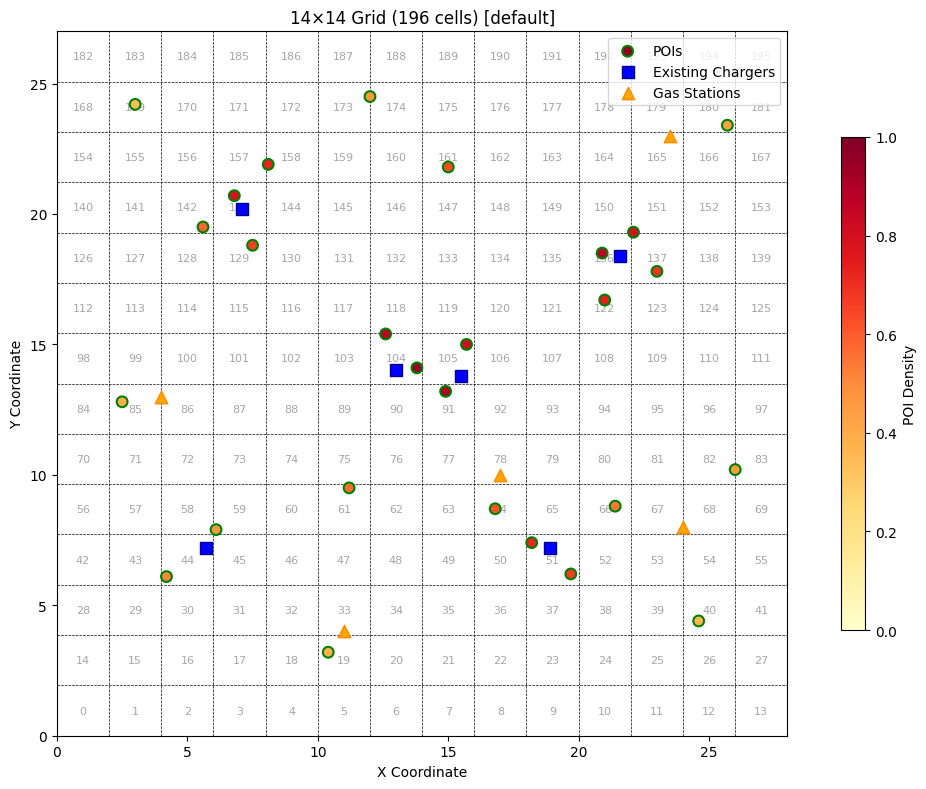

  Grid Info:
    Grid   19 (row=1, col=5): 1 POI(s) [densities: 0.38]
    Grid   33 (row=2, col=5): 1 gas station(s)
    Grid   40 (row=2, col=12): 1 POI(s) [densities: 0.36]
    Grid   44 (row=3, col=2): 1 POI(s) [densities: 0.51] | 1 charger(s)
    Grid   51 (row=3, col=9): 2 POI(s) [densities: 0.72, 0.67] | 1 charger(s)
    Grid   59 (row=4, col=3): 1 POI(s) [densities: 0.47]
    Grid   61 (row=4, col=5): 1 POI(s) [densities: 0.57]
    Grid   64 (row=4, col=8): 1 POI(s) [densities: 0.61]
    Grid   66 (row=4, col=10): 1 POI(s) [densities: 0.54]
    Grid   68 (row=4, col=12): 1 gas station(s)
    Grid   78 (row=5, col=8): 1 gas station(s)
    Grid   83 (row=5, col=13): 1 POI(s) [densities: 0.45]
    Grid   85 (row=6, col=1): 1 POI(s) [densities: 0.40]
    Grid   86 (row=6, col=2): 1 gas station(s)
    Grid   91 (row=6, col=7): 1 POI(s) [densities: 0.91]
    Grid  104 (row=7, col=6): 2 POI(s) [densities: 0.96, 0.88] | 1 charger(s)
    Grid  105 (row=7, col=7): 1 POI(s) [densities: 0.8

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Load dataset + grid + cell weights + parameter suggestions
# ─────────────────────────────────────────────────────────────────────────────

data = load_dataset(DATASET_FILE)
print_dataset_summary(data)

points_of_interest       = data['pois']
existing_charging_points = data['existing_chargers']
gas_stations             = data['gas_stations']
M                        = data['m']
X_MIN, X_MAX             = data['x_min'], data['x_max']
Y_MIN, Y_MAX             = data['y_min'], data['y_max']

grid_details, plot_deets = divide_graph_into_parts(
    x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX,
    num_qubits=N_QUBITS,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    grid_division='default',
)

cell_weights = calculate_cell_weights(
    grid_details, scale_factor=SCALE_FACTOR, min_weight=MIN_WEIGHT
)
print_weight_summary(cell_weights, grid_details, top_n=5)

params = suggest_parameters(grid_details, cell_weights, plot_deets, m=M)
a          = params['alpha']
r          = params['radii']
t          = params['intra']
lambda_val = params['lambda']

print(f'\nSuggested λ={lambda_val}  R1={r["R1"]}  R4={r["R4"]}  R6={r["R6"]}')

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. QUBO construction + calibration
# ─────────────────────────────────────────────────────────────────────────────

Q_obj, h5_params, diags = build_qubo(
    grid_details, cell_weights, plot_deets, m=M,
    alpha1=a['a1'], alpha2=a['a2'], alpha3=a['a3'],
    alpha4=a['a4'], alpha5=a['a5'], alpha6=a['a6'],
    beta=t['beta'], gamma=t['gamma'], delta=t['delta'], epsilon=t['epsilon'],
    lam=lambda_val,
    R1=r['R1'], Rs=r['Rs'], R3=r['R3'], R4=r['R4'], R6=r['R6'],
)

params_flat = {
    'alpha1': a['a1'], 'alpha2': a['a2'], 'alpha3': a['a3'],
    'alpha4': a['a4'], 'alpha5': a['a5'], 'alpha6': a['a6'],
    'beta': t['beta'], 'gamma': t['gamma'], 'delta': t['delta'], 'epsilon': t['epsilon'],
    'lam': lambda_val,
    'R1': r['R1'], 'Rs': r['Rs'], 'R3': r['R3'], 'R4': r['R4'], 'R6': r['R6'],
}

params_flat, needs_rebuild = calibrate_alphas(Q_obj, params_flat, diags, verbose=True)
if needs_rebuild:
    print('\nRebuilding Q_obj with calibrated parameters...')
    Q_obj, h5_params, diags = build_qubo(
        grid_details, cell_weights, plot_deets, m=M, **params_flat,
    )
    print('Rebuild complete.')

print(f'Q_obj entries: {len(Q_obj)}')

CALIBRATE_ALPHAS
  Diagonal peak:  3.0000
  Target (×0.5): 1.5000
  H4 actual peak: 0.7500  ✓ OK
  H6 actual peak: 1.5001  ✓ OK
  → No rebuild needed.
Q_obj entries: 2136


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Cell pruning — three-tier
# ─────────────────────────────────────────────────────────────────────────────

surviving_cells, prune_report = prune_cells(
    Q_obj, N=N_QUBITS, m=M,
    num_cols=plot_deets['num_cols'],
    R4=r['R4'],
    tier3_keep=TIER3_KEEP,
    verbose=True,
)

K = len(surviving_cells)
print(f'\nPruning result: {N_QUBITS} → {K} cells ({100*(1-K/N_QUBITS):.0f}% reduction)')
print(f'Search space: C({N_QUBITS},{M})={math.comb(N_QUBITS,M):,} → C({K},{M})={math.comb(K,M):,}')

CELL PRUNING
  Starting cells: 196
  Solo scores: 196 negative, 0 zero, 0 positive
  Solo range: [-3.0000, -0.0537]

  Tier 1 (dead cells): 0 pruned, 196 remain  (0 zero-solo cells kept near competitive)
  Tier 2 (bound elim): 151 pruned, 45 remain  (ref score=-11.9530)
  Tier 3 (dedup):      0 pruned, 45 remain  (36 clusters, sizes=[1, 1, 3, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 4, 1, 1, 1, 1, 1, 1, 1, 1])

  RESULT: 196 → 45 cells (77% reduction)
  Surviving IDs: [51, 61, 62, 63, 64, 75, 76, 77, 78, 79, 80, 91, 92, 93, 94, 95, 102, 104, 105, 106, 107, 108, 109, 115, 116, 120, 121, 122, 129, 131, 132, 133, 134, 136, 137, 143, 145, 146, 147, 148, 151, 161, 162, 164, 165]
  Solo scores: [np.float64(-2.0029), np.float64(-1.7631), np.float64(-1.6842), np.float64(-1.6939), np.float64(-1.7547), np.float64(-1.7229), np.float64(-2.0995), np.float64(-2.2761), np.float64(-2.6768), np.float64(-2.1906), np.float64(-1.8192), np.float64(-2.2671), np.float64(-1.7196

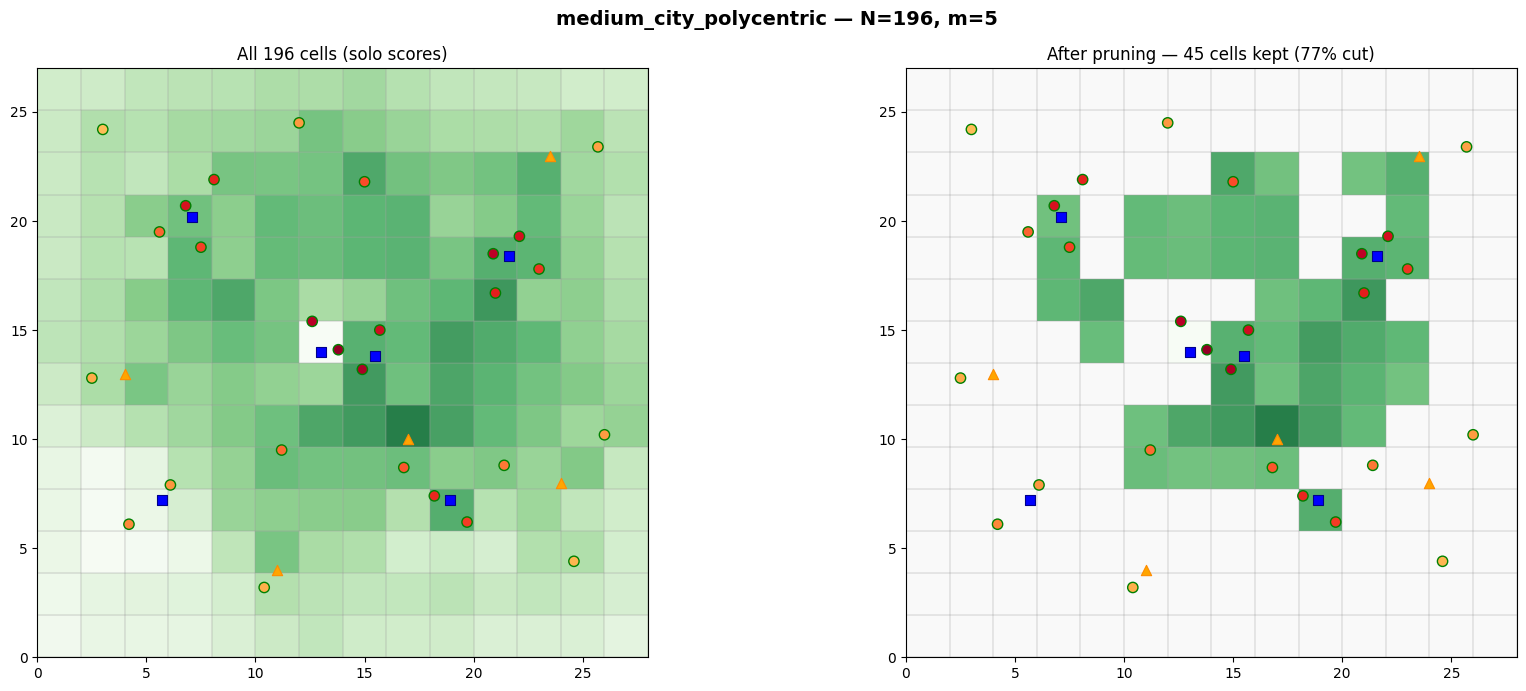

  Tier 1 (dead cells) : 0 pruned
  Tier 2 (bound elim) : 151 pruned
  Tier 3 (dedup)      : 0 pruned
  Final               : 196 → 45 cells


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Pruning before / after visualization
# ─────────────────────────────────────────────────────────────────────────────

solos    = compute_solo_scores(Q_obj, N_QUBITS)
num_rows = plot_deets['num_rows']
num_cols = plot_deets['num_cols']
cell_w   = plot_deets['cell_w']
cell_h   = plot_deets['cell_h']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, title, highlight in zip(
    axes,
    [f'All {N_QUBITS} cells (solo scores)', f'After pruning — {K} cells kept ({100*(1-K/N_QUBITS):.0f}% cut)'],
    [set(range(N_QUBITS)), set(surviving_cells)],
):
    ax.set_facecolor('white')
    for i in range(num_cols + 1):
        ax.axvline(X_MIN + i * cell_w, color='gray', linewidth=0.2)
    for j in range(num_rows + 1):
        ax.axhline(Y_MIN + j * cell_h, color='gray', linewidth=0.2)
    for gid, info in grid_details.items():
        if gid in highlight:
            norm  = max(0, min(1, -solos[gid] / 3.0))
            color = plt.cm.Greens(norm)
            alpha = 0.85
        else:
            color = (0.93, 0.93, 0.93)
            alpha = 0.3
        ax.add_patch(plt.Rectangle(
            (info['x_start'], info['y_start']), cell_w, cell_h,
            facecolor=color, alpha=alpha, edgecolor='lightgray', linewidth=0.15,
        ))
    if points_of_interest:
        ax.scatter([p[0] for p in points_of_interest], [p[1] for p in points_of_interest],
                   c=[p[2] for p in points_of_interest], cmap='YlOrRd',
                   edgecolors='green', linewidths=1, s=55, vmin=0, vmax=1, zorder=5)
    if existing_charging_points:
        ax.scatter(*zip(*existing_charging_points), color='blue', marker='s',
                   s=55, zorder=5, edgecolors='darkblue', linewidths=0.8)
    if gas_stations:
        ax.scatter(*zip(*gas_stations), color='orange', marker='^',
                   s=55, zorder=5, edgecolors='darkorange', linewidths=0.8)
    ax.set_xlim(X_MIN, X_MAX); ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_title(title, fontsize=12); ax.set_aspect('equal')

plt.suptitle(f"{data['dataset_name']} — N={N_QUBITS}, m={M}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'  Tier 1 (dead cells) : {prune_report["tier1"]["pruned"]} pruned')
print(f'  Tier 2 (bound elim) : {prune_report["tier2"]["pruned"]} pruned')
print(f'  Tier 3 (dedup)      : {prune_report["tier3"]["pruned"]} pruned')
print(f'  Final               : {N_QUBITS} → {K} cells')

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. Remap QUBO to pruned qubit space 0..K-1
# ─────────────────────────────────────────────────────────────────────────────

Q_pruned, cell_to_qubit, qubit_to_cell = remap_qubo_for_qaoa(Q_obj, surviving_cells)

print(f'Remapped: {N_QUBITS} → {K} qubits')
print(f'Q_pruned entries : {len(Q_pruned)}')
print(f'Q_obj entries    : {len(Q_obj)}')
print(f'Surviving IDs    : {surviving_cells[:10]}...')

Remapped: 196 → 45 qubits
Q_pruned entries : 314
Q_obj entries    : 2136
Surviving IDs    : [51, 61, 62, 63, 64, 75, 76, 77, 78, 79]...


---
## Section 2 — QUBO Parameter Sensitivity

We sweep the six most impactful QUBO parameters one at a time, keeping all others at the auto-suggested baseline.  
For each parameter value we: **rebuild the QUBO → re-prune → run GA × N_SEEDS seeds**.

| Parameter | Controls | Baseline |
|-----------|----------|---------|
| `alpha1` | H1 POI-attraction weight (dominant term) | ~3.0 |
| `alpha4` | H4 charger-spacing penalty | ~1.5 |
| `alpha3` | H3 existing-charger penalty | ~1.1 |
| `alpha6` | H6 coverage-redundancy penalty | ~0.35 |
| `R1` | H1 POI-attraction radius (cells) | 4 |
| `R4` | H4 spacing radius (cells) | 2 |

**Cross-evaluation metric**: every found solution is also scored against the *baseline* Q_obj so results are comparable across parameter values.  
**H-term decomposition**: H1, H4, H6 contributions are isolated by rebuilding term-specific QUBOs with the baseline params.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 2 helpers — QUBO sweep functions
# QUBO_SWEEP_VALUES is defined in mk08-config above.
# ─────────────────────────────────────────────────────────────────────────────

# Snapshot of baseline QUBO params (set after calibrate_alphas in mk08-qubo)
_BASE_PARAMS = dict(params_flat)

ALL_QUBO_SWEEP_RESULTS = {}


def eval_on_q(Q, cells):
    """Score a solution (original cell IDs) on any Q dict."""
    cells_set = set(cells)
    score = 0.0
    for (i, j), v in Q.items():
        if i == j:
            if i in cells_set: score += v
        else:
            if i in cells_set and j in cells_set: score += v
    return score


def term_contributions(cells, base_params):
    """H1, H4, H6 contributions evaluated on isolated single-term QUBOs."""
    def _iso(**kw):
        p = {**base_params, **kw}
        Q_iso, _, _ = build_qubo(grid_details, cell_weights, plot_deets, m=M, **p)
        return Q_iso
    Q_h1 = _iso(alpha2=0, alpha3=0, alpha4=0, alpha6=0)
    Q_h4 = _iso(alpha1=0, alpha2=0, alpha3=0, alpha6=0)
    Q_h6 = _iso(alpha1=0, alpha2=0, alpha3=0, alpha4=0)
    return {'H1': eval_on_q(Q_h1, cells), 'H4': eval_on_q(Q_h4, cells), 'H6': eval_on_q(Q_h6, cells)}


def rebuild_and_run(override_params, label=''):
    """
    Rebuild QUBO with overridden params, prune, remap, run GA N_SEEDS times.
    Returns both pruning stats (K, tier counts) and solution stats (scores, runs).
    """
    params   = {**_BASE_PARAMS, **override_params}
    prune_R4 = override_params.get('R4', _BASE_PARAMS.get('R4', r['R4']))

    Q_new, _, _ = build_qubo(grid_details, cell_weights, plot_deets, m=M, **params)

    surviving_new, prune_rep = prune_cells(
        Q_new, N=N_QUBITS, m=M,
        num_cols=plot_deets['num_cols'],
        R4=prune_R4, tier3_keep=TIER3_KEEP, verbose=False,
    )
    K_new = len(surviving_new)

    if K_new < M:
        print(f'  SKIP: K={K_new} < m={M} — params too extreme.')
        return None

    Q_pr_new, _, q2c_new = remap_qubo_for_qaoa(Q_new, surviving_new)

    runs = [run_ga(Q_pr_new, q2c_new, K=K_new, m=M, **BASELINE, verbose=False, seed=s)
            for s in SEEDS]

    best_run   = min(runs, key=lambda x: x['best_score'])
    best_cells = best_run['best_solution']

    return {
        # ── Pruning stats ──────────────────────────────────────────────────
        'K':             K_new,
        'surviving':     surviving_new,
        'tier1_pruned':  prune_rep['tier1']['pruned'],
        'tier2_pruned':  prune_rep['tier2']['pruned'],
        'tier3_pruned':  prune_rep['tier3']['pruned'],
        # ── Solution stats ─────────────────────────────────────────────────
        'runs':          runs,
        'best_cells':    best_cells,
        'best_score':    best_run['best_score'],
        'mean_score':    float(np.mean([x['best_score'] for x in runs])),
        'std_score':     float(np.std([x['best_score']  for x in runs])),
        'baseline_eval': eval_on_q(Q_obj, best_cells),
        'terms':         term_contributions(best_cells, _BASE_PARAMS),
        'mean_time':     float(np.mean([x['runtime_sec'] for x in runs])),
        'label':         label,
    }


def _nearest(values, target):
    return min(values, key=lambda x: abs(float(x) - float(target)))


def plot_qubo_sweep(sweep_data, param_name, baseline_val):
    """
    2-row × 3-column figure.

    Row 1 — PRUNING
      [0,0] K (surviving cells) bar chart
      [0,1] Per-tier pruning breakdown  (Tier 1 / 2 / 3 stacked bar)
      [0,2] Pruning % reduction + total pruned line

    Row 2 — SOLUTION QUALITY
      [1,0] Baseline cross-eval score  (cross-comparable quality metric)
      [1,1] Convergence curves         (one mean±σ band per param value)
      [1,2] H-term breakdown           (H1 / H4 / H6 grouped bar)
    """
    values       = sorted(sweep_data.keys())
    cmap         = plt.colormaps['viridis']
    colors       = [cmap(x) for x in np.linspace(0.15, 0.85, len(values))]
    str_v        = [str(v) for v in values]
    nearest_base = _nearest(values, baseline_val)
    N_total      = N_QUBITS

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    (ax_k, ax_tier, ax_pct), (ax_eval, ax_conv, ax_hterm) = axes

    Ks   = [sweep_data[v]['K']             for v in values]
    t1s  = [sweep_data[v].get('tier1_pruned', 0) for v in values]
    t2s  = [sweep_data[v].get('tier2_pruned', 0) for v in values]
    t3s  = [sweep_data[v].get('tier3_pruned', 0) for v in values]
    pcts = [100 * (1 - k / N_total) for k in Ks]
    evals = [sweep_data[v]['baseline_eval'] for v in values]
    h1s   = [sweep_data[v]['terms']['H1'] for v in values]
    h4s   = [sweep_data[v]['terms']['H4'] for v in values]
    h6s   = [sweep_data[v]['terms']['H6'] for v in values]

    # ── [0,0] K bar ──────────────────────────────────────────────────────────
    bars = ax_k.bar(str_v, Ks, color=colors, edgecolor='navy', lw=0.8, alpha=0.85)
    if nearest_base in values:
        bars[values.index(nearest_base)].set_edgecolor('red')
        bars[values.index(nearest_base)].set_linewidth(2.5)
    for i, v in enumerate(Ks):
        ax_k.text(i, v + 0.3, str(v), ha='center', va='bottom', fontsize=9)
    ax_k.set_xlabel(param_name); ax_k.set_ylabel('Surviving cells K')
    ax_k.set_title(f'PRUNING — K vs {param_name}', fontsize=11, fontweight='bold')
    ax_k.grid(True, alpha=0.2, axis='y')

    # ── [0,1] Tier stacked bar ────────────────────────────────────────────────
    xi = np.arange(len(values))
    ax_tier.bar(xi, t1s, label='Tier 1 (dead cells)',    color='#B0BEC5', edgecolor='navy', lw=0.6)
    ax_tier.bar(xi, t2s, bottom=t1s,               label='Tier 2 (bound elim)', color='#607D8B', edgecolor='navy', lw=0.6)
    t12 = [a + b for a, b in zip(t1s, t2s)]
    ax_tier.bar(xi, t3s, bottom=t12,               label='Tier 3 (spatial dedup)', color='#37474F', edgecolor='navy', lw=0.6)
    ax_tier.set_xticks(xi); ax_tier.set_xticklabels(str_v)
    ax_tier.set_xlabel(param_name); ax_tier.set_ylabel('Cells pruned per tier')
    ax_tier.set_title(f'PRUNING — Tier breakdown vs {param_name}', fontsize=11, fontweight='bold')
    ax_tier.legend(fontsize=9); ax_tier.grid(True, alpha=0.2, axis='y')

    # ── [0,2] % reduction line ────────────────────────────────────────────────
    ax_pct.plot(str_v, pcts, 'D-', color='#546E7A', lw=2.2, ms=8)
    ax_pct.fill_between(range(len(values)), pcts, alpha=0.15, color='#546E7A')
    for i, (p, k) in enumerate(zip(pcts, Ks)):
        ax_pct.text(i, p + 0.5, f'{p:.0f}%', ha='center', va='bottom', fontsize=9)
    if nearest_base in values:
        ax_pct.axvline(values.index(nearest_base), color='red', ls=':', lw=1.5, alpha=0.7)
    ax_pct.set_xlabel(param_name); ax_pct.set_ylabel('% cells pruned')
    ax_pct.set_title(f'PRUNING — Reduction % vs {param_name}', fontsize=11, fontweight='bold')
    ax_pct.grid(True, alpha=0.2)

    # ── [1,0] Baseline cross-eval score ──────────────────────────────────────
    ax_eval.plot(str_v, evals, 'o-', color='steelblue', lw=2.2, ms=9,
                 label='Baseline Q eval  (cross-comparable)')
    if nearest_base in values:
        ax_eval.axvline(values.index(nearest_base), color='red', ls=':', lw=1.5,
                        alpha=0.6, label=f'Nearest baseline ({nearest_base})')
    ax_eval.set_xlabel(param_name); ax_eval.set_ylabel('Score on baseline Q  (lower = better)')
    ax_eval.set_title(f'SOLUTION — Cross-eval quality vs {param_name}', fontsize=11, fontweight='bold')
    ax_eval.legend(fontsize=9); ax_eval.grid(True, alpha=0.2)

    # ── [1,1] Convergence curves ──────────────────────────────────────────────
    for val, color in zip(values, colors):
        runs = sweep_data[val].get('runs', [])
        if not runs: continue
        curves = [rr['convergence'] for rr in runs]
        ml = max(len(c) for c in curves)
        padded = np.array([c + [c[-1]] * (ml - len(c)) for c in curves])
        mean = padded.mean(0); std = padded.std(0)
        gens = np.arange(1, ml + 1)
        lbl  = f'{param_name}={val}' + ('  *'if val == nearest_base else '')
        lw   = 2.5 if val == nearest_base else 1.8
        ax_conv.plot(gens, mean, color=color, lw=lw, label=lbl)
        ax_conv.fill_between(gens, mean - std, mean + std, color=color, alpha=0.12)
    ax_conv.set_xlabel('Generation'); ax_conv.set_ylabel('Best score (own QUBO)')
    ax_conv.set_title(f'SOLUTION — Convergence vs {param_name}', fontsize=11, fontweight='bold')
    ax_conv.legend(fontsize=8.5); ax_conv.grid(True, alpha=0.2)

    # ── [1,2] H-term breakdown ────────────────────────────────────────────────
    xi2 = np.arange(len(values)); w = 0.25
    ax_hterm.bar(xi2 - w, h1s, w, label='H1 attraction', color='#43A047', alpha=0.85)
    ax_hterm.bar(xi2,     h4s, w, label='H4 spacing',    color='#E53935', alpha=0.85)
    ax_hterm.bar(xi2 + w, h6s, w, label='H6 coverage',   color='#1E88E5', alpha=0.85)
    ax_hterm.set_xticks(xi2); ax_hterm.set_xticklabels(str_v)
    ax_hterm.axhline(0, color='black', lw=0.7)
    ax_hterm.set_xlabel(param_name); ax_hterm.set_ylabel('H-term contribution (baseline eval)')
    ax_hterm.set_title(f'SOLUTION — H-term breakdown vs {param_name}', fontsize=11, fontweight='bold')
    ax_hterm.legend(fontsize=9); ax_hterm.grid(True, alpha=0.2, axis='y')

    fig.suptitle(
        f'QUBO Sweep: {param_name} — {data["dataset_name"]}  m={M}  seeds={N_SEEDS}\n'
        f'Row 1: PRUNING  |  Row 2: SOLUTION QUALITY',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    return fig


def plot_solution_comparison(sweep_data, param_name, baseline_val):
    """Small grid maps side-by-side showing charger placement for each param value."""
    values = sorted(sweep_data.keys())
    n = len(values)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4.2))
    if n == 1:
        axes = [axes]
    nearest_base = _nearest(values, baseline_val)
    for ax, val in zip(axes, values):
        d        = sweep_data[val]
        best_set = set(d['best_cells'])
        surv_set = set(d['surviving'])
        ax.set_facecolor('#f0f0f0')
        for gid, info in grid_details.items():
            cx, cy = info['x_start'], info['y_start']
            col, al = ('gold', 0.95) if gid in best_set else (('#c8e6c9', 0.55) if gid in surv_set else ('#dddddd', 0.25))
            ax.add_patch(plt.Rectangle((cx, cy), cell_w, cell_h, facecolor=col, alpha=al,
                                       edgecolor='lightgray', linewidth=0.08))
        if points_of_interest:
            ax.scatter([p[0] for p in points_of_interest], [p[1] for p in points_of_interest],
                       c=[p[2] for p in points_of_interest], cmap='YlOrRd',
                       edgecolors='none', s=18, vmin=0, vmax=1, zorder=5, alpha=0.75)
        ax.set_xlim(X_MIN, X_MAX); ax.set_ylim(Y_MIN, Y_MAX)
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
        is_base = (val == nearest_base)
        pct     = 100 * (1 - d['K'] / N_QUBITS)
        ttl     = (f'{param_name}={val}{"  *" if is_base else ""}\n'
                   f'K={d["K"]} ({pct:.0f}% pruned)  eval={d["baseline_eval"]:.3f}')
        ax.set_title(ttl, fontsize=8.5,
                     fontweight='bold' if is_base else 'normal',
                     color='darkred' if is_base else 'black')
    fig.suptitle(
        f'{param_name} sweep — charger placement  '
        f'(gold=selected, green=surviving, gray=pruned)',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    return fig


def print_qubo_sweep_table(sweep_data, param_name, baseline_val):
    """Summary table showing both pruning and solution stats per param value."""
    nearest_base = _nearest(sorted(sweep_data.keys()), baseline_val)
    rows = []
    for val in sorted(sweep_data.keys()):
        d   = sweep_data[val]
        tot = d.get('tier1_pruned', 0) + d.get('tier2_pruned', 0) + d.get('tier3_pruned', 0)
        pct = 100 * (1 - d['K'] / N_QUBITS)
        mk  = '*' if val == nearest_base else '' 
        rows.append([
            f'{val}{mk}',
            f'{d["K"]} ({pct:.0f}%)'  ,
            d.get('tier1_pruned', 0), d.get('tier2_pruned', 0), d.get('tier3_pruned', 0),
            f'{d["best_score"]:.4f}',
            f'{d["mean_score"]:.4f} ±{d["std_score"]:.4f}',
            f'{d["baseline_eval"]:.4f}',
            f'{d["terms"]["H1"]:.3f}',
            f'{d["terms"]["H4"]:.3f}',
            f'{d["terms"]["H6"]:.3f}',
        ])
    print(tabulate(rows,
                   headers=[param_name, 'K (pruned%)',
                             'T1', 'T2', 'T3',
                             'best_score', 'mean ±std',
                             'baseline_eval', 'H1', 'H4', 'H6'],
                   tablefmt='simple'))


print('QUBO sweep helpers ready.')
print(f'Baseline alpha1={_BASE_PARAMS["alpha1"]:.3f}  alpha3={_BASE_PARAMS["alpha3"]:.3f}  '
      f'alpha4={_BASE_PARAMS["alpha4"]:.3f}  alpha6={_BASE_PARAMS["alpha6"]:.4f}  '
      f'R1={_BASE_PARAMS["R1"]}  R4={_BASE_PARAMS["R4"]}')


QUBO sweep helpers ready.
Baseline alpha1=3.000  alpha3=1.100  alpha4=1.500  alpha6=0.3494  R1=4  R4=2


Sweep: alpha1 over [1.0, 2.0, 3.0, 4.0, 5.0]   (baseline ≈ 3.000)

  alpha1=1.0  K=9  mean_score=-4.8167  baseline_eval=-9.4501  cells=[33, 68, 78, 86, 165]
  alpha1=2.0  K=44  mean_score=-8.0402  baseline_eval=-11.8327  cells=[78, 104, 116, 122, 165]
  alpha1=3.0  K=45  mean_score=-11.9530  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha1=4.0  K=57  mean_score=-15.9522  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha1=5.0  K=67  mean_score=-19.9515  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]

alpha1    K (pruned%)      T1    T2    T3    best_score  mean ±std           baseline_eval       H1    H4     H6
--------  -------------  ----  ----  ----  ------------  ----------------  ---------------  -------  ----  -----
1.0       9 (95%)           0   187     0       -4.8167  -4.8167 ±0.0000           -9.4501   -6.95      0  0
2.0       44 (78%)          0   152     0       -8.0402  -8.0402 ±0.0000          -11.8327  -11.377     0  0.216
3.0*      4

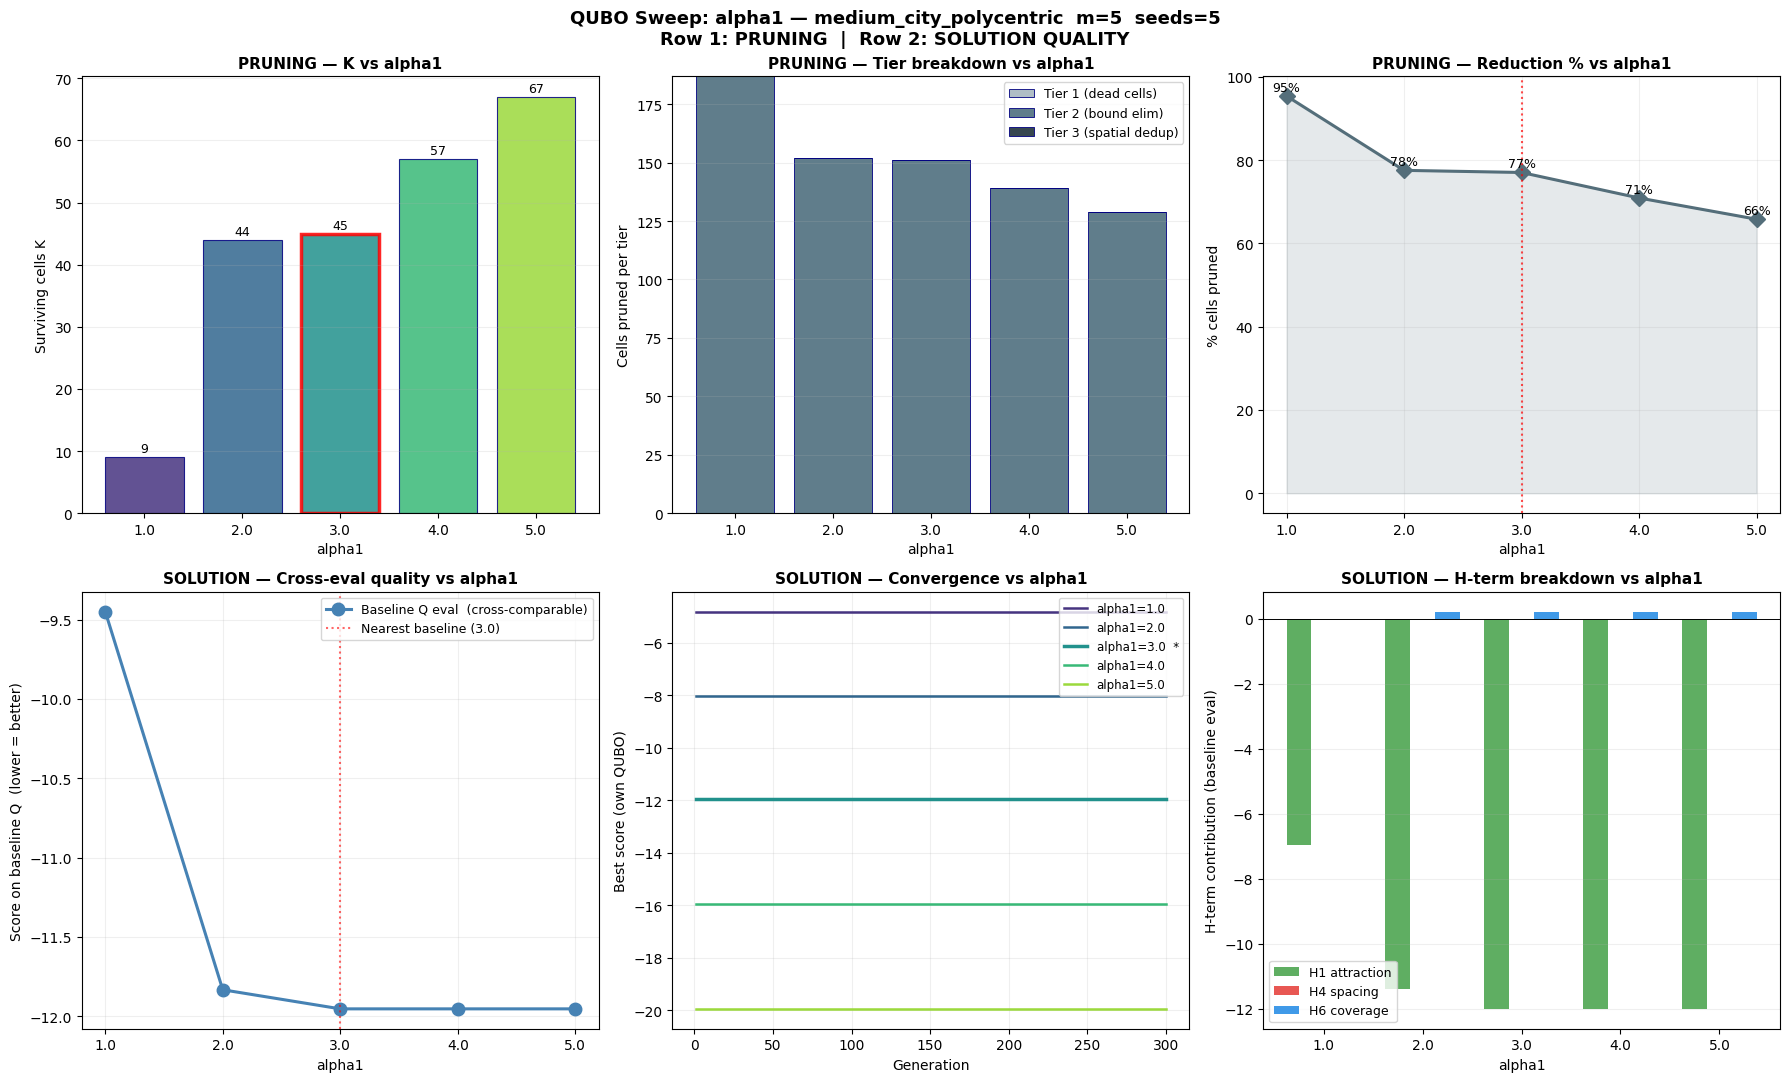

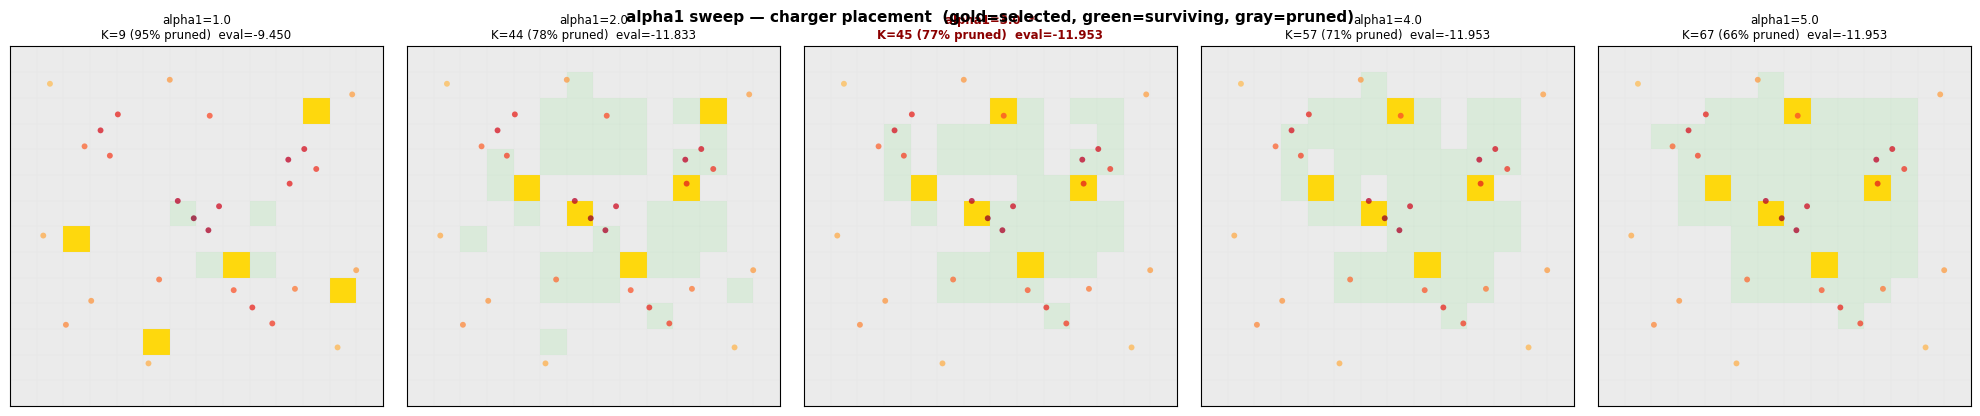

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# QUBO Sweep 1: alpha1 — H1 POI-attraction weight
# Higher alpha1 → stronger pull toward POI-dense cells → tighter clustering
# ─────────────────────────────────────────────────────────────────────────────

PARAM  = 'alpha1'
VALUES = QUBO_SWEEP_VALUES[PARAM]
BVAL   = _BASE_PARAMS[PARAM]
print(f'Sweep: {PARAM} over {VALUES}   (baseline ≈ {BVAL:.3f})\n')

sweep_q_alpha1 = {}
for val in VALUES:
    result = rebuild_and_run({PARAM: val}, label=f'{PARAM}={val}')
    if result:
        sweep_q_alpha1[val] = result
        print(f'  {PARAM}={val}  K={result["K"]}  mean_score={result["mean_score"]:.4f}'
              f'  baseline_eval={result["baseline_eval"]:.4f}  cells={result["best_cells"]}')

ALL_QUBO_SWEEP_RESULTS[PARAM] = sweep_q_alpha1
print()
print_qubo_sweep_table(sweep_q_alpha1, PARAM, BVAL)
print()
_ = plot_qubo_sweep(sweep_q_alpha1, PARAM, BVAL)
_ = plot_solution_comparison(sweep_q_alpha1, PARAM, BVAL)

Sweep: alpha4 over [0.5, 1.0, 1.5, 2.0, 3.0]   (baseline ≈ 1.500)

  alpha4=0.5  K=45  mean_score=-11.9530  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha4=1.0  K=45  mean_score=-11.9530  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha4=1.5  K=45  mean_score=-11.9530  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha4=2.0  K=45  mean_score=-11.9530  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha4=3.0  K=45  mean_score=-11.9530  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]

alpha4    K (pruned%)      T1    T2    T3    best_score  mean ±std           baseline_eval       H1    H4     H6
--------  -------------  ----  ----  ----  ------------  ----------------  ---------------  -------  ----  -----
0.5       45 (77%)          0   151     0       -11.953  -11.9530 ±0.0000          -11.953  -11.998     0  0.216
1.0       45 (77%)          0   151     0       -11.953  -11.9530 ±0.0000          -11.953  -11.998     0  0.216


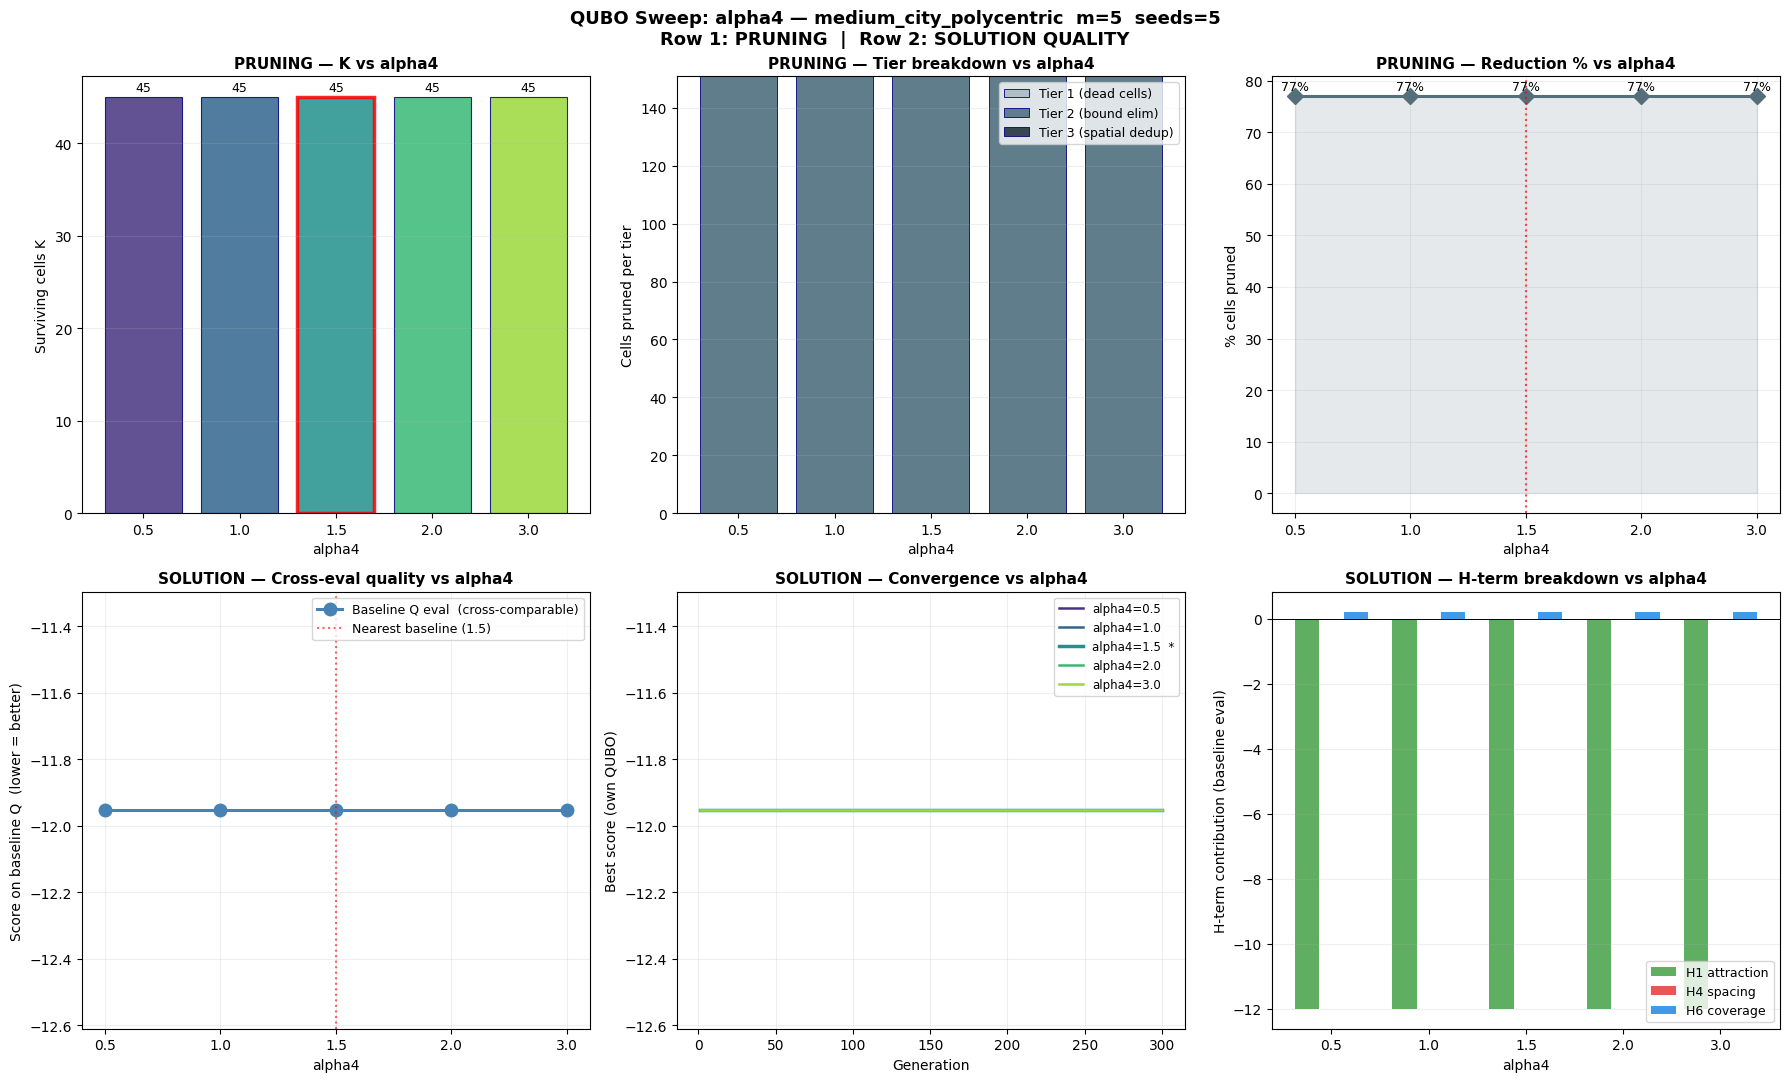

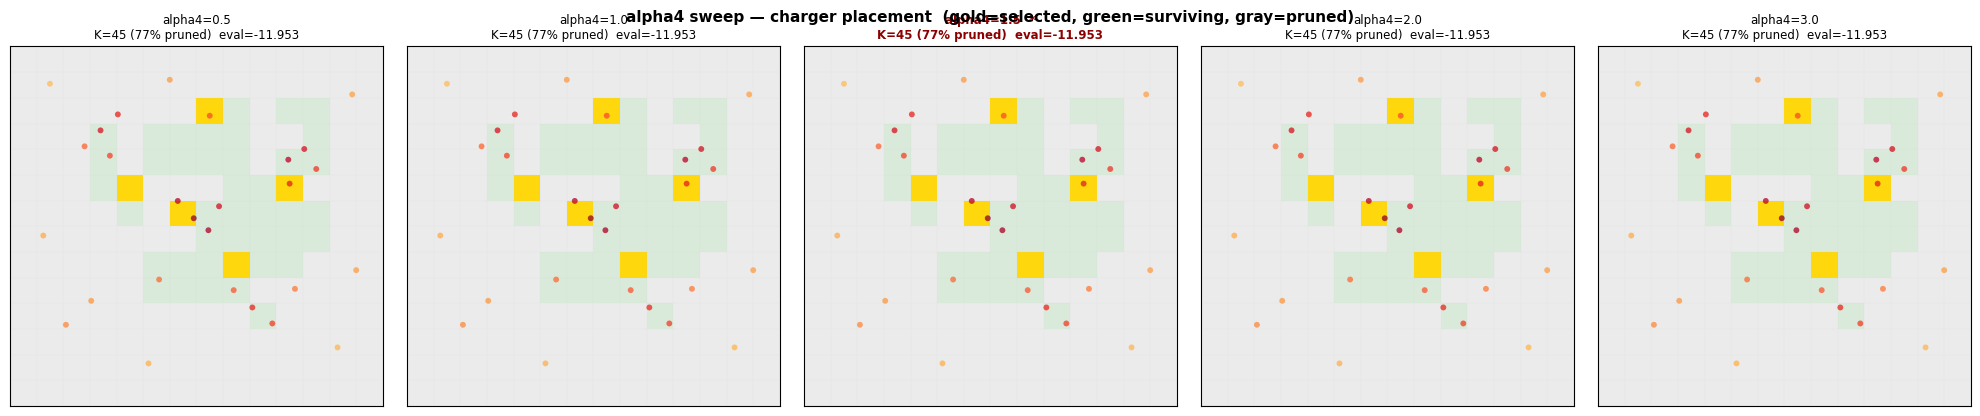

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# QUBO Sweep 2: alpha4 — H4 charger-spacing penalty
# Higher alpha4 → GA penalises close pairs more → spreads chargers wider
# ─────────────────────────────────────────────────────────────────────────────

PARAM  = 'alpha4'
VALUES = QUBO_SWEEP_VALUES[PARAM]
BVAL   = _BASE_PARAMS[PARAM]
print(f'Sweep: {PARAM} over {VALUES}   (baseline ≈ {BVAL:.3f})\n')

sweep_q_alpha4 = {}
for val in VALUES:
    result = rebuild_and_run({PARAM: val}, label=f'{PARAM}={val}')
    if result:
        sweep_q_alpha4[val] = result
        print(f'  {PARAM}={val}  K={result["K"]}  mean_score={result["mean_score"]:.4f}'
              f'  baseline_eval={result["baseline_eval"]:.4f}  cells={result["best_cells"]}')

ALL_QUBO_SWEEP_RESULTS[PARAM] = sweep_q_alpha4
print()
print_qubo_sweep_table(sweep_q_alpha4, PARAM, BVAL)
print()
_ = plot_qubo_sweep(sweep_q_alpha4, PARAM, BVAL)
_ = plot_solution_comparison(sweep_q_alpha4, PARAM, BVAL)

Sweep: alpha3 over [0.5, 0.8, 1.1, 1.5, 2.0]   (baseline ≈ 1.100)

  alpha3=0.5  K=78  mean_score=-12.1323  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha3=0.8  K=70  mean_score=-12.0426  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha3=1.1  K=45  mean_score=-11.9530  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha3=1.5  K=43  mean_score=-11.8334  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha3=2.0  K=53  mean_score=-11.6839  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]

alpha3    K (pruned%)      T1    T2    T3    best_score  mean ±std           baseline_eval       H1    H4     H6
--------  -------------  ----  ----  ----  ------------  ----------------  ---------------  -------  ----  -----
0.5       78 (60%)          0   114     4      -12.1323  -12.1323 ±0.0000          -11.953  -11.998     0  0.216
0.8       70 (64%)          0   126     0      -12.0426  -12.0426 ±0.0000          -11.953  -11.998     0  0.216


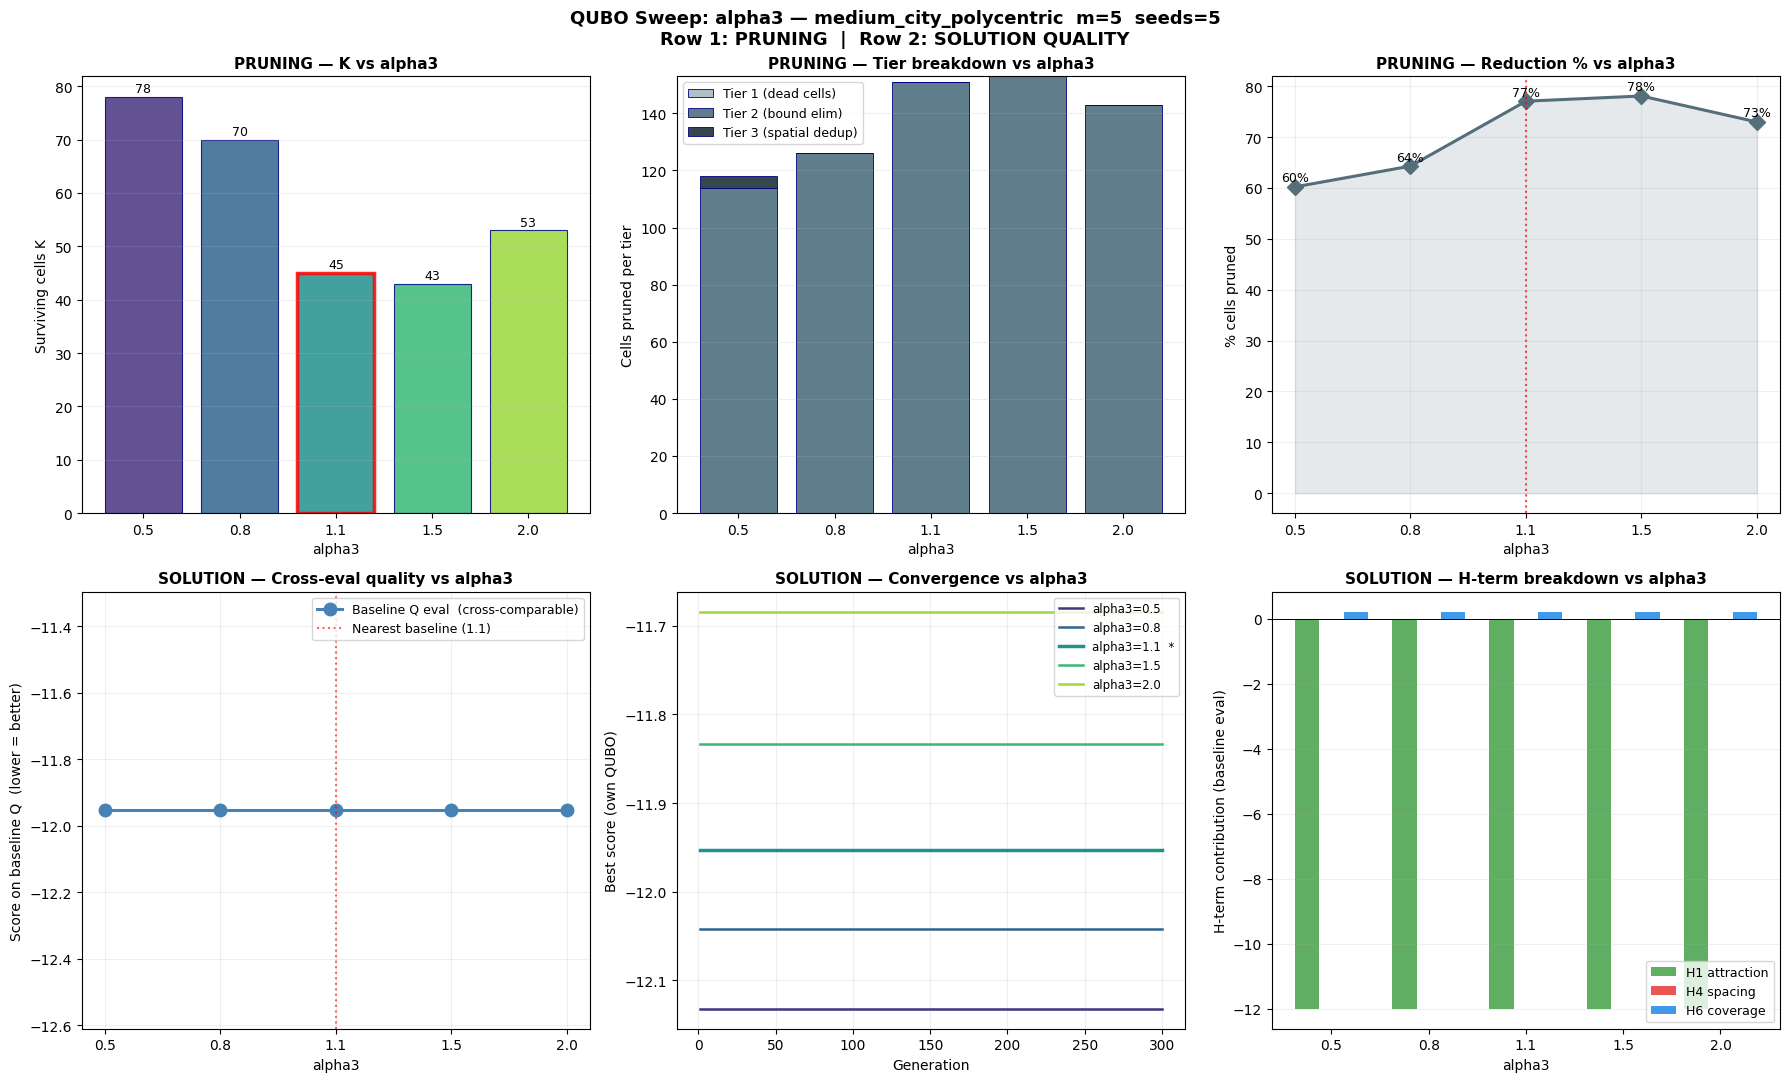

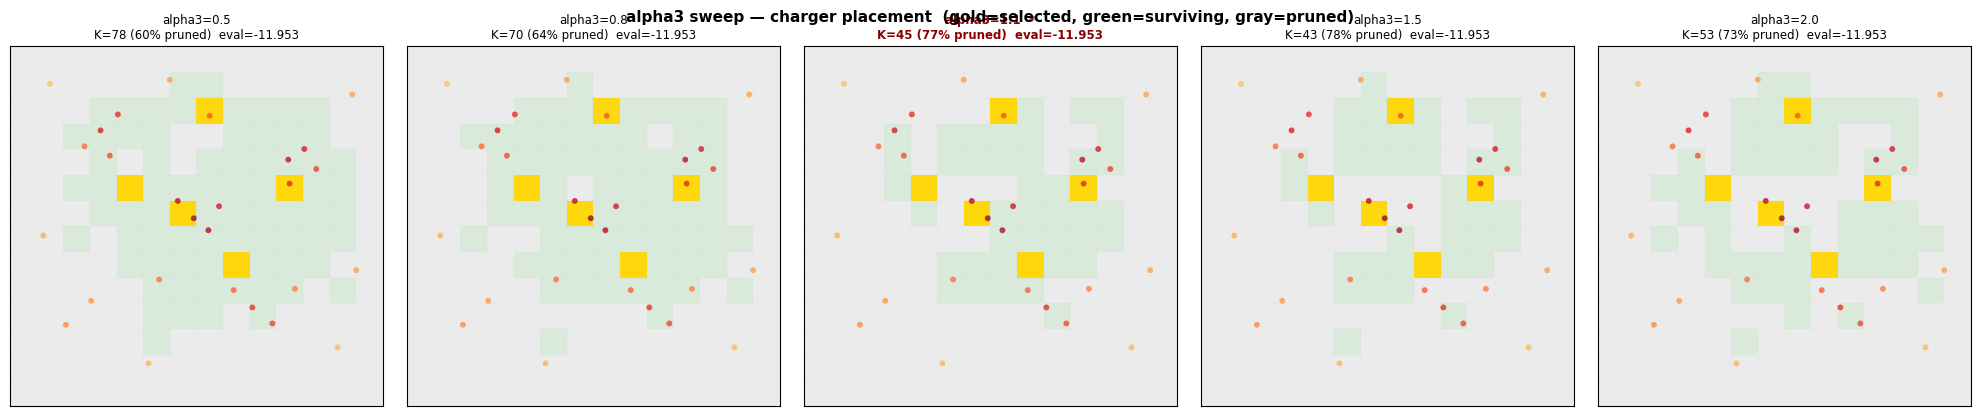

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# QUBO Sweep 3: alpha3 — H3 existing-charger penalty
# Higher alpha3 → GA avoids cells near existing chargers more aggressively
# ─────────────────────────────────────────────────────────────────────────────

PARAM  = 'alpha3'
VALUES = QUBO_SWEEP_VALUES[PARAM]
BVAL   = _BASE_PARAMS[PARAM]
print(f'Sweep: {PARAM} over {VALUES}   (baseline ≈ {BVAL:.3f})\n')

sweep_q_alpha3 = {}
for val in VALUES:
    result = rebuild_and_run({PARAM: val}, label=f'{PARAM}={val}')
    if result:
        sweep_q_alpha3[val] = result
        print(f'  {PARAM}={val}  K={result["K"]}  mean_score={result["mean_score"]:.4f}'
              f'  baseline_eval={result["baseline_eval"]:.4f}  cells={result["best_cells"]}')

ALL_QUBO_SWEEP_RESULTS[PARAM] = sweep_q_alpha3
print()
print_qubo_sweep_table(sweep_q_alpha3, PARAM, BVAL)
print()
_ = plot_qubo_sweep(sweep_q_alpha3, PARAM, BVAL)
_ = plot_solution_comparison(sweep_q_alpha3, PARAM, BVAL)

Sweep: alpha6 over [0.05, 0.15, 0.35, 0.5, 0.8]   (baseline ≈ 0.3494)

  alpha6=0.05  K=25  mean_score=-12.1380  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha6=0.15  K=31  mean_score=-12.0762  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha6=0.35  K=45  mean_score=-11.9526  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha6=0.5  K=56  mean_score=-11.8599  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  alpha6=0.8  K=75  mean_score=-11.6828  baseline_eval=-11.6828  cells=[79, 104, 116, 122, 161]

alpha6    K (pruned%)      T1    T2    T3    best_score  mean ±std           baseline_eval       H1    H4     H6
--------  -------------  ----  ----  ----  ------------  ----------------  ---------------  -------  ----  -----
0.05      25 (87%)          0   171     0      -12.138   -12.1380 ±0.0000         -11.953   -11.998     0  0.216
0.15      31 (84%)          0   165     0      -12.0762  -12.0762 ±0.0000         -11.953   -11.998     0 

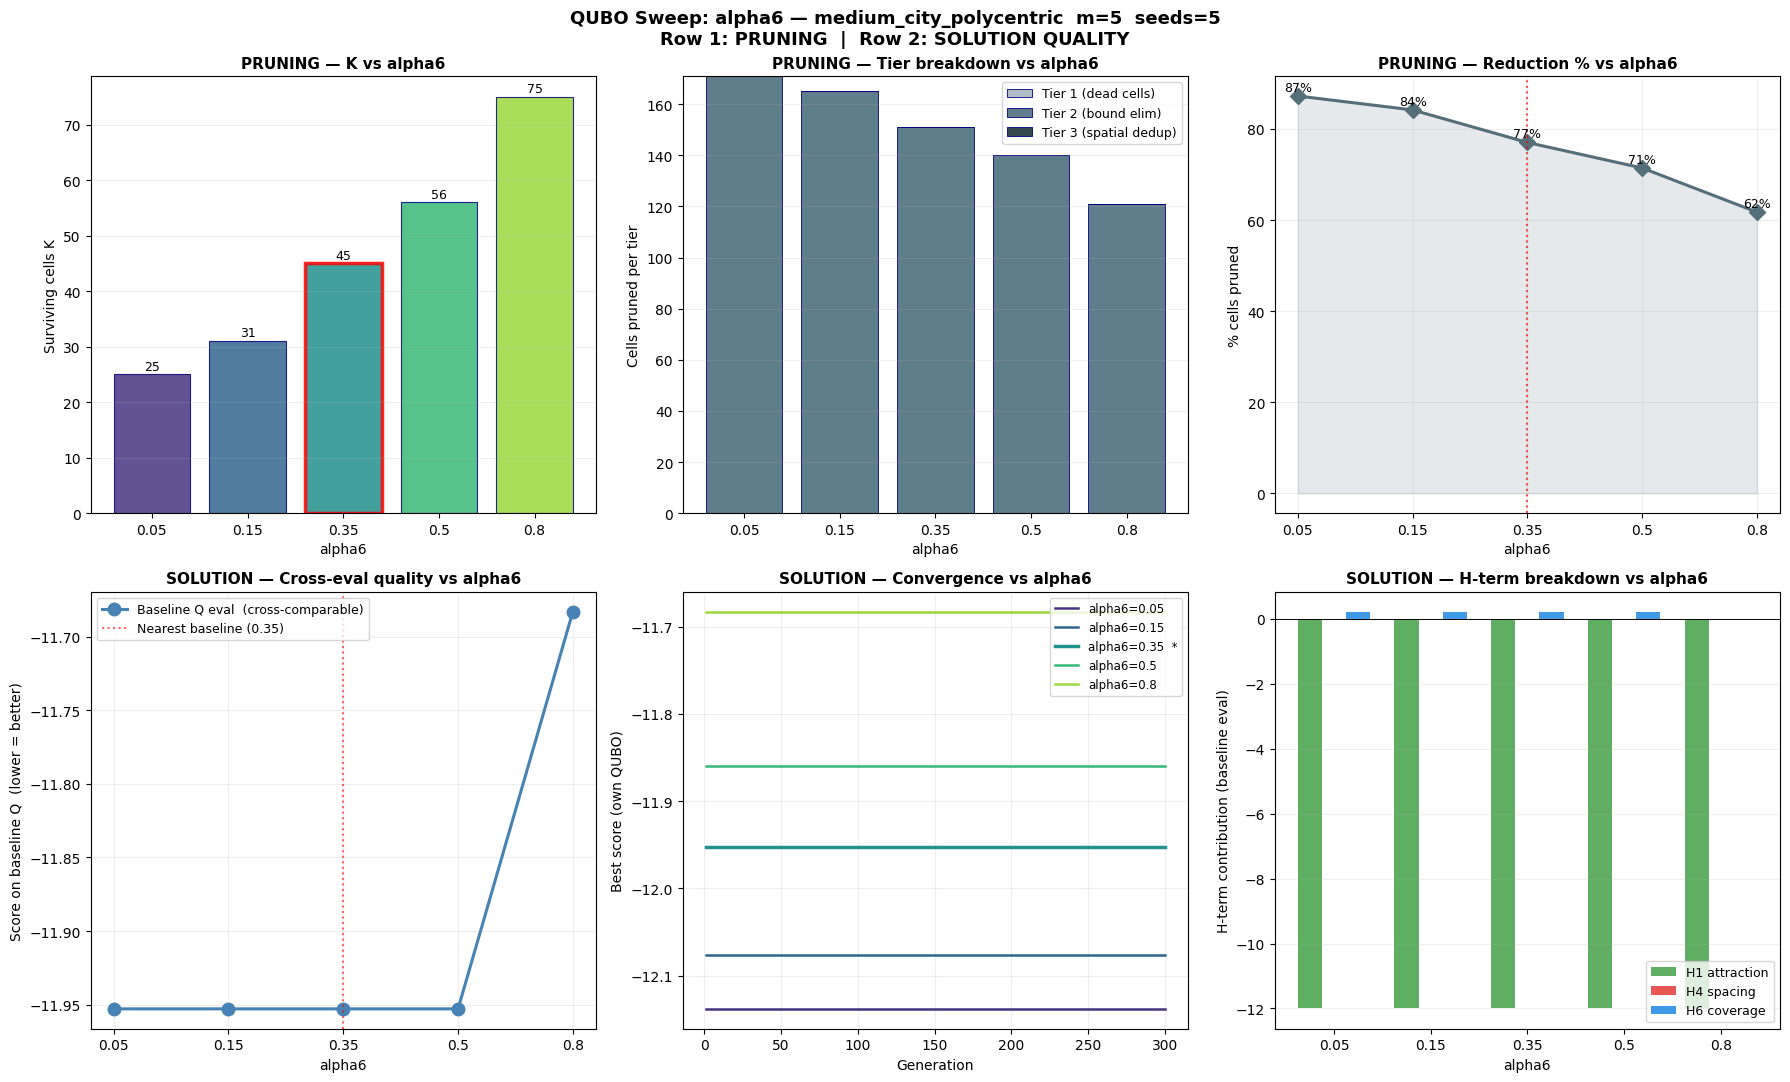

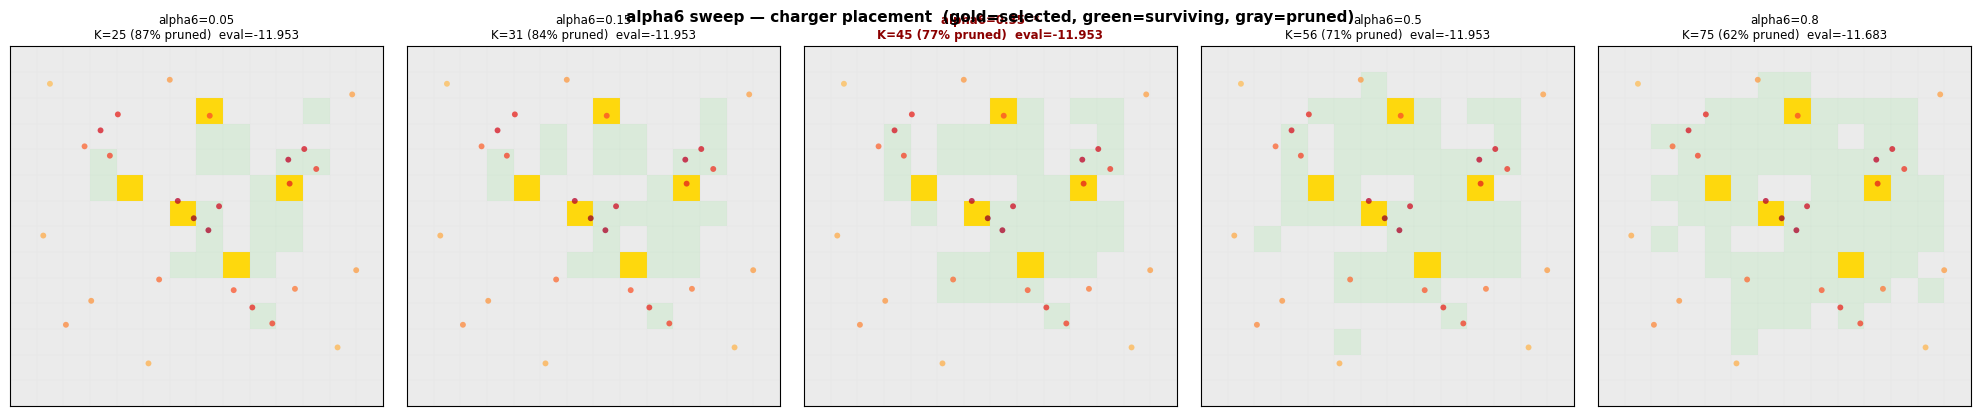

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# QUBO Sweep 4: alpha6 — H6 coverage-redundancy penalty
# Higher alpha6 → penalises redundant coverage → forces geographic spread
# ─────────────────────────────────────────────────────────────────────────────

PARAM  = 'alpha6'
VALUES = QUBO_SWEEP_VALUES[PARAM]
BVAL   = _BASE_PARAMS[PARAM]
print(f'Sweep: {PARAM} over {VALUES}   (baseline ≈ {BVAL:.4f})\n')

sweep_q_alpha6 = {}
for val in VALUES:
    result = rebuild_and_run({PARAM: val}, label=f'{PARAM}={val}')
    if result:
        sweep_q_alpha6[val] = result
        print(f'  {PARAM}={val}  K={result["K"]}  mean_score={result["mean_score"]:.4f}'
              f'  baseline_eval={result["baseline_eval"]:.4f}  cells={result["best_cells"]}')

ALL_QUBO_SWEEP_RESULTS[PARAM] = sweep_q_alpha6
print()
print_qubo_sweep_table(sweep_q_alpha6, PARAM, BVAL)
print()
_ = plot_qubo_sweep(sweep_q_alpha6, PARAM, BVAL)
_ = plot_solution_comparison(sweep_q_alpha6, PARAM, BVAL)

Sweep: R1 over [2, 3, 4, 5, 6]   (baseline = 4)

  R1=2  K=61  mean_score=-12.5342  baseline_eval=-10.7529  cells=[78, 104, 131, 151, 174]
  R1=3  K=46  mean_score=-12.3971  baseline_eval=-11.5522  cells=[78, 104, 122, 131, 165]
  R1=4  K=45  mean_score=-11.9530  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  R1=5  K=98  mean_score=-11.6883  baseline_eval=-11.1585  cells=[78, 104, 131, 134, 165]
  R1=6  K=91  mean_score=-12.1683  baseline_eval=-10.9218  cells=[75, 78, 104, 131, 134]

R1    K (pruned%)      T1    T2    T3    best_score  mean ±std           baseline_eval       H1    H4     H6
----  -------------  ----  ----  ----  ------------  ----------------  ---------------  -------  ----  -----
2     61 (69%)          0   135     0      -12.5342  -12.5342 ±0.0000         -10.7529  -10.78      0  0.216
3     46 (77%)          0   150     0      -12.3971  -12.3971 ±0.0000         -11.5522  -11.097     0  0.216
4*    45 (77%)          0   151     0      -11.953   -11.9530 ±0.

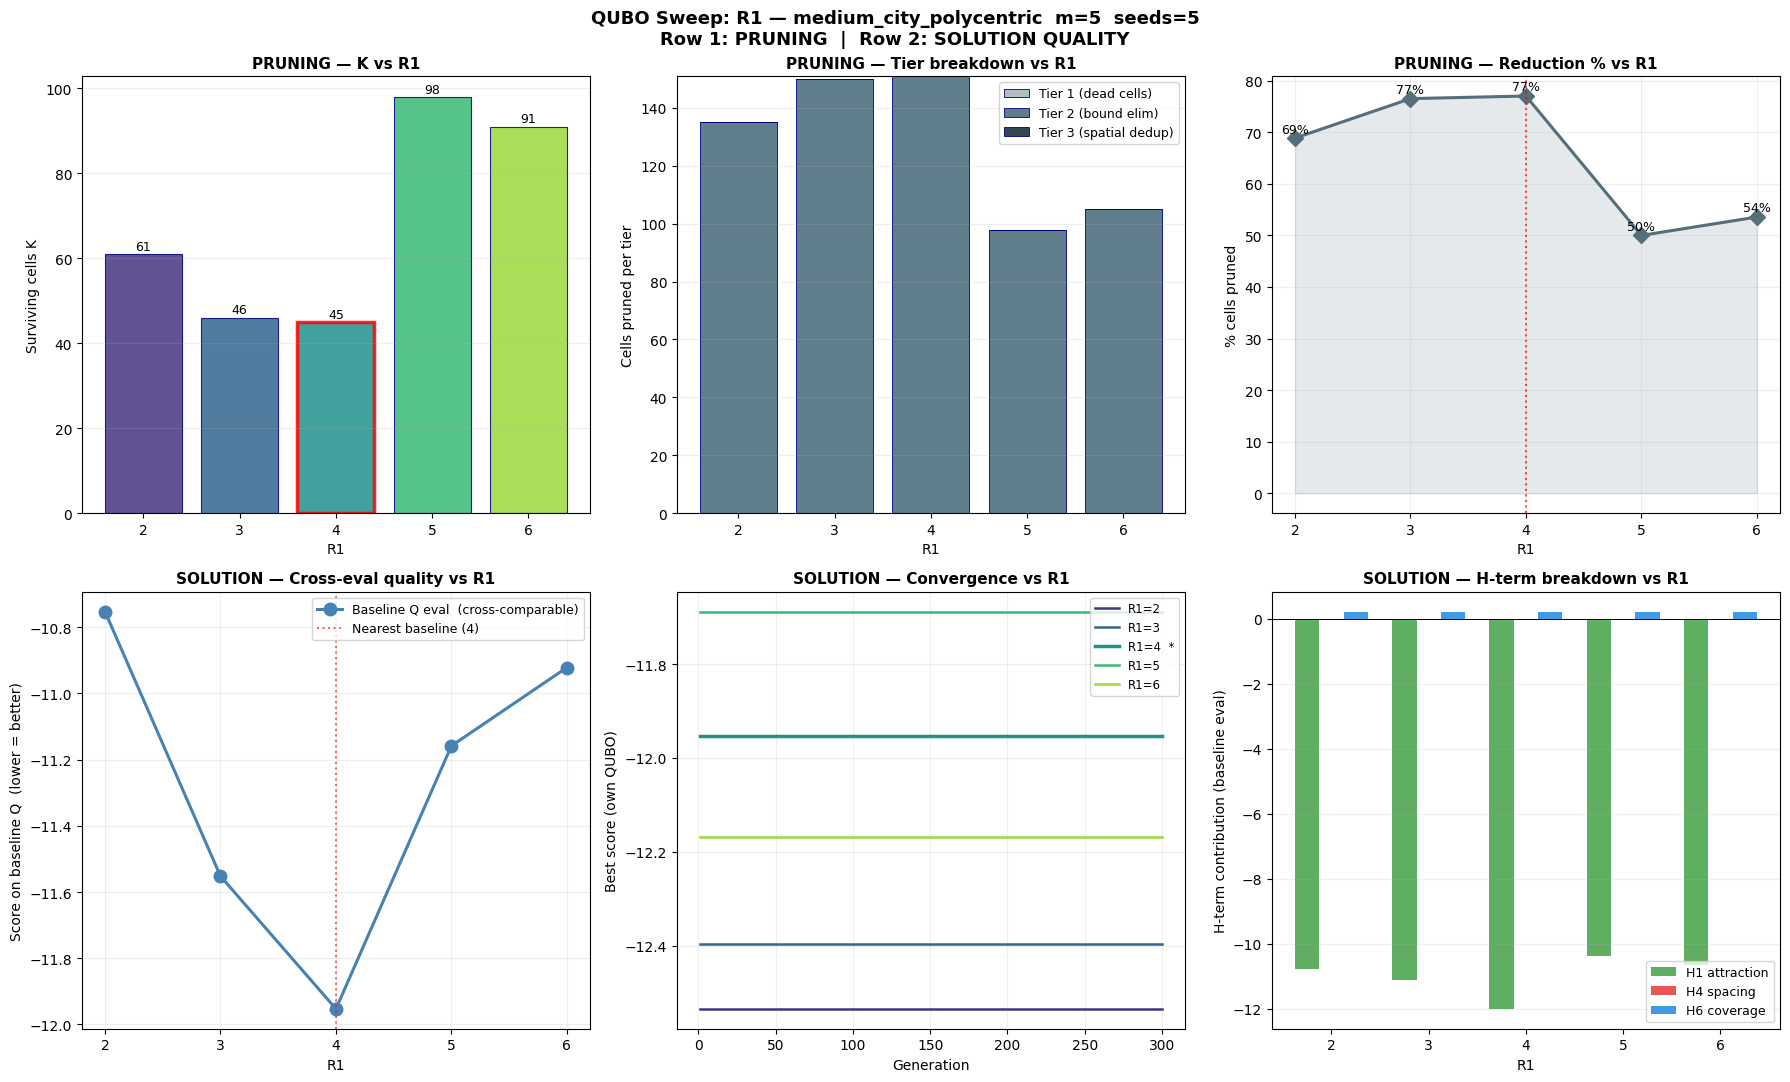

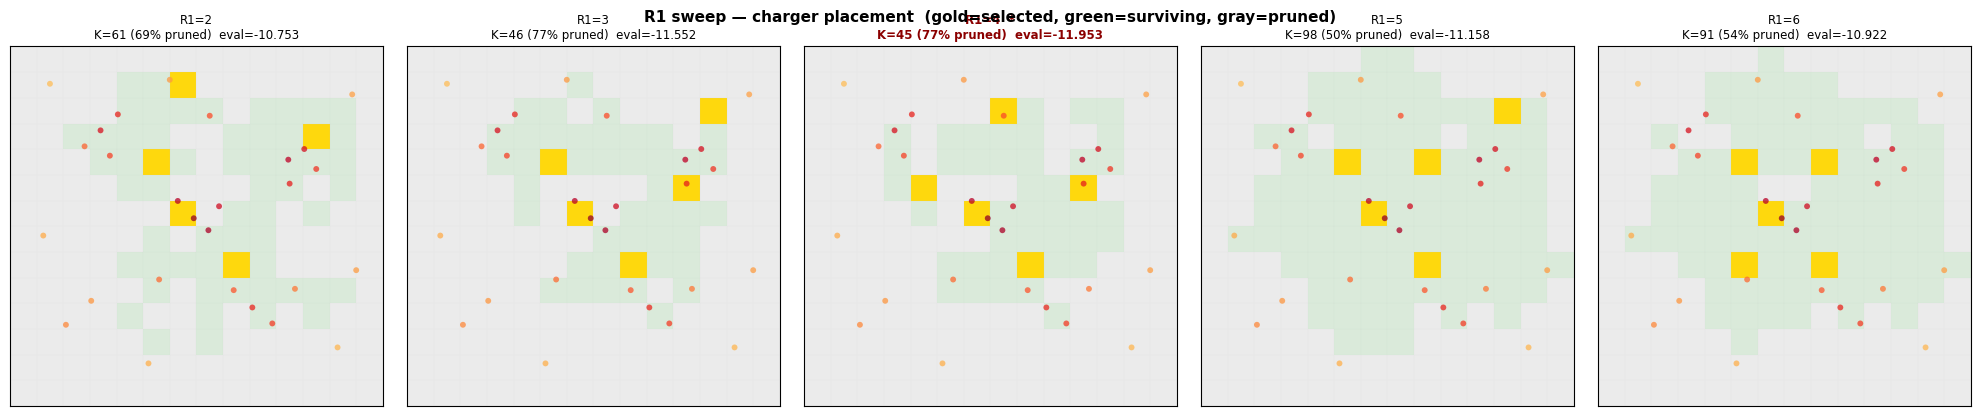

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# QUBO Sweep 5: R1 — H1 POI-attraction radius (in grid cells)
# Larger R1 → more cells receive POI-attraction signal → K grows, problem widens
# ─────────────────────────────────────────────────────────────────────────────

PARAM  = 'R1'
VALUES = QUBO_SWEEP_VALUES[PARAM]
BVAL   = _BASE_PARAMS[PARAM]
print(f'Sweep: {PARAM} over {VALUES}   (baseline = {BVAL})\n')

sweep_q_R1 = {}
for val in VALUES:
    # R1 and Rs are coupled — update both to keep service-gap logic consistent
    result = rebuild_and_run({'R1': val, 'Rs': val}, label=f'{PARAM}={val}')
    if result:
        sweep_q_R1[val] = result
        print(f'  {PARAM}={val}  K={result["K"]}  mean_score={result["mean_score"]:.4f}'
              f'  baseline_eval={result["baseline_eval"]:.4f}  cells={result["best_cells"]}')

ALL_QUBO_SWEEP_RESULTS[PARAM] = sweep_q_R1
print()
print_qubo_sweep_table(sweep_q_R1, PARAM, BVAL)
print()
_ = plot_qubo_sweep(sweep_q_R1, PARAM, BVAL)
_ = plot_solution_comparison(sweep_q_R1, PARAM, BVAL)

Sweep: R4 over [1, 2, 3, 4]   (baseline = 2)

  R4=1  K=45  mean_score=-11.9530  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  R4=2  K=45  mean_score=-11.9530  baseline_eval=-11.9530  cells=[78, 104, 116, 122, 161]
  R4=3  K=109  mean_score=-11.3846  baseline_eval=-11.6088  cells=[51, 78, 104, 116, 122]
  R4=4  K=140  mean_score=-11.1669  baseline_eval=-11.3911  cells=[51, 78, 104, 115, 122]

R4    K (pruned%)      T1    T2    T3    best_score  mean ±std           baseline_eval       H1     H4     H6
----  -------------  ----  ----  ----  ------------  ----------------  ---------------  -------  -----  -----
1     45 (77%)          0   151     0      -11.953   -11.9530 ±0.0000         -11.953   -11.998  0      0.216
2*    45 (77%)          0   151     0      -11.953   -11.9530 ±0.0000         -11.953   -11.998  0      0.216
3     109 (44%)         0    87     0      -11.3846  -11.3846 ±0.0000         -11.6088  -12.19   0.122  0.361
4     140 (29%)         0    52     4      

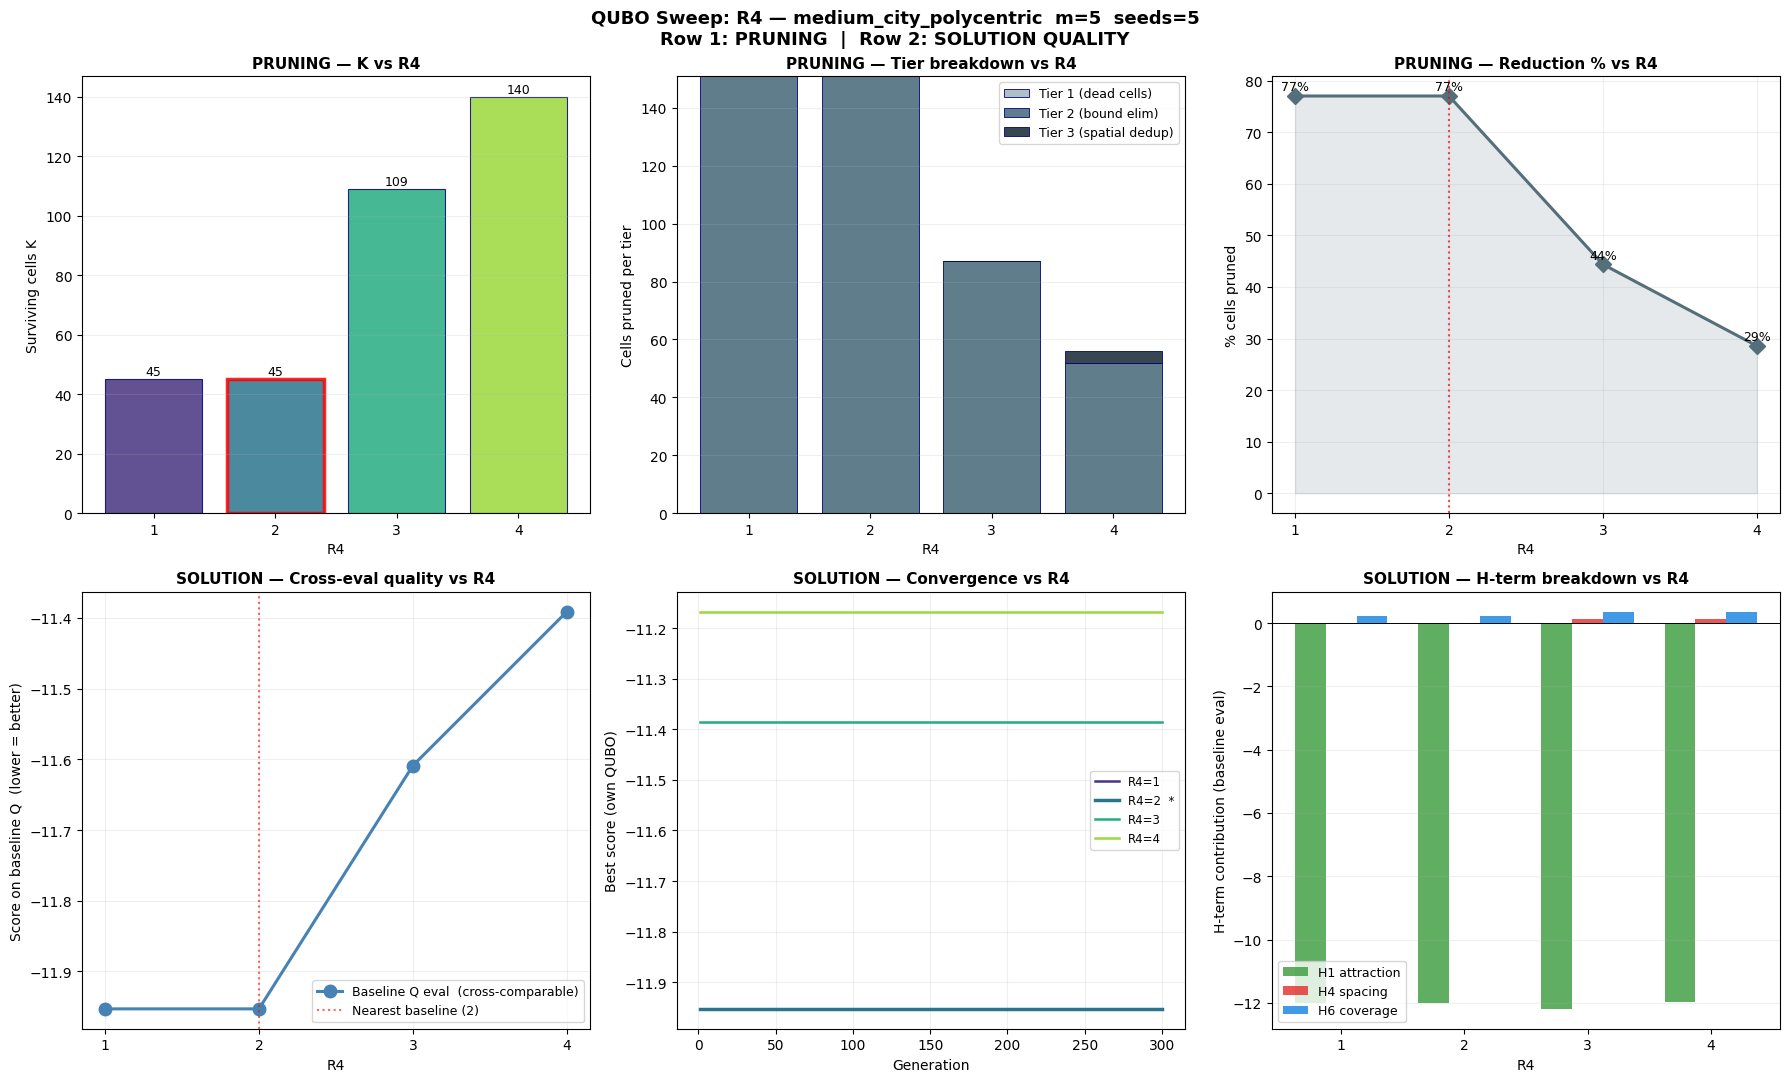

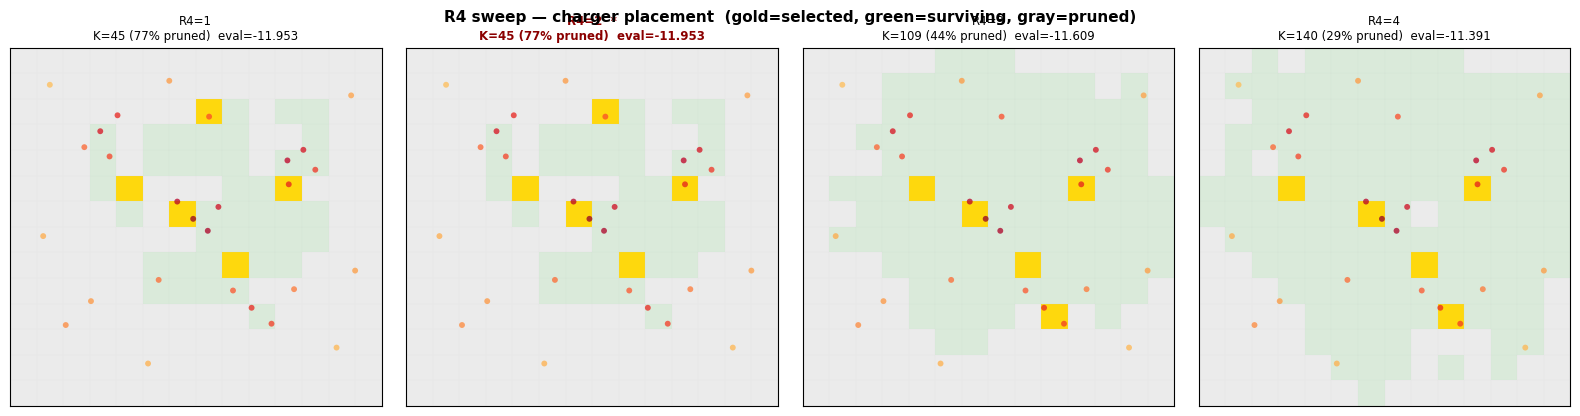

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# QUBO Sweep 6: R4 — H4 spacing radius (minimum distance between new chargers)
# Larger R4 → wider "no-go zone" between new chargers → fewer surviving cell pairs
# ─────────────────────────────────────────────────────────────────────────────

PARAM  = 'R4'
VALUES = QUBO_SWEEP_VALUES[PARAM]
BVAL   = _BASE_PARAMS[PARAM]
print(f'Sweep: {PARAM} over {VALUES}   (baseline = {BVAL})\n')

sweep_q_R4 = {}
for val in VALUES:
    # Pass updated R4 so prune_cells uses the same radius as the QUBO
    result = rebuild_and_run({'R4': val}, label=f'{PARAM}={val}')
    if result:
        sweep_q_R4[val] = result
        print(f'  {PARAM}={val}  K={result["K"]}  mean_score={result["mean_score"]:.4f}'
              f'  baseline_eval={result["baseline_eval"]:.4f}  cells={result["best_cells"]}')

ALL_QUBO_SWEEP_RESULTS[PARAM] = sweep_q_R4
print()
print_qubo_sweep_table(sweep_q_R4, PARAM, BVAL)
print()
_ = plot_qubo_sweep(sweep_q_R4, PARAM, BVAL)
_ = plot_solution_comparison(sweep_q_R4, PARAM, BVAL)

QUBO PARAMETER SWEEP MASTER SUMMARY
Dataset: medium_city_polycentric  N=196  m=5  GA seeds=5
Cross-eval metric: solution scored against baseline Q_obj (comparable across params)
Parameter      Baseline    Nearest in sweep    Baseline eval    Best value    Best eval    Improvement  Worth tuning?
-----------  ----------  ------------------  ---------------  ------------  -----------  -------------  ---------------
alpha1           3                     3             -11.953          3         -11.953              0  no
alpha4           1.5                   1.5           -11.953          0.5       -11.953              0  no
alpha3           1.1                   1.1           -11.953          0.5       -11.953              0  no
alpha6           0.3494                0.35          -11.953          0.05      -11.953              0  no
R1               4                     4             -11.953          4         -11.953              0  no
R4               2                     2         

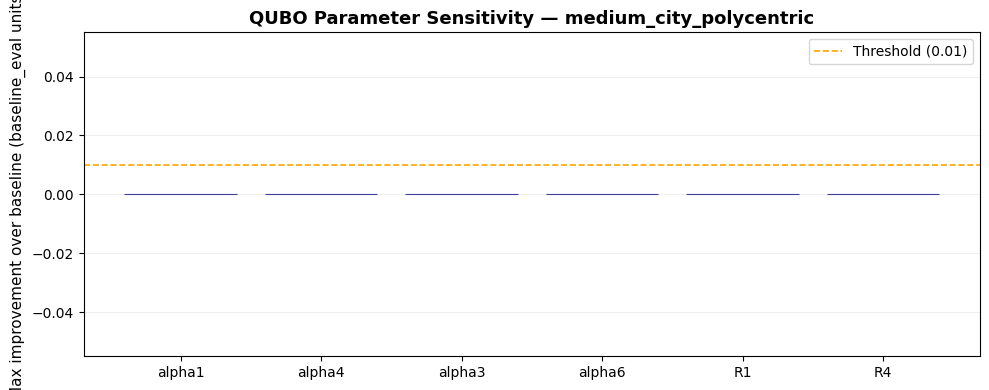


Red bars = worth re-tuning (improvement > 0.01 over auto-suggested value)
Green bars = auto-suggested value is near-optimal


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# QUBO parameter sweep — master summary
# Shows: which value of each parameter gave the best baseline_eval score,
# and how much it differs from the auto-suggested baseline.
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 80)
print('QUBO PARAMETER SWEEP MASTER SUMMARY')
print(f'Dataset: {data["dataset_name"]}  N={N_QUBITS}  m={M}  GA seeds={N_SEEDS}')
print('Cross-eval metric: solution scored against baseline Q_obj (comparable across params)')
print('=' * 80)

qubo_master_rows = []
for param_name, sweep_res in ALL_QUBO_SWEEP_RESULTS.items():
    bval = _BASE_PARAMS[param_name]
    vals = sorted(sweep_res.keys())
    nearest_base = _nearest(vals, bval)

    base_eval = sweep_res[nearest_base]['baseline_eval']
    best_val  = min(vals, key=lambda v: sweep_res[v]['baseline_eval'])
    best_eval = sweep_res[best_val]['baseline_eval']
    improvement = base_eval - best_eval  # positive = best_val beats baseline

    qubo_master_rows.append([
        param_name,
        f'{bval:.4g}',
        f'{nearest_base}',
        f'{base_eval:.4f}',
        f'{best_val}',
        f'{best_eval:.4f}',
        f'{improvement:+.4f}',
        'YES' if abs(improvement) > 0.01 else 'no',
    ])

print(tabulate(qubo_master_rows,
               headers=['Parameter', 'Baseline', 'Nearest in sweep', 'Baseline eval',
                        'Best value', 'Best eval', 'Improvement', 'Worth tuning?'],
               tablefmt='simple'))
print()
print('Improvement > 0 → using "Best value" gives a better solution on the baseline objective.')
print('Improvement ≈ 0 → parameter is insensitive at this scale — auto-suggested value is fine.')

# Sensitivity bar chart
fig, ax = plt.subplots(figsize=(10, 4))
params_list = list(ALL_QUBO_SWEEP_RESULTS.keys())
improvements = []
for pname in params_list:
    sweep_res = ALL_QUBO_SWEEP_RESULTS[pname]
    bv = _BASE_PARAMS[pname]
    nb = _nearest(sorted(sweep_res.keys()), bv)
    best_v = min(sorted(sweep_res.keys()), key=lambda v: sweep_res[v]['baseline_eval'])
    imp = sweep_res[nb]['baseline_eval'] - sweep_res[best_v]['baseline_eval']
    improvements.append(imp)

bar_colors = ['#E53935' if imp > 0.01 else '#43A047' for imp in improvements]
ax.bar(params_list, improvements, color=bar_colors, edgecolor='navy', linewidth=0.8, alpha=0.85)
ax.axhline(0.01, color='orange', linestyle='--', linewidth=1.2, label='Threshold (0.01)')
ax.set_ylabel('Max improvement over baseline (baseline_eval units)', fontsize=11)
ax.set_title(f'QUBO Parameter Sensitivity — {data["dataset_name"]}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

print('\nRed bars = worth re-tuning (improvement > 0.01 over auto-suggested value)')
print('Green bars = auto-suggested value is near-optimal')

---
## Section 3 — GA Hyperparameter Tuning

Strategy: **one parameter at a time**, all others held at baseline.  
Each configuration runs with `N_SEEDS` independent random seeds on the **baseline pruned QUBO** (Q_pruned from Section 1).  
Metrics: mean final score, std, convergence generation, mean runtime.

Running baseline GA...
GA [greedy]: K=45, m=5, pop=50, gens=300
  Gen    1/300: best=-11.952956
  Gen   30/300: best=-11.952956
  Gen   60/300: best=-11.952956
  Gen   90/300: best=-11.952956
  Gen  120/300: best=-11.952956
  Gen  150/300: best=-11.952956
  Gen  180/300: best=-11.952956
  Gen  210/300: best=-11.952956
  Gen  240/300: best=-11.952956
  Gen  270/300: best=-11.952956
  Gen  300/300: best=-11.952956
  Done in 0.21s | best=-11.952956 | cells=[78, 104, 116, 122, 161]

Baseline result:
  Best score : -11.952956
  Best cells : [78, 104, 116, 122, 161]
  Runtime    : 0.211s


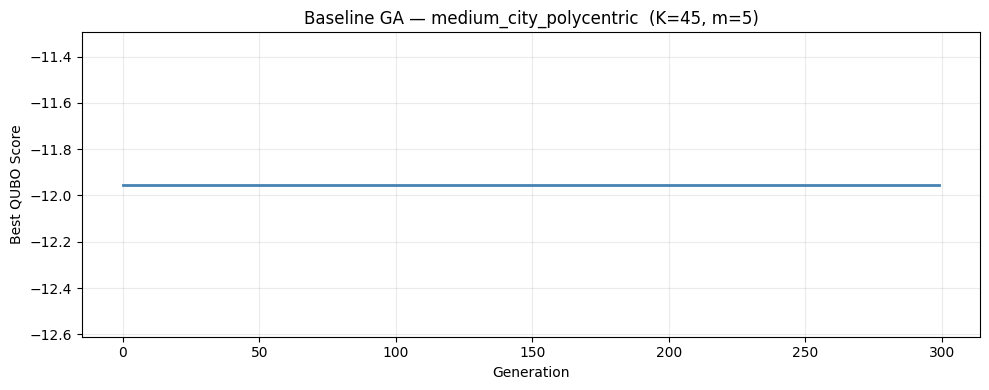

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Baseline GA run — greedy seed, pruned QUBO
# ─────────────────────────────────────────────────────────────────────────────

print('Running baseline GA...')
baseline_result = run_ga(
    Q_pruned, qubit_to_cell, K=K, m=M,
    **BASELINE,
    verbose=True, seed=0,
)

print(f'\nBaseline result:')
print(f'  Best score : {baseline_result["best_score"]:.6f}')
print(f'  Best cells : {baseline_result["best_solution"]}')
print(f'  Runtime    : {baseline_result["runtime_sec"]:.3f}s')

# Plot baseline convergence
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(baseline_result['convergence'], color='steelblue', linewidth=2)
ax.set_xlabel('Generation')
ax.set_ylabel('Best QUBO Score')
ax.set_title(f'Baseline GA — {data["dataset_name"]}  (K={K}, m={M})')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Sweep helper functions
# ─────────────────────────────────────────────────────────────────────────────

def _conv_gen(curve, tol=0.01):
    """First generation where score is within tol (relative) of final."""
    final = curve[-1]
    denom = abs(final) if abs(final) > 1e-10 else 1.0
    for i, v in enumerate(curve):
        if abs(v - final) / denom <= tol:
            return i + 1
    return len(curve)


def run_sweep(Q, qubit_to_cell, K, m, param_name, values, baseline, seeds):
    """Run GA for each value of param_name, return {value: [run_results]}."""
    results = {}
    for val in values:
        kw = {**baseline, param_name: val}
        runs = []
        for seed in seeds:
            r = run_ga(Q, qubit_to_cell, K=K, m=m,
                       population_size=kw['population_size'],
                       n_generations=kw['n_generations'],
                       crossover_rate=kw['crossover_rate'],
                       mutation_rate=kw['mutation_rate'],
                       tournament_size=kw['tournament_size'],
                       seed_mode=kw['seed_mode'],
                       verbose=False, seed=seed)
            runs.append(r)
        results[val] = runs
        sc  = np.mean([r['best_score'] for r in runs])
        rt  = np.mean([r['runtime_sec'] for r in runs])
        cg  = np.mean([_conv_gen(r['convergence']) for r in runs])
        print(f'  {param_name}={val!s:<8} | score={sc:.4f} | conv_gen={cg:.0f} | time={rt:.3f}s')
    return results


def plot_sweep(sweep_results, param_name, baseline_val, fig_title=None, save_path=None):
    """
    Two-subplot figure:
      Left  — convergence curves (mean +/- 1 sigma across seeds)
      Right — final score distribution (box plot)
    """
    values = sorted(sweep_results.keys())
    cmap   = plt.colormaps['plasma']
    colors = [cmap(x) for x in np.linspace(0.15, 0.85, len(values))]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax_c, ax_b = axes

    for val, color in zip(values, colors):
        curves = [r['convergence'] for r in sweep_results[val]]
        max_len = max(len(c) for c in curves)
        padded  = np.array([c + [c[-1]] * (max_len - len(c)) for c in curves])
        mean = padded.mean(axis=0)
        std  = padded.std(axis=0)
        gens = np.arange(1, max_len + 1)
        lbl  = f'{param_name}={val}' + (' *baseline' if val == baseline_val else '')
        lw   = 2.5 if val == baseline_val else 1.8
        ax_c.plot(gens, mean, color=color, linewidth=lw, label=lbl)
        ax_c.fill_between(gens, mean - std, mean + std, color=color, alpha=0.12)

    ax_c.set_xlabel('Generation', fontsize=11)
    ax_c.set_ylabel('Best QUBO Score  (lower = better)', fontsize=11)
    ax_c.set_title(f'Convergence vs {param_name}', fontsize=12)
    ax_c.legend(fontsize=8.5)
    ax_c.grid(True, alpha=0.2)

    final_scores = [[r['best_score'] for r in sweep_results[v]] for v in values]
    bp = ax_b.boxplot(final_scores, tick_labels=[str(v) for v in values],
                      patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax_b.set_xlabel(param_name, fontsize=11)
    ax_b.set_ylabel('Final Best Score', fontsize=11)
    ax_b.set_title(f'Final Score Distribution vs {param_name}', fontsize=12)
    ax_b.grid(True, alpha=0.2, axis='y')

    if fig_title:
        fig.suptitle(fig_title, fontsize=13, fontweight='bold', y=1.01)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def sweep_summary_table(sweep_results, param_name, baseline_val):
    """Print a summary table for one parameter sweep."""
    rows = []
    for val in sorted(sweep_results.keys()):
        runs   = sweep_results[val]
        scores = [r['best_score'] for r in runs]
        times  = [r['runtime_sec'] for r in runs]
        cgens  = [_conv_gen(r['convergence']) for r in runs]
        marker = ' *' if val == baseline_val else ''
        rows.append([
            f'{val}{marker}',
            f'{np.mean(scores):.4f}',
            f'{np.std(scores):.4f}',
            f'{np.mean(cgens):.0f}',
            f'{np.mean(times):.3f}s',
        ])
    print(tabulate(rows,
                   headers=[param_name, 'mean_score', 'std_score', 'conv_gen', 'mean_time'],
                   tablefmt='simple'))


# Storage for all sweep results (used in summary + save)
ALL_SWEEP_RESULTS = {}
print('Sweep helpers ready.')

Sweep helpers ready.


Sweep: population_size over [20, 50, 100, 200]  (5 seeds each)

  population_size=20       | score=-11.9530 | conv_gen=1 | time=0.081s
  population_size=50       | score=-11.9530 | conv_gen=1 | time=0.203s
  population_size=100      | score=-11.9530 | conv_gen=1 | time=0.415s
  population_size=200      | score=-11.9530 | conv_gen=1 | time=0.821s

population_size      mean_score    std_score    conv_gen  mean_time
-----------------  ------------  -----------  ----------  -----------
20                      -11.953            0           1  0.081s
50 *                    -11.953            0           1  0.203s
100                     -11.953            0           1  0.415s
200                     -11.953            0           1  0.821s



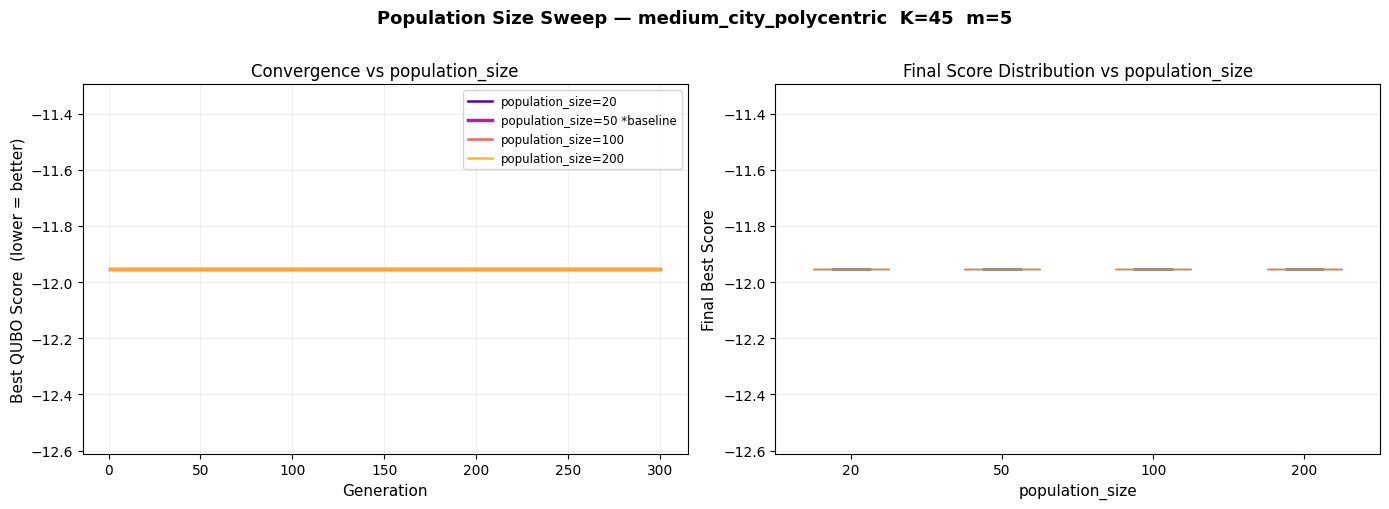

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Sweep 1: Population Size
# ─────────────────────────────────────────────────────────────────────────────

PARAM = 'population_size'
VALUES = SWEEP_VALUES[PARAM]
print(f'Sweep: {PARAM} over {VALUES}  ({N_SEEDS} seeds each)\n')

sweep_pop = run_sweep(Q_pruned, qubit_to_cell, K, M, PARAM, VALUES, BASELINE, SEEDS)
ALL_SWEEP_RESULTS[PARAM] = sweep_pop

print()
sweep_summary_table(sweep_pop, PARAM, BASELINE[PARAM])
print()

_ = plot_sweep(
    sweep_pop, PARAM, BASELINE[PARAM],
    fig_title=f'Population Size Sweep — {data["dataset_name"]}  K={K}  m={M}',
)

Sweep: n_generations over [50, 100, 200, 500]  (5 seeds each)

  n_generations=50       | score=-11.9530 | conv_gen=1 | time=0.034s
  n_generations=100      | score=-11.9530 | conv_gen=1 | time=0.069s
  n_generations=200      | score=-11.9530 | conv_gen=1 | time=0.135s
  n_generations=500      | score=-11.9530 | conv_gen=1 | time=0.344s

  n_generations    mean_score    std_score    conv_gen  mean_time
---------------  ------------  -----------  ----------  -----------
             50       -11.953            0           1  0.034s
            100       -11.953            0           1  0.069s
            200       -11.953            0           1  0.135s
            500       -11.953            0           1  0.344s



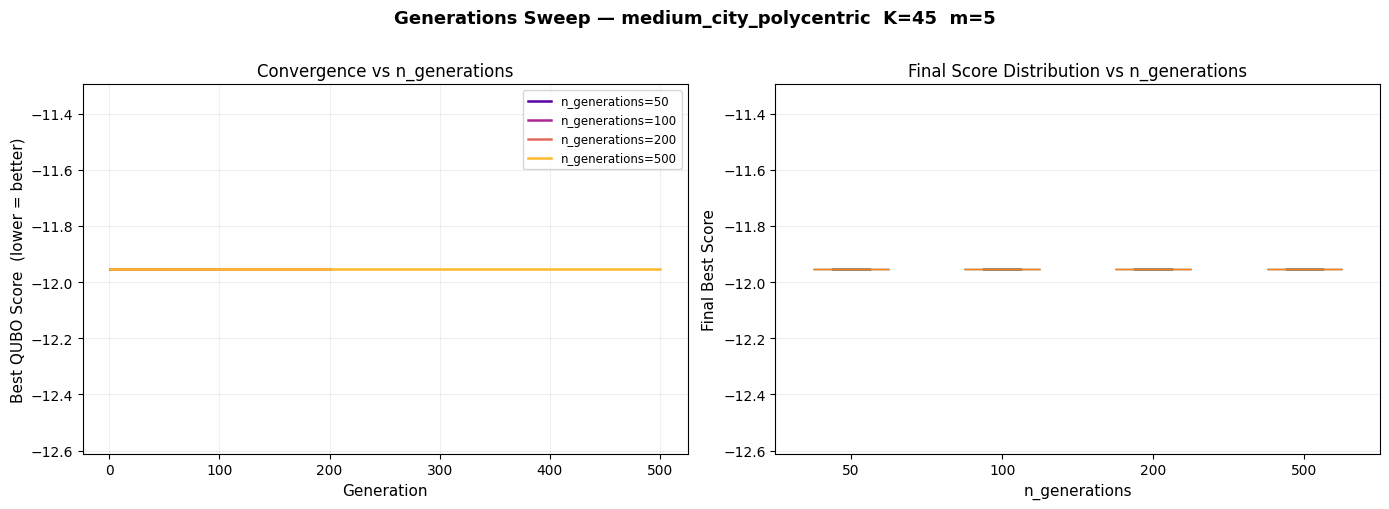

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Sweep 2: Number of Generations
# ─────────────────────────────────────────────────────────────────────────────

PARAM = 'n_generations'
VALUES = SWEEP_VALUES[PARAM]
print(f'Sweep: {PARAM} over {VALUES}  ({N_SEEDS} seeds each)\n')

sweep_gens = run_sweep(Q_pruned, qubit_to_cell, K, M, PARAM, VALUES, BASELINE, SEEDS)
ALL_SWEEP_RESULTS[PARAM] = sweep_gens

print()
sweep_summary_table(sweep_gens, PARAM, BASELINE[PARAM])
print()

_ = plot_sweep(
    sweep_gens, PARAM, BASELINE[PARAM],
    fig_title=f'Generations Sweep — {data["dataset_name"]}  K={K}  m={M}',
)

Sweep: crossover_rate over [0.5, 0.6, 0.7, 0.8, 0.9]  (5 seeds each)

  crossover_rate=0.5      | score=-11.9530 | conv_gen=1 | time=0.187s
  crossover_rate=0.6      | score=-11.9530 | conv_gen=1 | time=0.192s
  crossover_rate=0.7      | score=-11.9530 | conv_gen=1 | time=0.197s
  crossover_rate=0.8      | score=-11.9530 | conv_gen=1 | time=0.209s
  crossover_rate=0.9      | score=-11.9530 | conv_gen=1 | time=0.216s

crossover_rate      mean_score    std_score    conv_gen  mean_time
----------------  ------------  -----------  ----------  -----------
0.5                    -11.953            0           1  0.187s
0.6                    -11.953            0           1  0.192s
0.7                    -11.953            0           1  0.197s
0.8 *                  -11.953            0           1  0.209s
0.9                    -11.953            0           1  0.216s



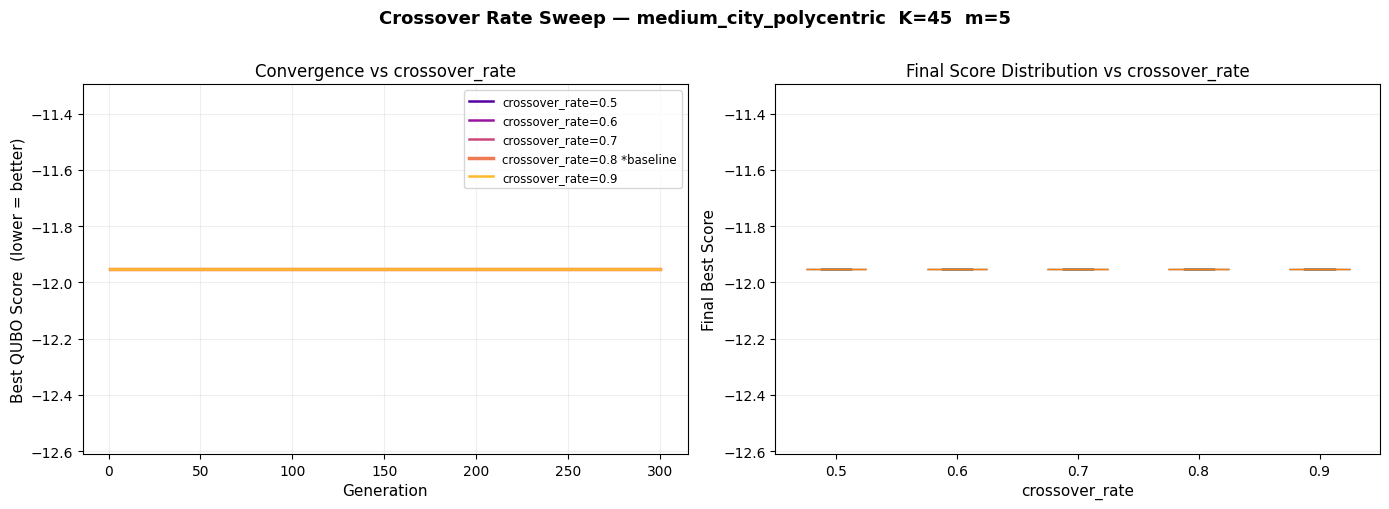

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Sweep 3: Crossover Rate
# ─────────────────────────────────────────────────────────────────────────────

PARAM = 'crossover_rate'
VALUES = SWEEP_VALUES[PARAM]
print(f'Sweep: {PARAM} over {VALUES}  ({N_SEEDS} seeds each)\n')

sweep_cross = run_sweep(Q_pruned, qubit_to_cell, K, M, PARAM, VALUES, BASELINE, SEEDS)
ALL_SWEEP_RESULTS[PARAM] = sweep_cross

print()
sweep_summary_table(sweep_cross, PARAM, BASELINE[PARAM])
print()

_ = plot_sweep(
    sweep_cross, PARAM, BASELINE[PARAM],
    fig_title=f'Crossover Rate Sweep — {data["dataset_name"]}  K={K}  m={M}',
)

Sweep: mutation_rate over [0.05, 0.1, 0.15, 0.2, 0.3]  (5 seeds each)

  mutation_rate=0.05     | score=-11.9530 | conv_gen=1 | time=0.188s
  mutation_rate=0.1      | score=-11.9530 | conv_gen=1 | time=0.193s
  mutation_rate=0.15     | score=-11.9530 | conv_gen=1 | time=0.199s
  mutation_rate=0.2      | score=-11.9530 | conv_gen=1 | time=0.204s
  mutation_rate=0.3      | score=-11.9530 | conv_gen=1 | time=0.218s

mutation_rate      mean_score    std_score    conv_gen  mean_time
---------------  ------------  -----------  ----------  -----------
0.05                  -11.953            0           1  0.188s
0.1                   -11.953            0           1  0.193s
0.15                  -11.953            0           1  0.199s
0.2 *                 -11.953            0           1  0.204s
0.3                   -11.953            0           1  0.218s



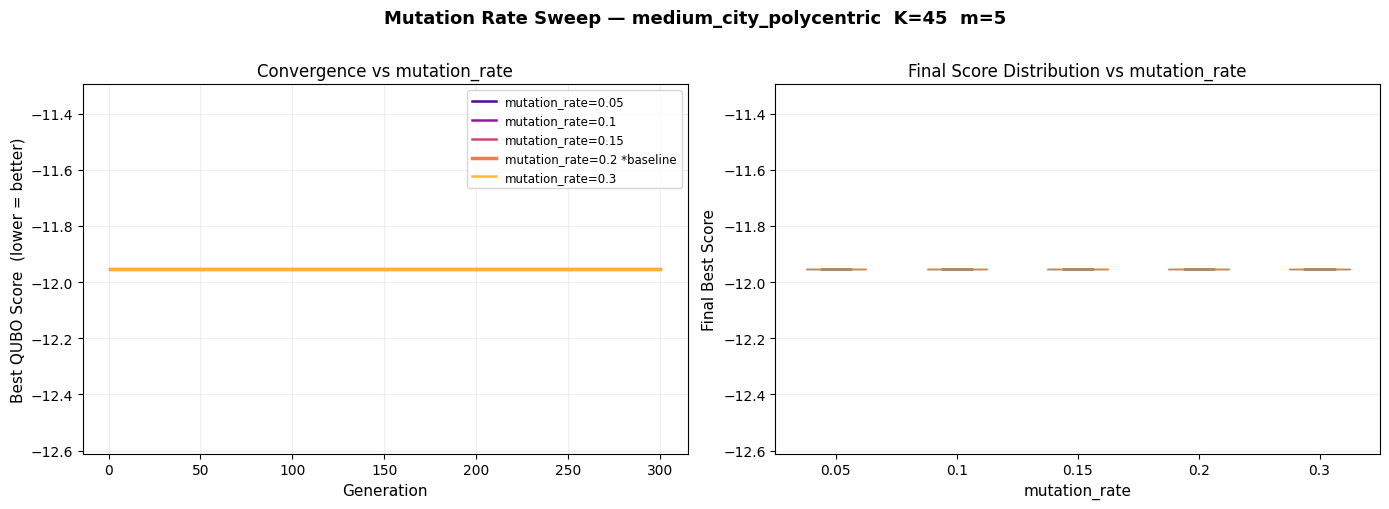

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Sweep 4: Mutation Rate
# ─────────────────────────────────────────────────────────────────────────────

PARAM = 'mutation_rate'
VALUES = SWEEP_VALUES[PARAM]
print(f'Sweep: {PARAM} over {VALUES}  ({N_SEEDS} seeds each)\n')

sweep_mut = run_sweep(Q_pruned, qubit_to_cell, K, M, PARAM, VALUES, BASELINE, SEEDS)
ALL_SWEEP_RESULTS[PARAM] = sweep_mut

print()
sweep_summary_table(sweep_mut, PARAM, BASELINE[PARAM])
print()

_ = plot_sweep(
    sweep_mut, PARAM, BASELINE[PARAM],
    fig_title=f'Mutation Rate Sweep — {data["dataset_name"]}  K={K}  m={M}',
)

Sweep: tournament_size over [2, 3, 5, 7, 10]  (5 seeds each)

  tournament_size=2        | score=-11.9530 | conv_gen=1 | time=0.211s
  tournament_size=3        | score=-11.9530 | conv_gen=1 | time=0.208s
  tournament_size=5        | score=-11.9530 | conv_gen=1 | time=0.209s
  tournament_size=7        | score=-11.9530 | conv_gen=1 | time=0.217s
  tournament_size=10       | score=-11.9530 | conv_gen=1 | time=0.208s

tournament_size      mean_score    std_score    conv_gen  mean_time
-----------------  ------------  -----------  ----------  -----------
2                       -11.953            0           1  0.211s
3 *                     -11.953            0           1  0.208s
5                       -11.953            0           1  0.209s
7                       -11.953            0           1  0.217s
10                      -11.953            0           1  0.208s



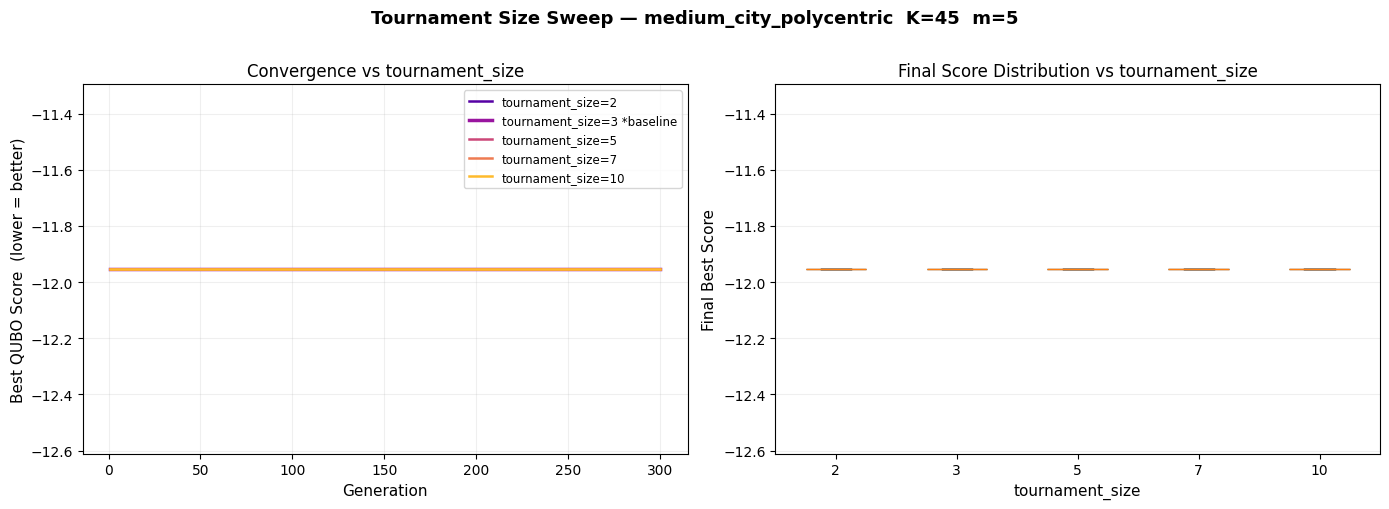

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Sweep 5: Tournament Size
# ─────────────────────────────────────────────────────────────────────────────

PARAM = 'tournament_size'
VALUES = SWEEP_VALUES[PARAM]
print(f'Sweep: {PARAM} over {VALUES}  ({N_SEEDS} seeds each)\n')

sweep_tourn = run_sweep(Q_pruned, qubit_to_cell, K, M, PARAM, VALUES, BASELINE, SEEDS)
ALL_SWEEP_RESULTS[PARAM] = sweep_tourn

print()
sweep_summary_table(sweep_tourn, PARAM, BASELINE[PARAM])
print()

_ = plot_sweep(
    sweep_tourn, PARAM, BASELINE[PARAM],
    fig_title=f'Tournament Size Sweep — {data["dataset_name"]}  K={K}  m={M}',
)

Sweep: seed_mode over ['random', 'greedy']  (5 seeds each)

  seed_mode=random   | score=-11.9530 | conv_gen=42 | time=0.207s
  seed_mode=greedy   | score=-11.9530 | conv_gen=1 | time=0.209s

seed_mode      mean_score    std_score    conv_gen  mean_time
-----------  ------------  -----------  ----------  -----------
greedy *          -11.953            0           1  0.209s
random            -11.953            0          42  0.207s



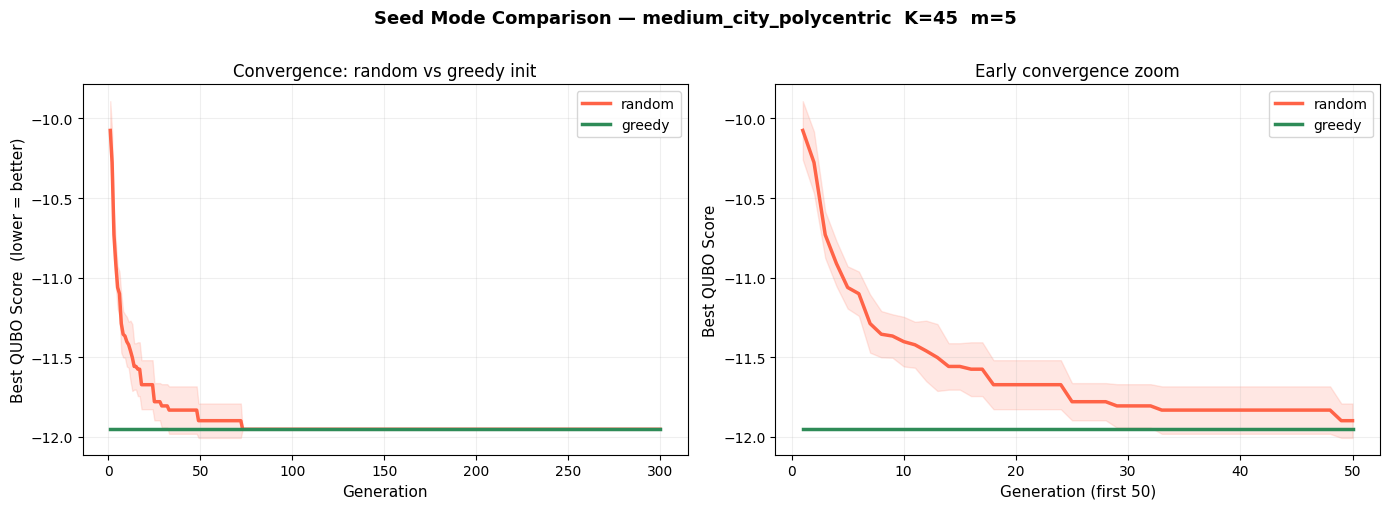

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Sweep 6: Seed Mode — random vs greedy
# ─────────────────────────────────────────────────────────────────────────────

PARAM = 'seed_mode'
VALUES = ['random', 'greedy']
print(f'Sweep: {PARAM} over {VALUES}  ({N_SEEDS} seeds each)\n')

sweep_mode = run_sweep(Q_pruned, qubit_to_cell, K, M, PARAM, VALUES, BASELINE, SEEDS)
ALL_SWEEP_RESULTS[PARAM] = sweep_mode

print()
sweep_summary_table(sweep_mode, PARAM, BASELINE[PARAM])
print()

# Custom convergence comparison for seed modes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mode_colors = {'random': 'tomato', 'greedy': 'seagreen'}

for mode in VALUES:
    color  = mode_colors[mode]
    curves = [r['convergence'] for r in sweep_mode[mode]]
    max_len = max(len(c) for c in curves)
    padded  = np.array([c + [c[-1]] * (max_len - len(c)) for c in curves])
    mean = padded.mean(axis=0)
    std  = padded.std(axis=0)
    gens = np.arange(1, max_len + 1)
    axes[0].plot(gens, mean, color=color, linewidth=2.5, label=mode)
    axes[0].fill_between(gens, mean - std, mean + std, color=color, alpha=0.15)

axes[0].set_xlabel('Generation', fontsize=11)
axes[0].set_ylabel('Best QUBO Score  (lower = better)', fontsize=11)
axes[0].set_title('Convergence: random vs greedy init', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.2)

# Highlight early gens zoom
for mode in VALUES:
    color  = mode_colors[mode]
    curves = [r['convergence'] for r in sweep_mode[mode]]
    max_len = max(len(c) for c in curves)
    padded  = np.array([c + [c[-1]] * (max_len - len(c)) for c in curves])
    mean = padded.mean(axis=0)
    std  = padded.std(axis=0)
    zoom = min(50, max_len)
    gens = np.arange(1, zoom + 1)
    axes[1].plot(gens, mean[:zoom], color=color, linewidth=2.5, label=mode)
    axes[1].fill_between(gens, mean[:zoom] - std[:zoom], mean[:zoom] + std[:zoom],
                         color=color, alpha=0.15)

axes[1].set_xlabel('Generation (first 50)', fontsize=11)
axes[1].set_ylabel('Best QUBO Score', fontsize=11)
axes[1].set_title('Early convergence zoom', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.2)

fig.suptitle(f'Seed Mode Comparison — {data["dataset_name"]}  K={K}  m={M}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

PARAMETER SWEEP MASTER SUMMARY
Dataset: medium_city_polycentric  K=45  m=5  seeds=5
Parameter        Baseline      Baseline Score  Best Value      Best Score    Improvement
---------------  ----------  ----------------  ------------  ------------  -------------
population_size  50                   -11.953  20                 -11.953              0
n_generations    300                  -11.953  50                 -11.953              0
crossover_rate   0.8                  -11.953  0.5                -11.953              0
mutation_rate    0.2                  -11.953  0.05               -11.953              0
tournament_size  3                    -11.953  2                  -11.953              0
seed_mode        greedy               -11.953  random             -11.953              0

Note: Improvement = baseline_score - best_score (positive = better with best_val)


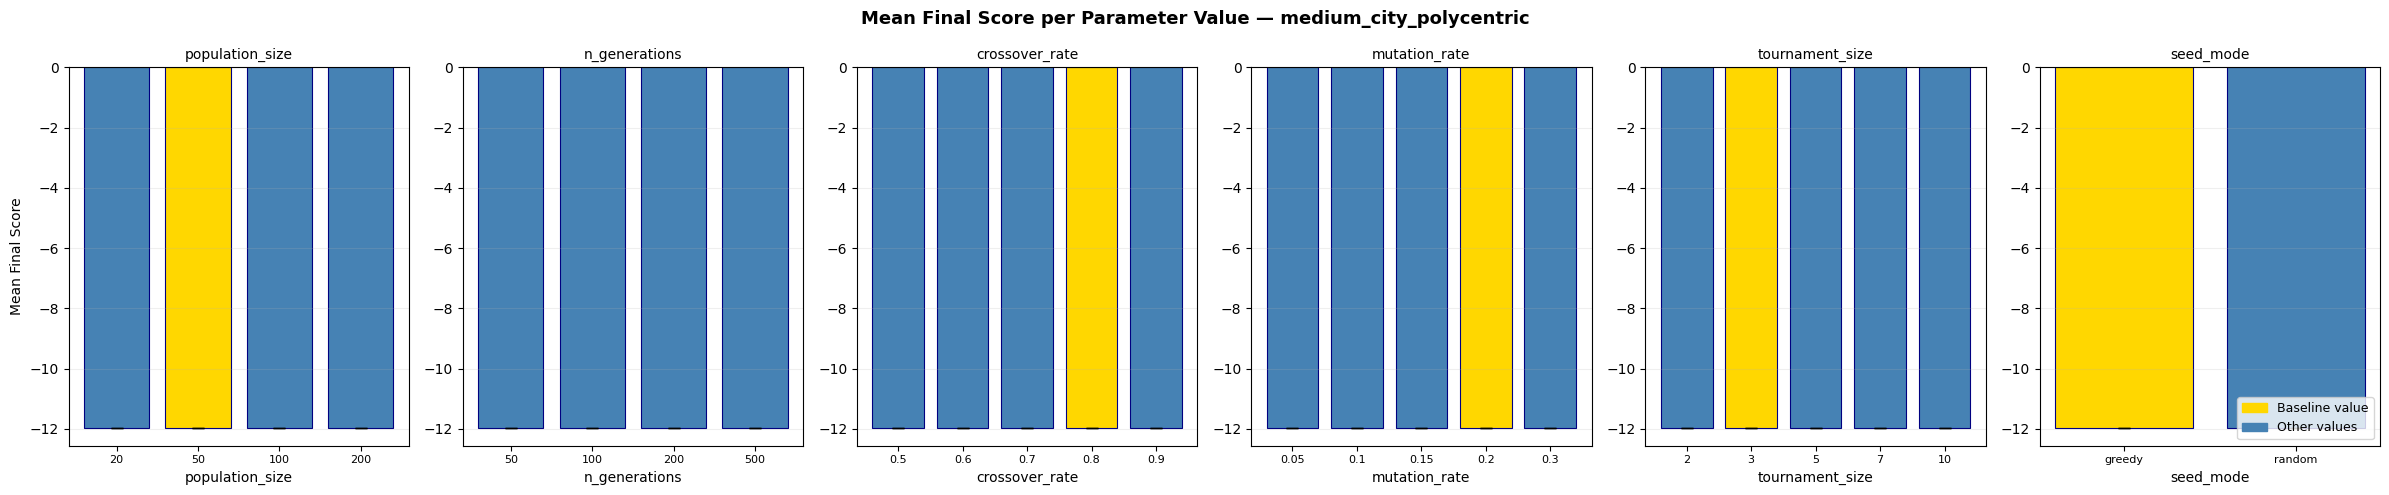

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Parameter sweep master summary
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 75)
print('PARAMETER SWEEP MASTER SUMMARY')
print(f'Dataset: {data["dataset_name"]}  K={K}  m={M}  seeds={N_SEEDS}')
print('=' * 75)

master_rows = []
for param_name, sweep_res in ALL_SWEEP_RESULTS.items():
    best_val     = None
    best_score_m = float('inf')
    for val, runs in sweep_res.items():
        sm = np.mean([r['best_score'] for r in runs])
        if sm < best_score_m:
            best_score_m = sm
            best_val = val
    baseline_v = BASELINE.get(param_name, 'N/A')
    baseline_runs = sweep_res.get(baseline_v, list(sweep_res.values())[0])
    baseline_sm = np.mean([r['best_score'] for r in baseline_runs])
    improvement = baseline_sm - best_score_m  # negative score, so positive = improvement
    master_rows.append([
        param_name,
        str(baseline_v),
        f'{baseline_sm:.4f}',
        str(best_val),
        f'{best_score_m:.4f}',
        f'{improvement:.4f}',
    ])

print(tabulate(master_rows,
               headers=['Parameter', 'Baseline', 'Baseline Score',
                        'Best Value', 'Best Score', 'Improvement'],
               tablefmt='simple'))
print()
print('Note: Improvement = baseline_score - best_score (positive = better with best_val)')

# Heatmap: mean final score across all params × values
fig, axes = plt.subplots(1, len(ALL_SWEEP_RESULTS), figsize=(4 * len(ALL_SWEEP_RESULTS), 5),
                         sharey=False)
if len(ALL_SWEEP_RESULTS) == 1:
    axes = [axes]

for ax, (param_name, sweep_res) in zip(axes, ALL_SWEEP_RESULTS.items()):
    vals   = sorted(sweep_res.keys())
    scores = [np.mean([r['best_score'] for r in sweep_res[v]]) for v in vals]
    stds   = [np.std([r['best_score']  for r in sweep_res[v]]) for v in vals]
    colors_bar = ['gold' if v == BASELINE.get(param_name) else 'steelblue' for v in vals]
    bars = ax.bar([str(v) for v in vals], scores, color=colors_bar,
                  edgecolor='navy', linewidth=0.8)
    ax.errorbar([str(v) for v in vals], scores, yerr=stds,
                fmt='none', color='black', capsize=4, linewidth=1.5)
    ax.set_xlabel(param_name, fontsize=10)
    ax.set_ylabel('Mean Final Score' if ax == axes[0] else '', fontsize=10)
    ax.set_title(param_name, fontsize=10)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(True, alpha=0.2, axis='y')

# Add legend
baseline_patch = mpatches.Patch(color='gold', label='Baseline value')
other_patch    = mpatches.Patch(color='steelblue', label='Other values')
axes[-1].legend(handles=[baseline_patch, other_patch], loc='lower right', fontsize=9)

fig.suptitle(f'Mean Final Score per Parameter Value — {data["dataset_name"]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4 — Pruning Effect on GA

**Question:** How much does pruning help?

We run the same GA with the same parameters on:
- **Full QUBO**: K = N = 196 cells, C(196,5) ≈ 2.3B search space
- **Pruned QUBO**: K ≈ 45 cells, C(45,5) ≈ 1.2M search space

Metrics: solution quality (baseline_eval score), convergence speed, runtime.

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# GA on full Q_obj (K = N_QUBITS = 196)
# Q_obj keys are cell IDs 0..N-1, which double as qubit indices 0..N-1.
# ─────────────────────────────────────────────────────────────────────────────

qubit_to_cell_full = {i: i for i in range(N_QUBITS)}

print(f'Running GA on FULL Q_obj (K={N_QUBITS})...')
print(f'  Search space: C({N_QUBITS},{M}) = {math.comb(N_QUBITS, M):,}')
print(f'  Params: {BASELINE}\n')

runs_full = []
for seed in SEEDS:
    r = run_ga(
        Q_obj, qubit_to_cell_full, K=N_QUBITS, m=M,
        **BASELINE, verbose=False, seed=seed,
    )
    runs_full.append(r)
    print(f'  seed={seed}  score={r["best_score"]:.4f}  time={r["runtime_sec"]:.2f}s  cells={r["best_solution"]}')

print(f'\nFull GA: mean score = {np.mean([r["best_score"] for r in runs_full]):.4f}  '
      f'mean time = {np.mean([r["runtime_sec"] for r in runs_full]):.2f}s')

print()
print(f'Running GA on PRUNED Q_pruned (K={K})...')
print(f'  Search space: C({K},{M}) = {math.comb(K, M):,}')
print(f'  Params: {BASELINE}\n')

runs_pruned = []
for seed in SEEDS:
    r = run_ga(
        Q_pruned, qubit_to_cell, K=K, m=M,
        **BASELINE, verbose=False, seed=seed,
    )
    runs_pruned.append(r)
    print(f'  seed={seed}  score={r["best_score"]:.4f}  time={r["runtime_sec"]:.3f}s  cells={r["best_solution"]}')

print(f'\nPruned GA: mean score = {np.mean([r["best_score"] for r in runs_pruned]):.4f}  '
      f'mean time = {np.mean([r["runtime_sec"] for r in runs_pruned]):.3f}s')

Running GA on FULL Q_obj (K=196)...
  Search space: C(196,5) = 2,289,653,184
  Params: {'population_size': 50, 'n_generations': 300, 'crossover_rate': 0.8, 'mutation_rate': 0.2, 'tournament_size': 3, 'seed_mode': 'greedy'}

  seed=0  score=-11.9530  time=0.70s  cells=[78, 104, 116, 122, 161]
  seed=1  score=-11.9530  time=0.69s  cells=[78, 104, 116, 122, 161]
  seed=2  score=-11.9530  time=0.69s  cells=[78, 104, 116, 122, 161]
  seed=3  score=-11.9530  time=0.69s  cells=[78, 104, 116, 122, 161]
  seed=4  score=-11.9530  time=0.69s  cells=[78, 104, 116, 122, 161]

Full GA: mean score = -11.9530  mean time = 0.69s

Running GA on PRUNED Q_pruned (K=45)...
  Search space: C(45,5) = 1,221,759
  Params: {'population_size': 50, 'n_generations': 300, 'crossover_rate': 0.8, 'mutation_rate': 0.2, 'tournament_size': 3, 'seed_mode': 'greedy'}

  seed=0  score=-11.9530  time=0.204s  cells=[78, 104, 116, 122, 161]
  seed=1  score=-11.9530  time=0.209s  cells=[78, 104, 116, 122, 161]
  seed=2  score=

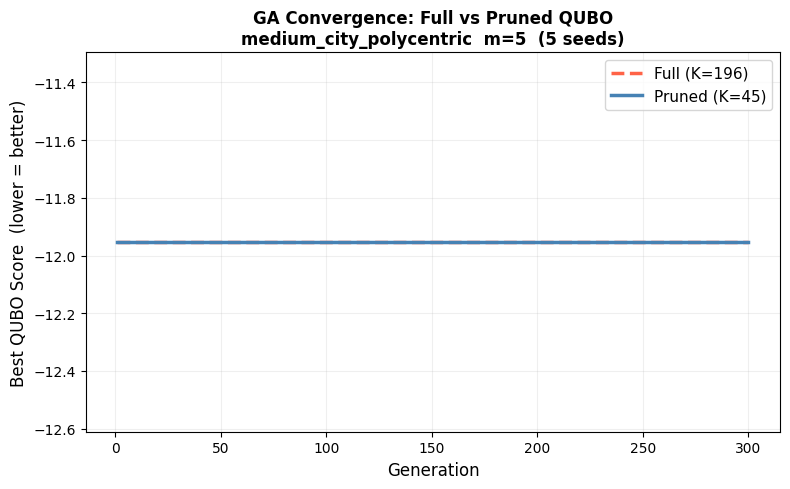

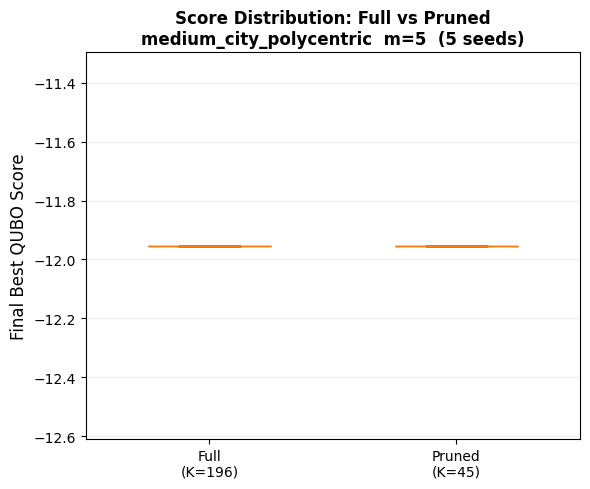

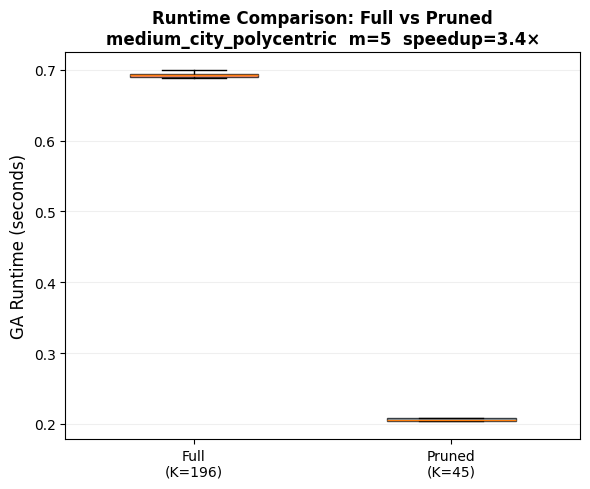

PRUNING EFFECT SUMMARY
  Search space: C(196,5)=2,289,653,184  ->  C(45,5)=1,221,759  (99.95% smaller)
  Mean score — full   : -11.9530  +/-0.0000
  Mean score — pruned : -11.9530  +/-0.0000
  Score gap (full-pruned): +0.0000  (equal)
  Mean time — full    : 0.693s
  Mean time — pruned  : 0.206s
  Speedup from pruning: 3.4x
  Conv. gen — full    : 1
  Conv. gen — pruned  : 1


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Pruning effect visualizations — 3 separate publication-ready figures
# ─────────────────────────────────────────────────────────────────────────────

_curves_label_data = [
    (f'Full (K={N_QUBITS})',    runs_full,   'tomato',   '--'),
    (f'Pruned (K={K})', runs_pruned, 'steelblue', '-'),
]
full_scores   = [r['best_score']  for r in runs_full]
pruned_scores = [r['best_score']  for r in runs_pruned]
full_times    = [r['runtime_sec'] for r in runs_full]
pruned_times  = [r['runtime_sec'] for r in runs_pruned]
speedup       = np.mean(full_times) / np.mean(pruned_times)
_ds_title     = data['dataset_name']

# ── Figure 1: Convergence ─────────────────────────────────────────────────────
fig_conv, ax1 = plt.subplots(figsize=(8, 5))
for label, runs, color, ls in _curves_label_data:
    curves  = [r['convergence'] for r in runs]
    max_len = max(len(c) for c in curves)
    padded  = np.array([c + [c[-1]] * (max_len - len(c)) for c in curves])
    mean = padded.mean(axis=0)
    std  = padded.std(axis=0)
    gens = np.arange(1, max_len + 1)
    ax1.plot(gens, mean, color=color, linewidth=2.5, linestyle=ls, label=label)
    ax1.fill_between(gens, mean - std, mean + std, color=color, alpha=0.15)
ax1.set_xlabel('Generation', fontsize=12)
ax1.set_ylabel('Best QUBO Score  (lower = better)', fontsize=12)
ax1.set_title(
    f'GA Convergence: Full vs Pruned QUBO\n{_ds_title}  m={M}  ({N_SEEDS} seeds)',
    fontsize=12, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# ── Figure 2: Final score distribution ───────────────────────────────────────
fig_scores, ax2 = plt.subplots(figsize=(6, 5))
bp = ax2.boxplot([full_scores, pruned_scores],
                 tick_labels=[f'Full\n(K={N_QUBITS})', f'Pruned\n(K={K})'],
                 patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('tomato');    bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('steelblue'); bp['boxes'][1].set_alpha(0.7)
ax2.set_ylabel('Final Best QUBO Score', fontsize=12)
ax2.set_title(
    f'Score Distribution: Full vs Pruned\n{_ds_title}  m={M}  ({N_SEEDS} seeds)',
    fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

# ── Figure 3: Runtime comparison ──────────────────────────────────────────────
fig_runtime, ax3 = plt.subplots(figsize=(6, 5))
bp2 = ax3.boxplot([full_times, pruned_times],
                  tick_labels=[f'Full\n(K={N_QUBITS})', f'Pruned\n(K={K})'],
                  patch_artist=True, widths=0.5)
bp2['boxes'][0].set_facecolor('tomato');    bp2['boxes'][0].set_alpha(0.7)
bp2['boxes'][1].set_facecolor('steelblue'); bp2['boxes'][1].set_alpha(0.7)
ax3.set_ylabel('GA Runtime (seconds)', fontsize=12)
ax3.set_title(
    f'Runtime Comparison: Full vs Pruned\n{_ds_title}  m={M}  speedup={speedup:.1f}×',
    fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

# Numeric summary
score_gap = np.mean(full_scores) - np.mean(pruned_scores)
gap_label = '(pruned is better)' if score_gap > 0 else ('(full is better)' if score_gap < 0 else '(equal)')
search_full   = math.comb(N_QUBITS, M)
search_pruned = math.comb(K, M)
search_pct    = 100 * (1 - search_pruned / search_full)
print('PRUNING EFFECT SUMMARY')
print(f'  Search space: C({N_QUBITS},{M})={search_full:,}  ->  C({K},{M})={search_pruned:,}  ({search_pct:.2f}% smaller)')
print(f'  Mean score — full   : {np.mean(full_scores):.4f}  +/-{np.std(full_scores):.4f}')
print(f'  Mean score — pruned : {np.mean(pruned_scores):.4f}  +/-{np.std(pruned_scores):.4f}')
print(f'  Score gap (full-pruned): {score_gap:+.4f}  {gap_label}')
print(f'  Mean time — full    : {np.mean(full_times):.3f}s')
print(f'  Mean time — pruned  : {np.mean(pruned_times):.3f}s')
print(f'  Speedup from pruning: {speedup:.1f}x')
print(f'  Conv. gen — full    : {np.mean([_conv_gen(r["convergence"]) for r in runs_full]):.0f}')
print(f'  Conv. gen — pruned  : {np.mean([_conv_gen(r["convergence"]) for r in runs_pruned]):.0f}')


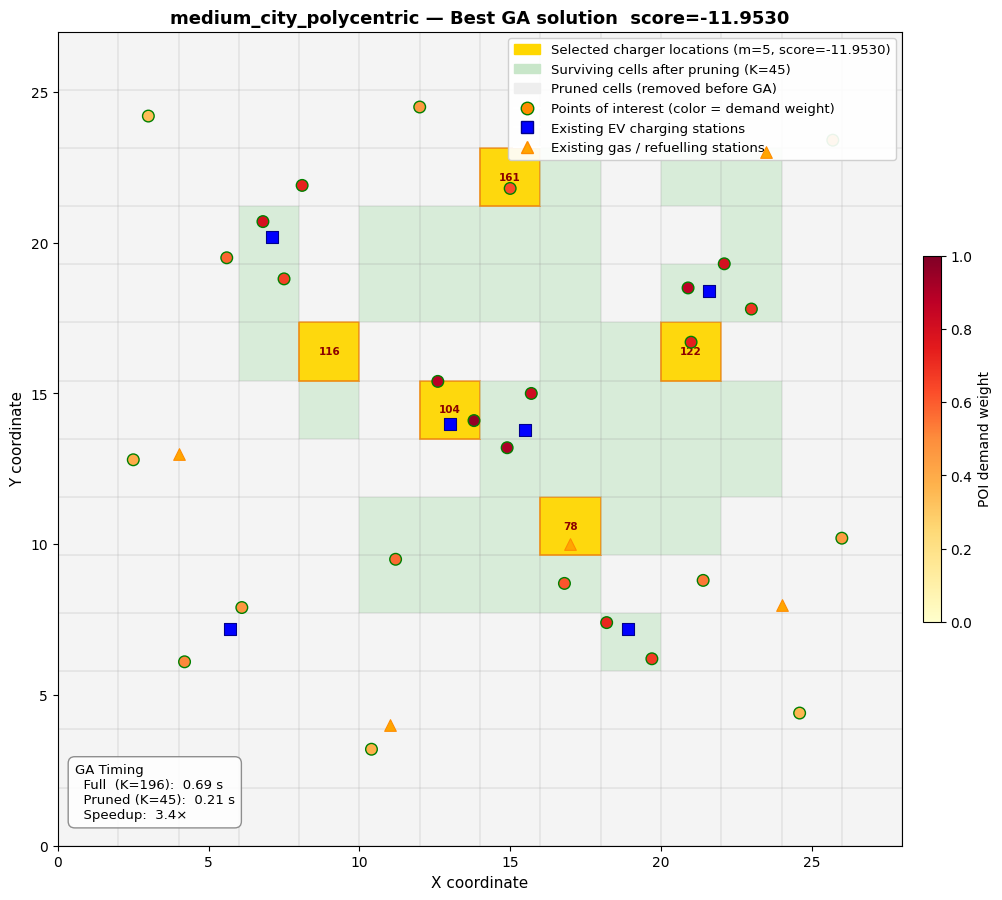

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Best solution grid — pruned GA (best across all seeds)
# ─────────────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D

best_run       = min(runs_pruned, key=lambda r: r['best_score'])
best_cells_set = set(best_run['best_solution'])
surv_set       = set(surviving_cells)

mean_time_pruned = np.mean([r['runtime_sec'] for r in runs_pruned])
mean_time_full   = np.mean([r['runtime_sec'] for r in runs_full])
speedup_val      = mean_time_full / mean_time_pruned

fig_sol, ax = plt.subplots(figsize=(11, 9))
ax.set_facecolor('#f8f8f8')

for i in range(plot_deets['num_cols'] + 1):
    ax.axvline(X_MIN + i * cell_w, color='gray', linewidth=0.15)
for j in range(plot_deets['num_rows'] + 1):
    ax.axhline(Y_MIN + j * cell_h, color='gray', linewidth=0.15)

for gid, info in grid_details.items():
    cx, cy = info['x_start'], info['y_start']
    if gid in best_cells_set:
        col, al, ed, ew = 'gold', 0.95, 'darkorange', 1.2
    elif gid in surv_set:
        col, al, ed, ew = '#c8e6c9', 0.65, 'lightgray', 0.15
    else:
        col, al, ed, ew = '#eeeeee', 0.30, 'lightgray', 0.10
    ax.add_patch(plt.Rectangle((cx, cy), cell_w, cell_h,
                               facecolor=col, alpha=al, edgecolor=ed, linewidth=ew))
    if gid in best_cells_set:
        ax.text(cx + cell_w/2, cy + cell_h/2, str(gid),
                ha='center', va='center', fontsize=7.5, fontweight='bold', color='darkred')

# POIs with colorbar
poi_sc = None
if points_of_interest:
    poi_sc = ax.scatter([p[0] for p in points_of_interest],
                        [p[1] for p in points_of_interest],
                        c=[p[2] for p in points_of_interest], cmap='YlOrRd',
                        edgecolors='green', linewidths=1, s=70, vmin=0, vmax=1, zorder=5)
    plt.colorbar(poi_sc, ax=ax, shrink=0.45, pad=0.02, label='POI demand weight')

if existing_charging_points:
    ax.scatter(*zip(*existing_charging_points), color='blue', marker='s',
               s=70, zorder=6, edgecolors='darkblue', linewidths=0.8)
if gas_stations:
    ax.scatter(*zip(*gas_stations), color='orange', marker='^',
               s=70, zorder=6, edgecolors='darkorange', linewidths=0.8)

# Complete legend
legend_handles = [
    mpatches.Patch(color='gold',    label=f'Selected charger locations (m={M}, score={best_run["best_score"]:.4f})'),
    mpatches.Patch(color='#c8e6c9', label=f'Surviving cells after pruning (K={K})'),
    mpatches.Patch(color='#eeeeee', label='Pruned cells (removed before GA)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF8C00',
           markeredgecolor='green', markersize=9,
           label='Points of interest (color = demand weight)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='blue',
           markeredgecolor='darkblue', markersize=9,
           label='Existing EV charging stations'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='orange',
           markeredgecolor='darkorange', markersize=9,
           label='Existing gas / refuelling stations'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9.5, framealpha=0.92)

# Timing annotation
timing_text = (
    f'GA Timing\n'
    f'  Full  (K={N_QUBITS}):  {mean_time_full:.2f} s\n'
    f'  Pruned (K={K}):  {mean_time_pruned:.2f} s\n'
    f'  Speedup:  {speedup_val:.1f}×'
)
ax.text(0.02, 0.03, timing_text,
        transform=ax.transAxes, fontsize=9.5, verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.88, edgecolor='gray'))

ax.set_xlim(X_MIN, X_MAX); ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel('X coordinate', fontsize=11)
ax.set_ylabel('Y coordinate', fontsize=11)
ax.set_title(
    f"{data['dataset_name']} — Best GA solution  score={best_run['best_score']:.4f}",
    fontsize=13, fontweight='bold',
)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


Publication exports -> /Users/abhimuvva/Documents/Proj_HGQA/results/classical_tuning/publication_exports/run_20260528_115539/medium_city_polycentric


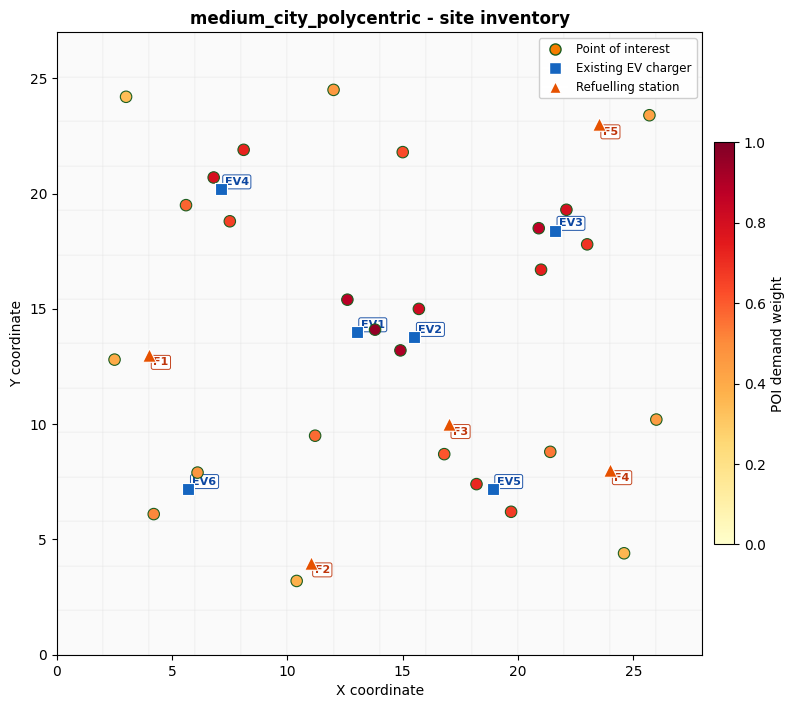

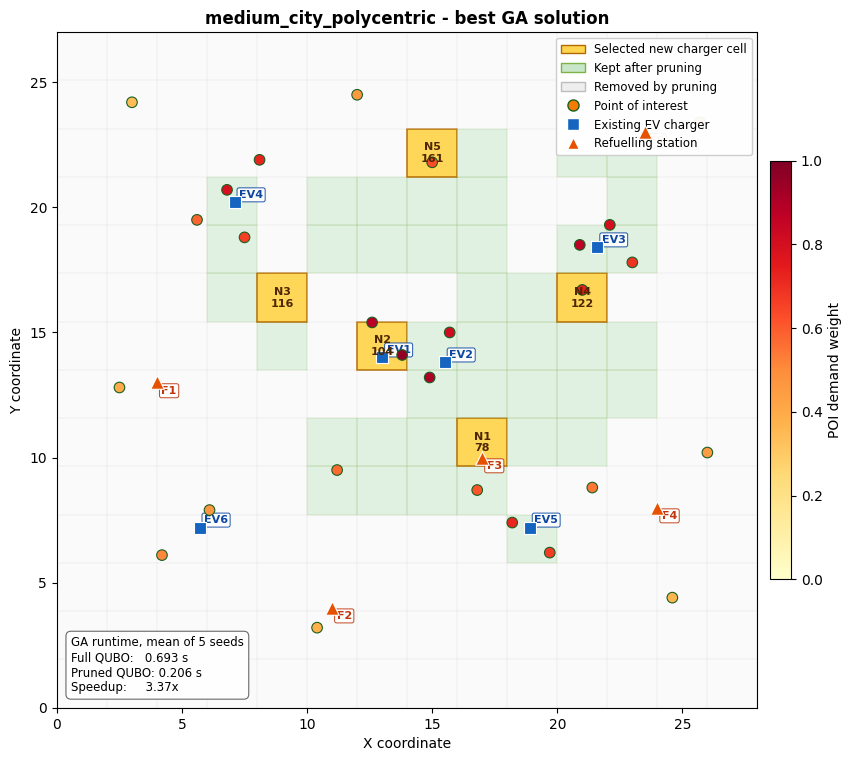

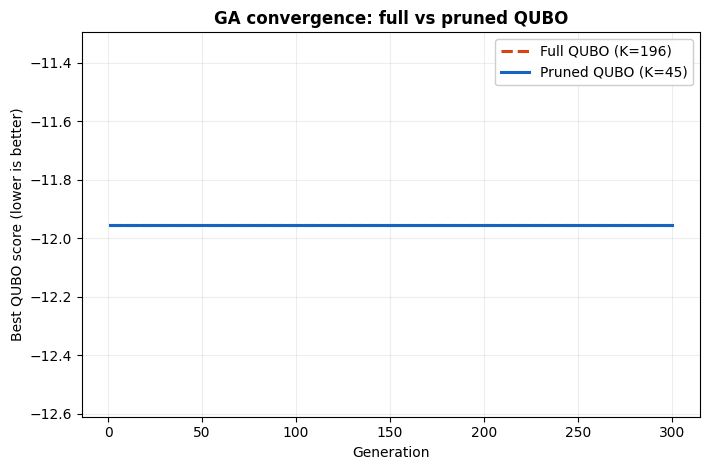

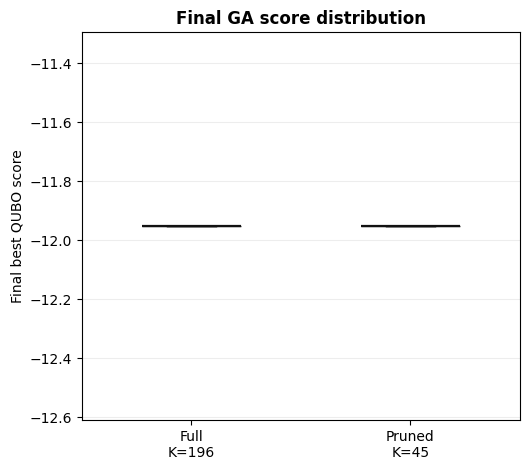

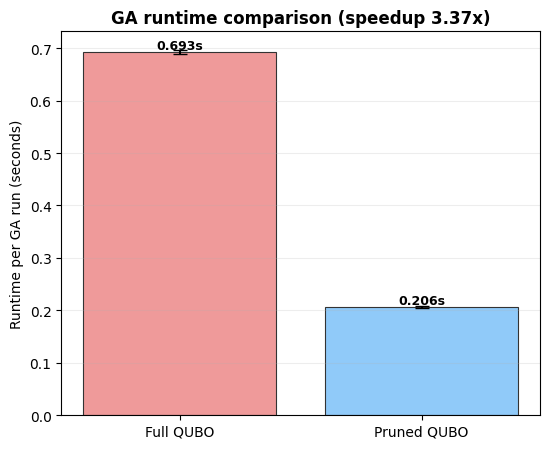

Saved publication files:
  01_site_inventory_labeled.png
  02_best_solution_labeled.png
  03_ga_convergence_full_vs_pruned.png
  04_ga_score_distribution.png
  05_ga_runtime_comparison.png
  ga_timing_summary.json
  selected_cells.json


In [29]:
# -----------------------------------------------------------------------------
# Publication-ready single-purpose exports
# Creates separate figures with explicit marker legends and GA timing callouts.
# -----------------------------------------------------------------------------
from matplotlib.lines import Line2D

_pub_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
_pub_dir = (_Path.cwd().parent / 'results' / 'classical_tuning' /
            'publication_exports' / f'run_{_pub_ts}' / data['dataset_name'])
_pub_dir.mkdir(parents=True, exist_ok=True)
print(f'Publication exports -> {_pub_dir}')

best_run = min(runs_pruned, key=lambda r: r['best_score'])
best_cells_set = set(best_run['best_solution'])
surv_set = set(surviving_cells)
full_scores = [r['best_score'] for r in runs_full]
pruned_scores = [r['best_score'] for r in runs_pruned]
full_times = [r['runtime_sec'] for r in runs_full]
pruned_times = [r['runtime_sec'] for r in runs_pruned]
mean_full_time = float(np.mean(full_times))
mean_pruned_time = float(np.mean(pruned_times))
speedup_val = mean_full_time / mean_pruned_time if mean_pruned_time else float('inf')


def _draw_grid_background(ax, selected=None, show_survivors=True):
    selected = set(selected or [])
    ax.set_facecolor('white')
    for gid, info in grid_details.items():
        cx, cy = info['x_start'], info['y_start']
        if gid in selected:
            face, alpha, edge, lw = '#FFD54F', 0.95, '#B26A00', 1.1
        elif show_survivors and gid in surv_set:
            face, alpha, edge, lw = '#C8E6C9', 0.55, '#7CB342', 0.25
        elif show_survivors:
            face, alpha, edge, lw = '#EEEEEE', 0.28, '#BDBDBD', 0.08
        else:
            face, alpha, edge, lw = '#FAFAFA', 1.0, '#D0D0D0', 0.12
        ax.add_patch(plt.Rectangle((cx, cy), cell_w, cell_h,
                                   facecolor=face, alpha=alpha,
                                   edgecolor=edge, linewidth=lw))
    for i in range(plot_deets['num_cols'] + 1):
        ax.axvline(X_MIN + i * cell_w, color='#D9D9D9', linewidth=0.18, zorder=0)
    for j in range(plot_deets['num_rows'] + 1):
        ax.axhline(Y_MIN + j * cell_h, color='#D9D9D9', linewidth=0.18, zorder=0)
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_aspect('equal')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')


def _label_points(ax, xs, ys, prefix, color, dx=0.18, dy=0.18):
    for idx, (x, y) in enumerate(zip(xs, ys), start=1):
        ax.annotate(f'{prefix}{idx}', xy=(x, y), xytext=(x + dx, y + dy),
                    fontsize=8, color=color, weight='bold',
                    bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                              edgecolor=color, linewidth=0.7, alpha=0.92),
                    arrowprops=dict(arrowstyle='-', color=color, linewidth=0.7,
                                    shrinkA=0, shrinkB=3))


def _plot_landmarks(ax, annotate=True, poi_size=58):
    poi_sc = None
    if points_of_interest:
        px = [p[0] for p in points_of_interest]
        py = [p[1] for p in points_of_interest]
        pw = [p[2] for p in points_of_interest]
        poi_sc = ax.scatter(px, py, c=pw, cmap='YlOrRd', edgecolors='#1B5E20',
                            linewidths=0.8, s=poi_size, vmin=0, vmax=1,
                            marker='o', zorder=5, label='Point of interest')
    if existing_charging_points:
        ex = [p[0] for p in existing_charging_points]
        ey = [p[1] for p in existing_charging_points]
        ax.scatter(ex, ey, color='#1565C0', marker='s', s=82, zorder=7,
                   edgecolors='white', linewidths=0.8, label='Existing EV charger')
        if annotate:
            _label_points(ax, ex, ey, 'EV', '#0D47A1')
    if gas_stations:
        gx = [p[0] for p in gas_stations]
        gy = [p[1] for p in gas_stations]
        ax.scatter(gx, gy, color='#E65100', marker='^', s=95, zorder=7,
                   edgecolors='white', linewidths=0.8, label='Refuelling station')
        if annotate:
            _label_points(ax, gx, gy, 'F', '#BF360C', dx=0.18, dy=-0.45)
    return poi_sc


def _finish_map(ax, title, poi_sc=None, include_solution_legend=False):
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#F57C00',
               markeredgecolor='#1B5E20', markersize=8, label='Point of interest'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#1565C0',
               markeredgecolor='white', markersize=8, label='Existing EV charger'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='#E65100',
               markeredgecolor='white', markersize=9, label='Refuelling station'),
    ]
    if include_solution_legend:
        handles = [
            mpatches.Patch(facecolor='#FFD54F', edgecolor='#B26A00', label='Selected new charger cell'),
            mpatches.Patch(facecolor='#C8E6C9', edgecolor='#7CB342', label='Kept after pruning'),
            mpatches.Patch(facecolor='#EEEEEE', edgecolor='#BDBDBD', label='Removed by pruning'),
        ] + handles
    ax.legend(handles=handles, loc='upper right', framealpha=0.95, fontsize=8.5)
    if poi_sc is not None:
        plt.colorbar(poi_sc, ax=ax, shrink=0.62, pad=0.015, label='POI demand weight')
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()


# 1) Inventory map: only the source data points, with direct labels for EV/Fuel.
fig_inv, ax_inv = plt.subplots(figsize=(8.5, 7.2))
_draw_grid_background(ax_inv, show_survivors=False)
poi_sc = _plot_landmarks(ax_inv, annotate=True, poi_size=68)
_finish_map(ax_inv, f"{data['dataset_name']} - site inventory", poi_sc=poi_sc)
fig_inv.savefig(_pub_dir / '01_site_inventory_labeled.png', dpi=300, bbox_inches='tight')
plt.show()

# 2) Best solution map: selected cells, pruning status, landmarks, and GA time.
fig_best, ax_best = plt.subplots(figsize=(9.2, 7.6))
_draw_grid_background(ax_best, selected=best_cells_set, show_survivors=True)
poi_sc = _plot_landmarks(ax_best, annotate=True, poi_size=58)
for idx, gid in enumerate(sorted(best_cells_set), start=1):
    info = grid_details[gid]
    cx = info['x_start'] + cell_w / 2
    cy = info['y_start'] + cell_h / 2
    ax_best.text(cx, cy, f'N{idx}\n{gid}', ha='center', va='center', fontsize=8,
                 color='#4E2600', weight='bold', zorder=8)
time_text = (f'GA runtime, mean of {N_SEEDS} seeds\n'
             f'Full QUBO:   {mean_full_time:.3f} s\n'
             f'Pruned QUBO: {mean_pruned_time:.3f} s\n'
             f'Speedup:     {speedup_val:.2f}x')
ax_best.text(0.02, 0.02, time_text, transform=ax_best.transAxes, fontsize=8.5,
             va='bottom', ha='left',
             bbox=dict(boxstyle='round,pad=0.42', facecolor='white',
                       edgecolor='#606060', linewidth=0.8, alpha=0.94))
_finish_map(ax_best, f"{data['dataset_name']} - best GA solution", poi_sc=poi_sc,
            include_solution_legend=True)
fig_best.savefig(_pub_dir / '02_best_solution_labeled.png', dpi=300, bbox_inches='tight')
plt.show()

# 3) GA convergence only.
fig_conv, ax_conv = plt.subplots(figsize=(7.2, 4.8))
for label, runs, color, ls in [
    (f'Full QUBO (K={N_QUBITS})', runs_full, '#D84315', '--'),
    (f'Pruned QUBO (K={K})', runs_pruned, '#1565C0', '-'),
]:
    curves = [r['convergence'] for r in runs]
    max_len = max(len(c) for c in curves)
    padded = np.array([c + [c[-1]] * (max_len - len(c)) for c in curves])
    mean = padded.mean(axis=0)
    std = padded.std(axis=0)
    gens = np.arange(1, max_len + 1)
    ax_conv.plot(gens, mean, color=color, linestyle=ls, linewidth=2.2, label=label)
    ax_conv.fill_between(gens, mean - std, mean + std, color=color, alpha=0.14)
ax_conv.set_xlabel('Generation')
ax_conv.set_ylabel('Best QUBO score (lower is better)')
ax_conv.set_title('GA convergence: full vs pruned QUBO', fontweight='bold')
ax_conv.legend(framealpha=0.95)
ax_conv.grid(True, alpha=0.22)
fig_conv.tight_layout()
fig_conv.savefig(_pub_dir / '03_ga_convergence_full_vs_pruned.png', dpi=300, bbox_inches='tight')
plt.show()

# 4) Final score distribution only.
fig_score, ax_score = plt.subplots(figsize=(5.4, 4.8))
bp = ax_score.boxplot([full_scores, pruned_scores],
                      tick_labels=[f'Full\nK={N_QUBITS}', f'Pruned\nK={K}'],
                      patch_artist=True, widths=0.45)
for patch, color in zip(bp['boxes'], ['#EF9A9A', '#90CAF9']):
    patch.set_facecolor(color)
    patch.set_edgecolor('#333333')
for med in bp['medians']:
    med.set_color('#111111')
    med.set_linewidth(1.6)
ax_score.set_ylabel('Final best QUBO score')
ax_score.set_title('Final GA score distribution', fontweight='bold')
ax_score.grid(True, axis='y', alpha=0.22)
fig_score.tight_layout()
fig_score.savefig(_pub_dir / '04_ga_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 5) Runtime comparison only, with values printed on the bars.
fig_time, ax_time = plt.subplots(figsize=(5.6, 4.6))
means = [mean_full_time, mean_pruned_time]
stds = [float(np.std(full_times)), float(np.std(pruned_times))]
bars = ax_time.bar(['Full QUBO', 'Pruned QUBO'], means, yerr=stds,
                   color=['#EF9A9A', '#90CAF9'], edgecolor='#333333',
                   linewidth=0.8, capsize=5)
for bar, val in zip(bars, means):
    ax_time.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}s',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_time.set_ylabel('Runtime per GA run (seconds)')
ax_time.set_title(f'GA runtime comparison (speedup {speedup_val:.2f}x)', fontweight='bold')
ax_time.grid(True, axis='y', alpha=0.22)
fig_time.tight_layout()
fig_time.savefig(_pub_dir / '05_ga_runtime_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 6) Machine-readable selected cells and timing summary.
_selected_rows = []
for idx, gid in enumerate(sorted(best_cells_set), start=1):
    info = grid_details[gid]
    _selected_rows.append({
        'label': f'N{idx}',
        'cell_id': gid,
        'center_x': round(info['x_start'] + cell_w / 2, 4),
        'center_y': round(info['y_start'] + cell_h / 2, 4),
        'best_score': float(best_run['best_score']),
    })
(_pub_dir / 'selected_cells.json').write_text(_json.dumps(_selected_rows, indent=2))
(_pub_dir / 'ga_timing_summary.json').write_text(_json.dumps({
    'dataset': data['dataset_name'],
    'n_seeds': N_SEEDS,
    'full_mean_sec': mean_full_time,
    'full_std_sec': float(np.std(full_times)),
    'pruned_mean_sec': mean_pruned_time,
    'pruned_std_sec': float(np.std(pruned_times)),
    'speedup': speedup_val,
    'full_scores': full_scores,
    'pruned_scores': pruned_scores,
}, indent=2))
print('Saved publication files:')
for _f in sorted(_pub_dir.iterdir()):
    print(f'  {_f.name}')


Saving to: /Users/abhimuvva/Documents/Proj_HGQA/results/classical_tuning/run_20260528_115540/medium_city_polycentric


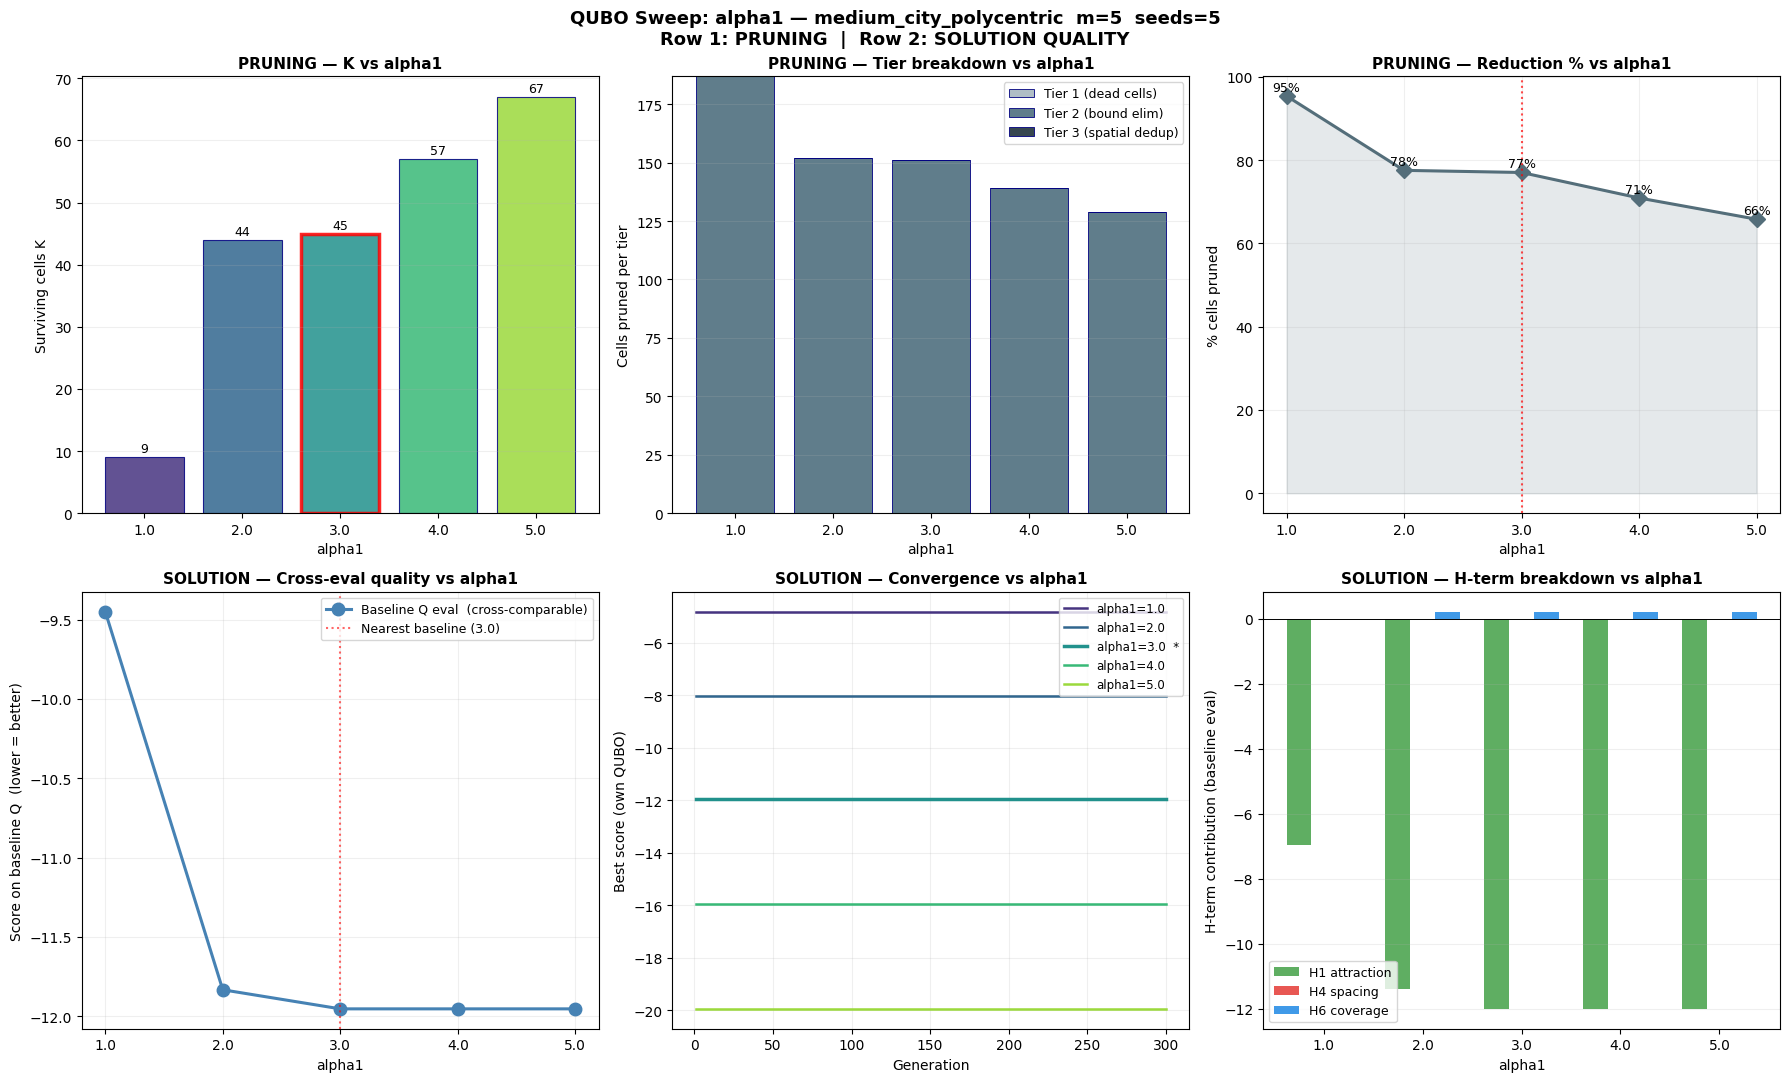

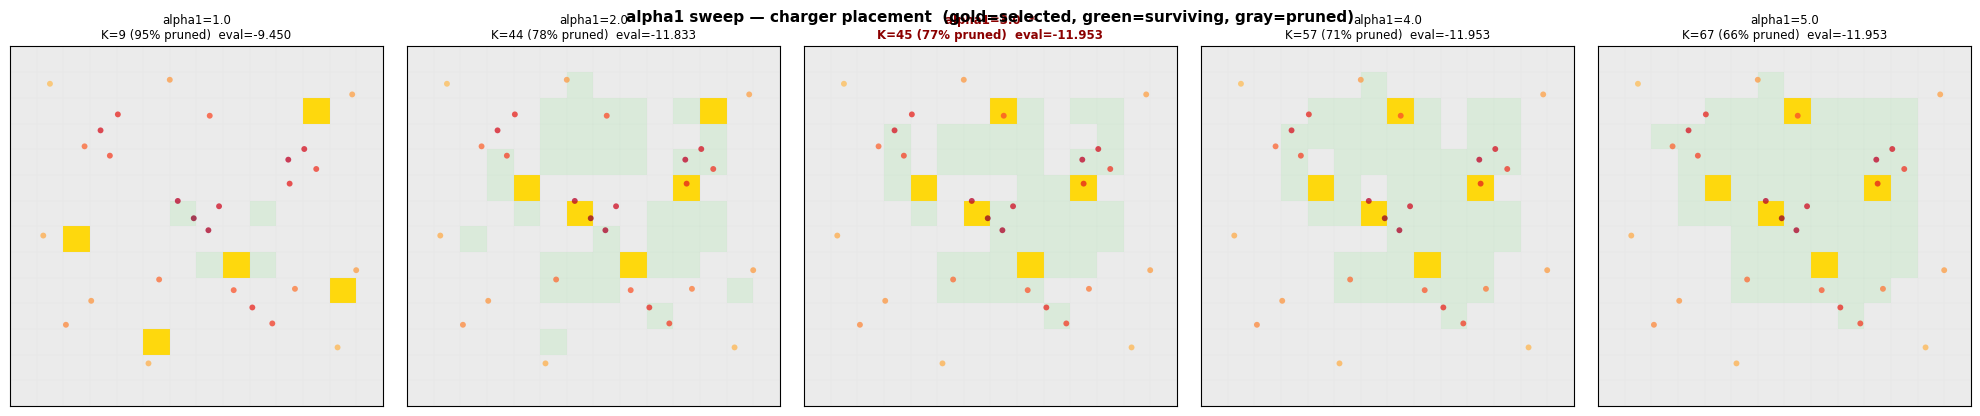

  qubo_alpha1.png + qubo_alpha1_solutions.png


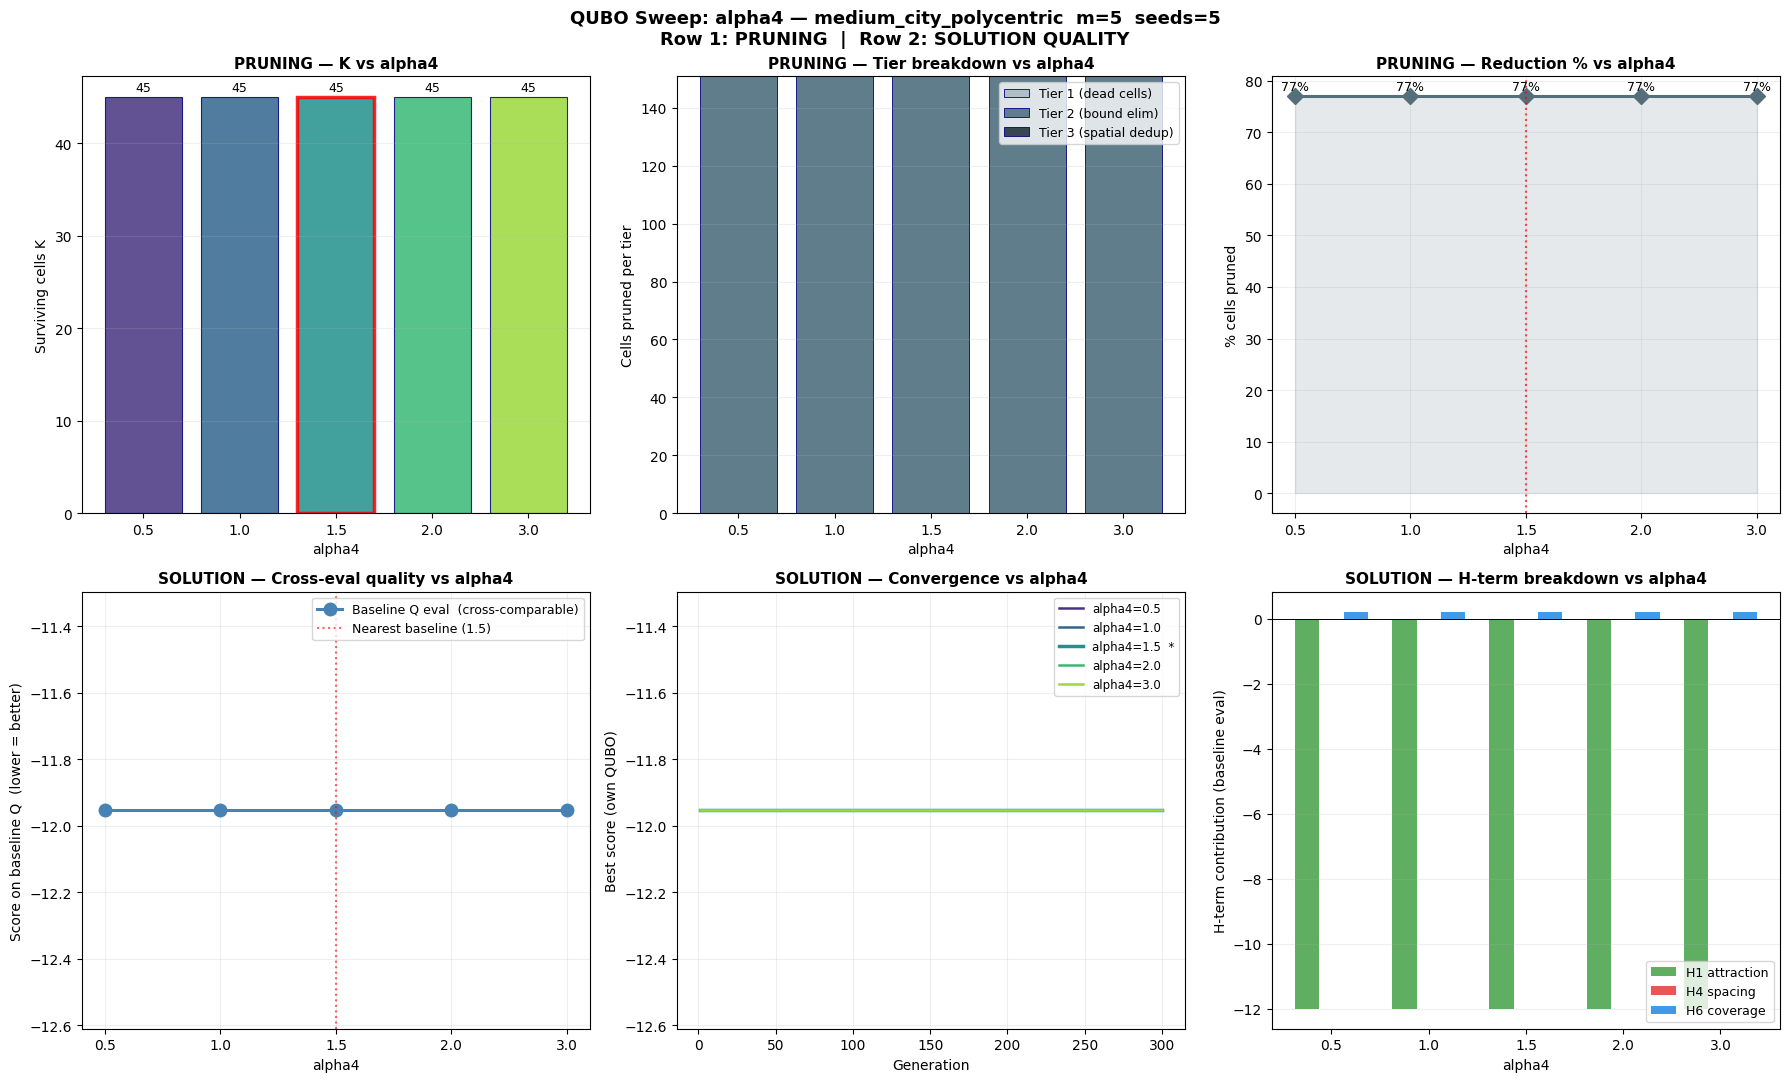

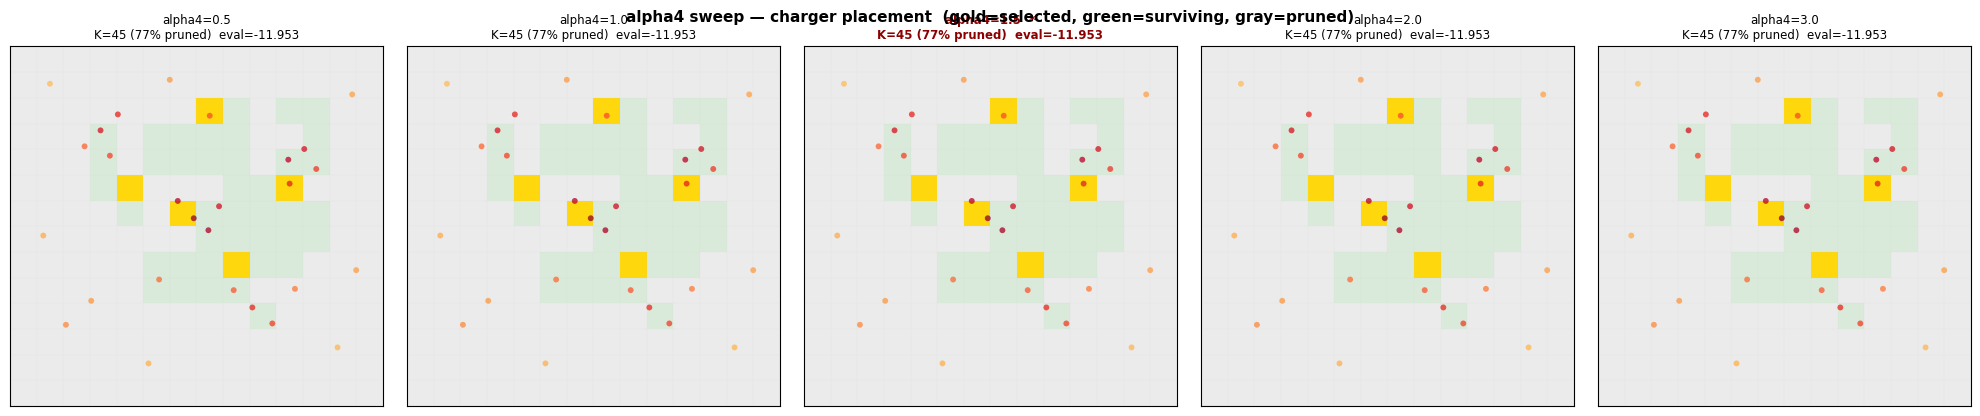

  qubo_alpha4.png + qubo_alpha4_solutions.png


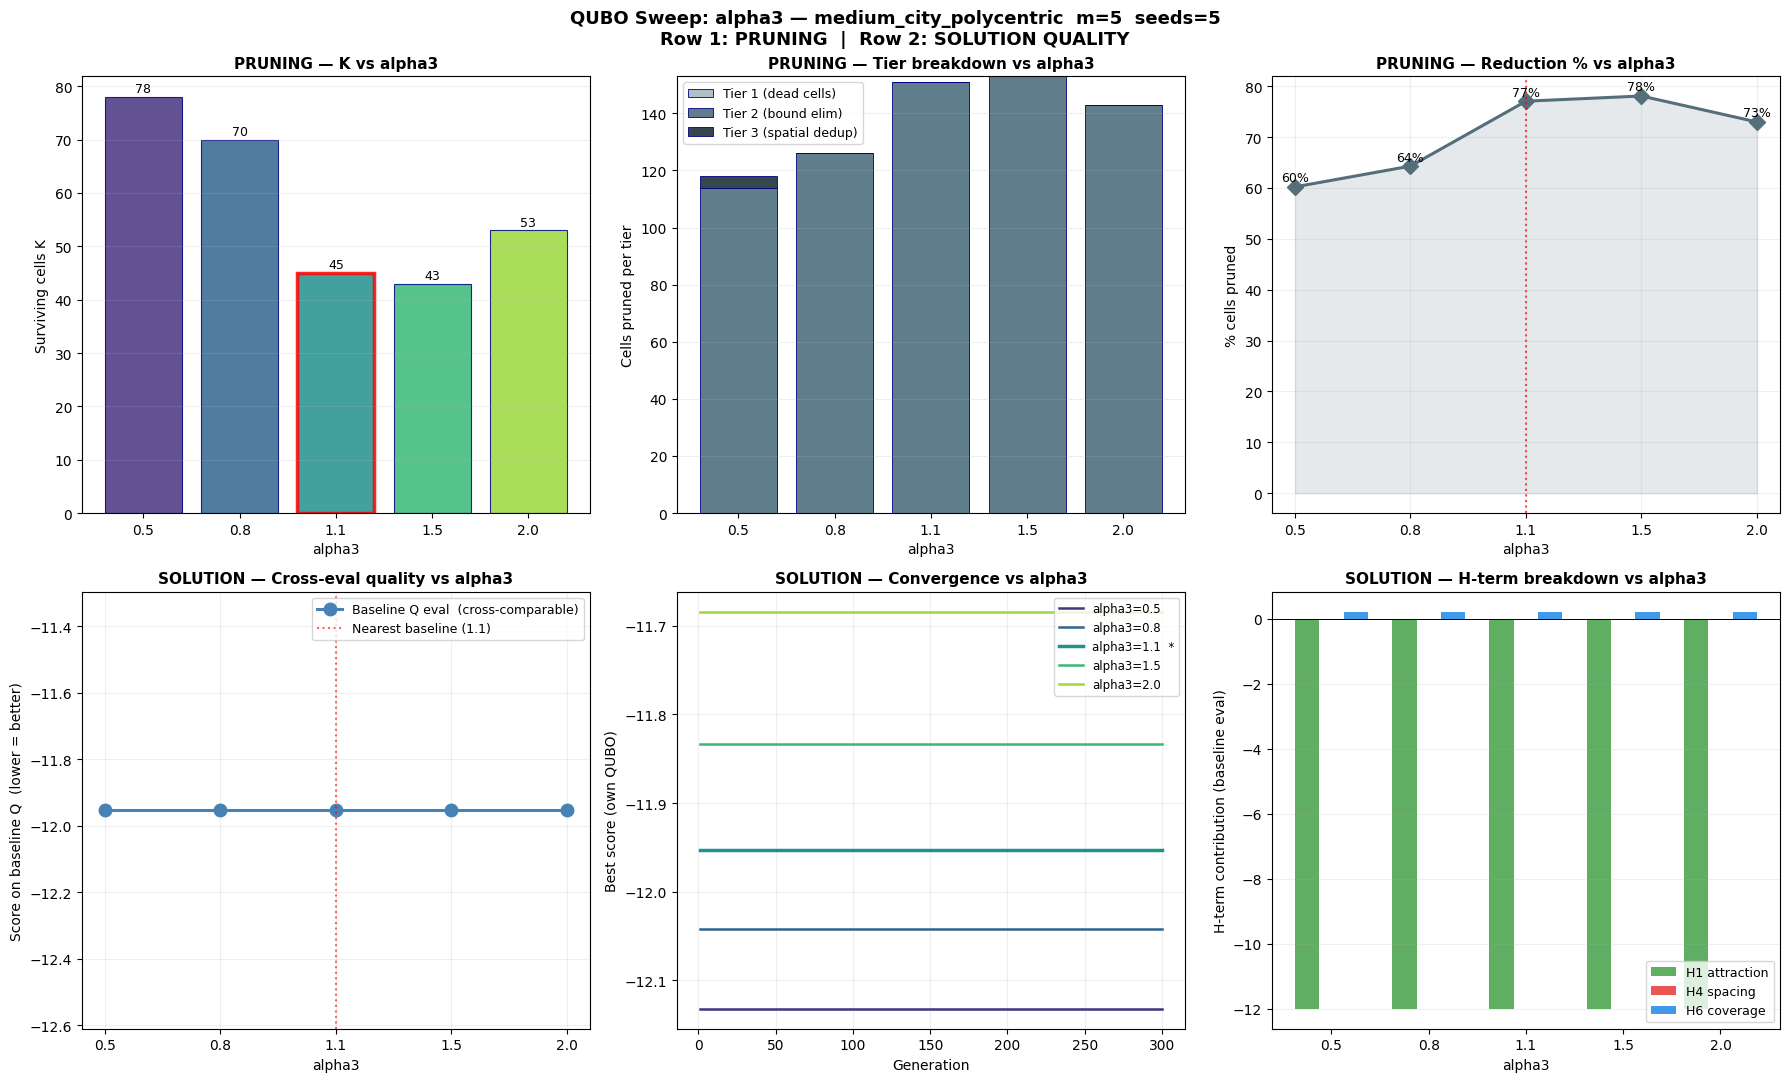

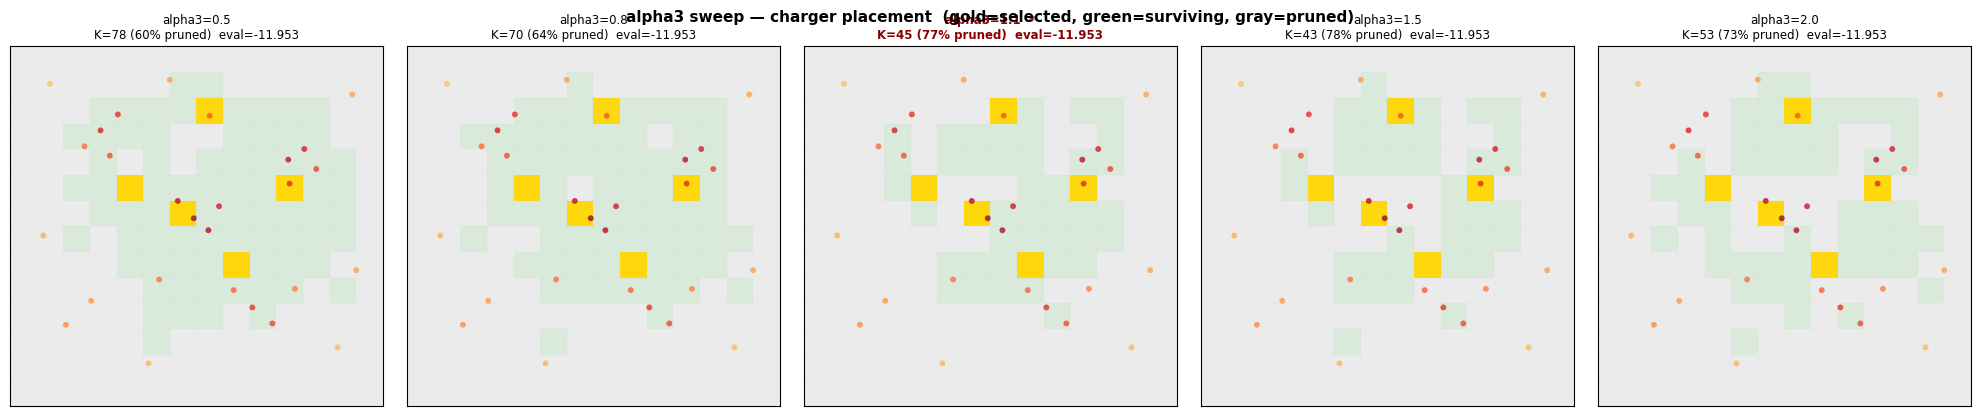

  qubo_alpha3.png + qubo_alpha3_solutions.png


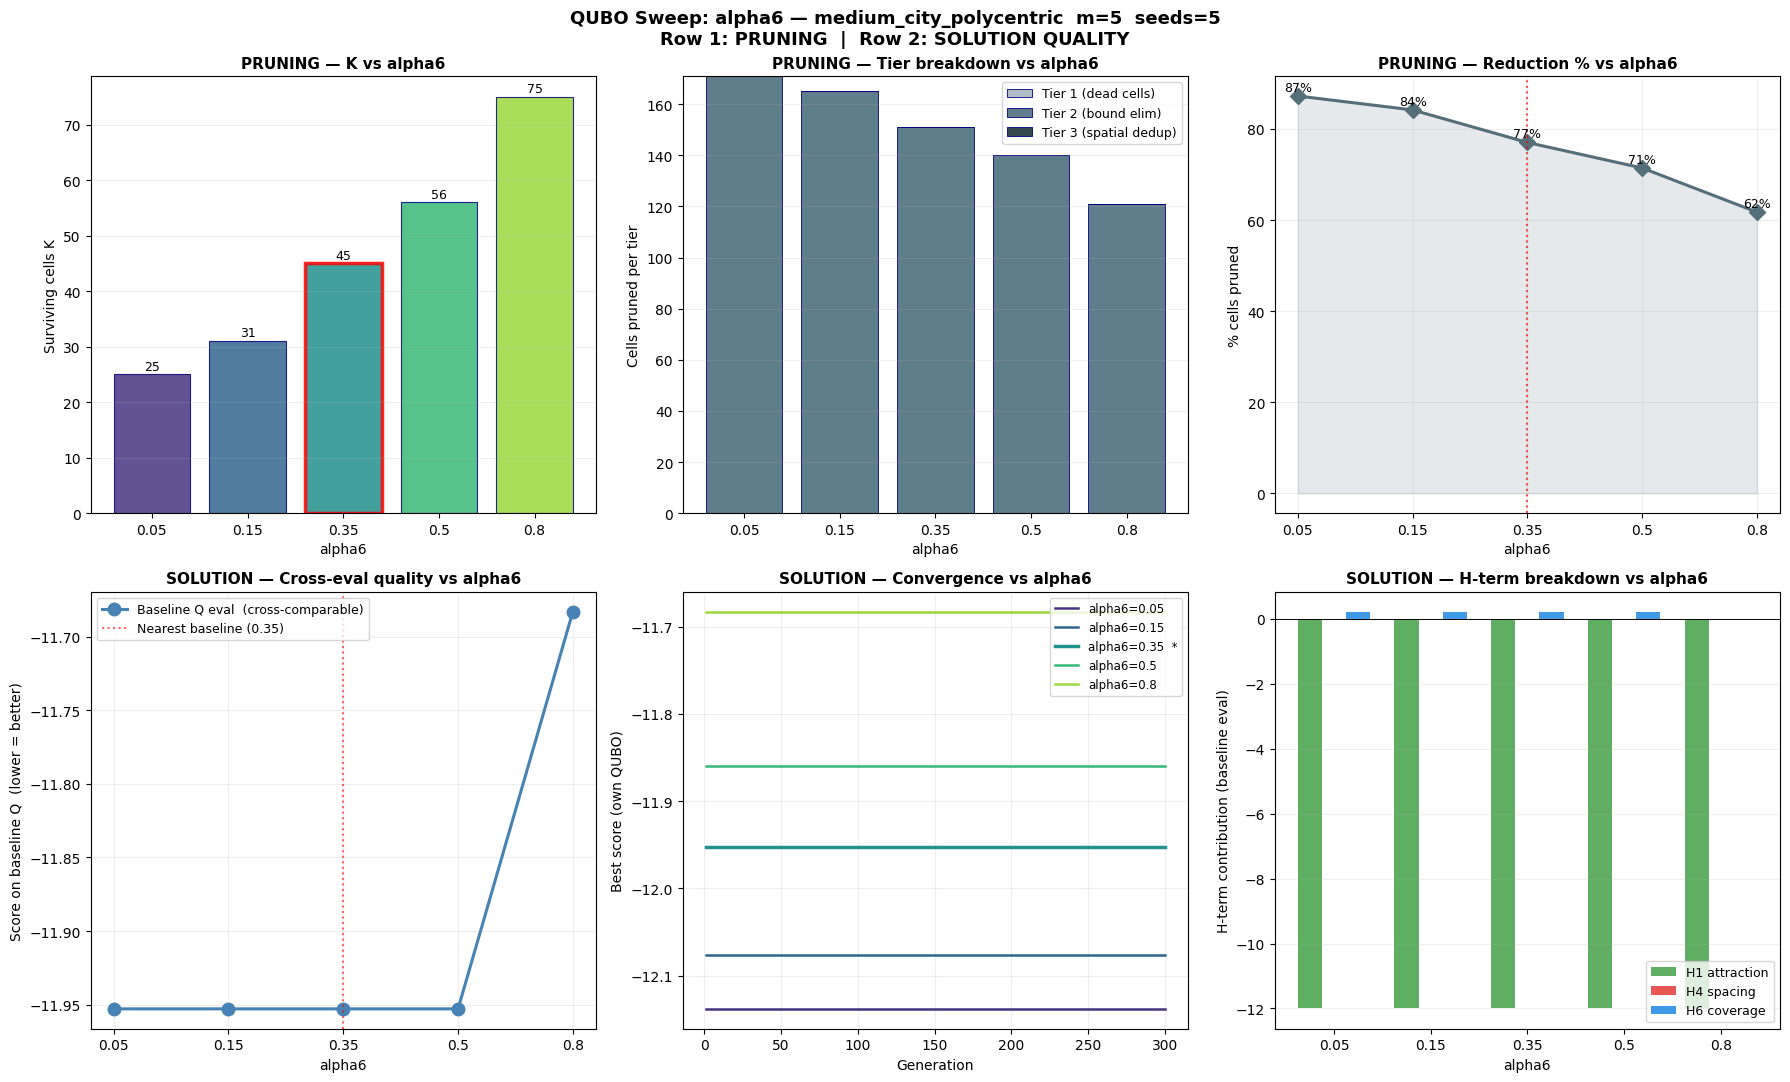

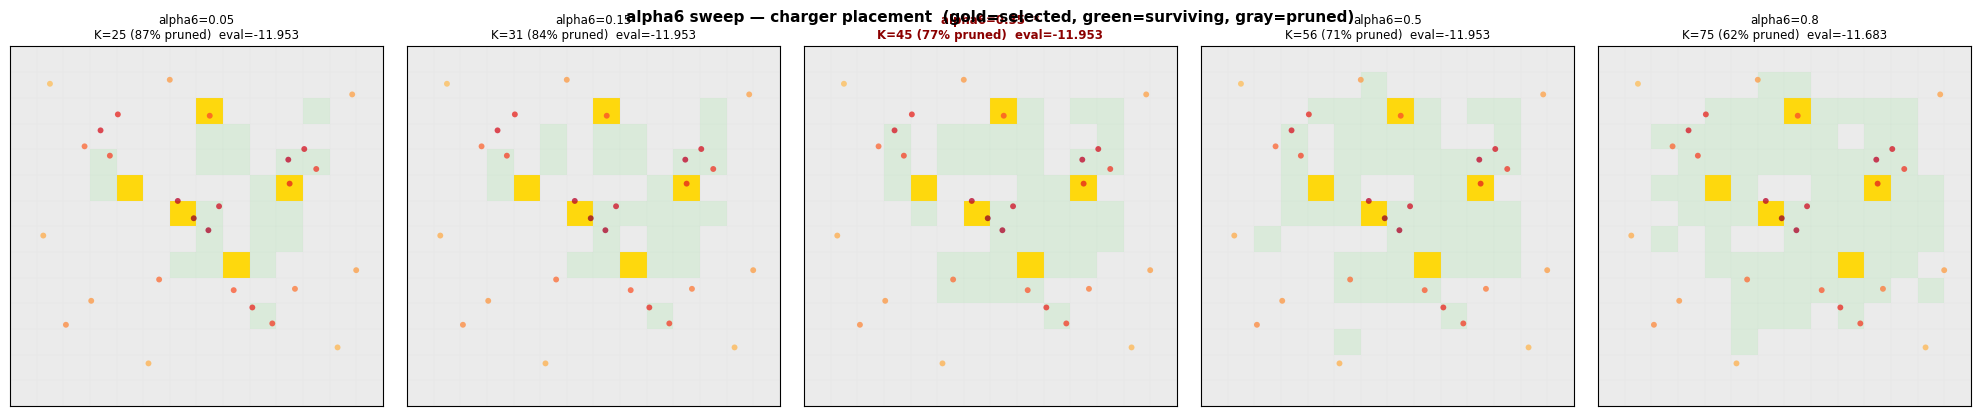

  qubo_alpha6.png + qubo_alpha6_solutions.png


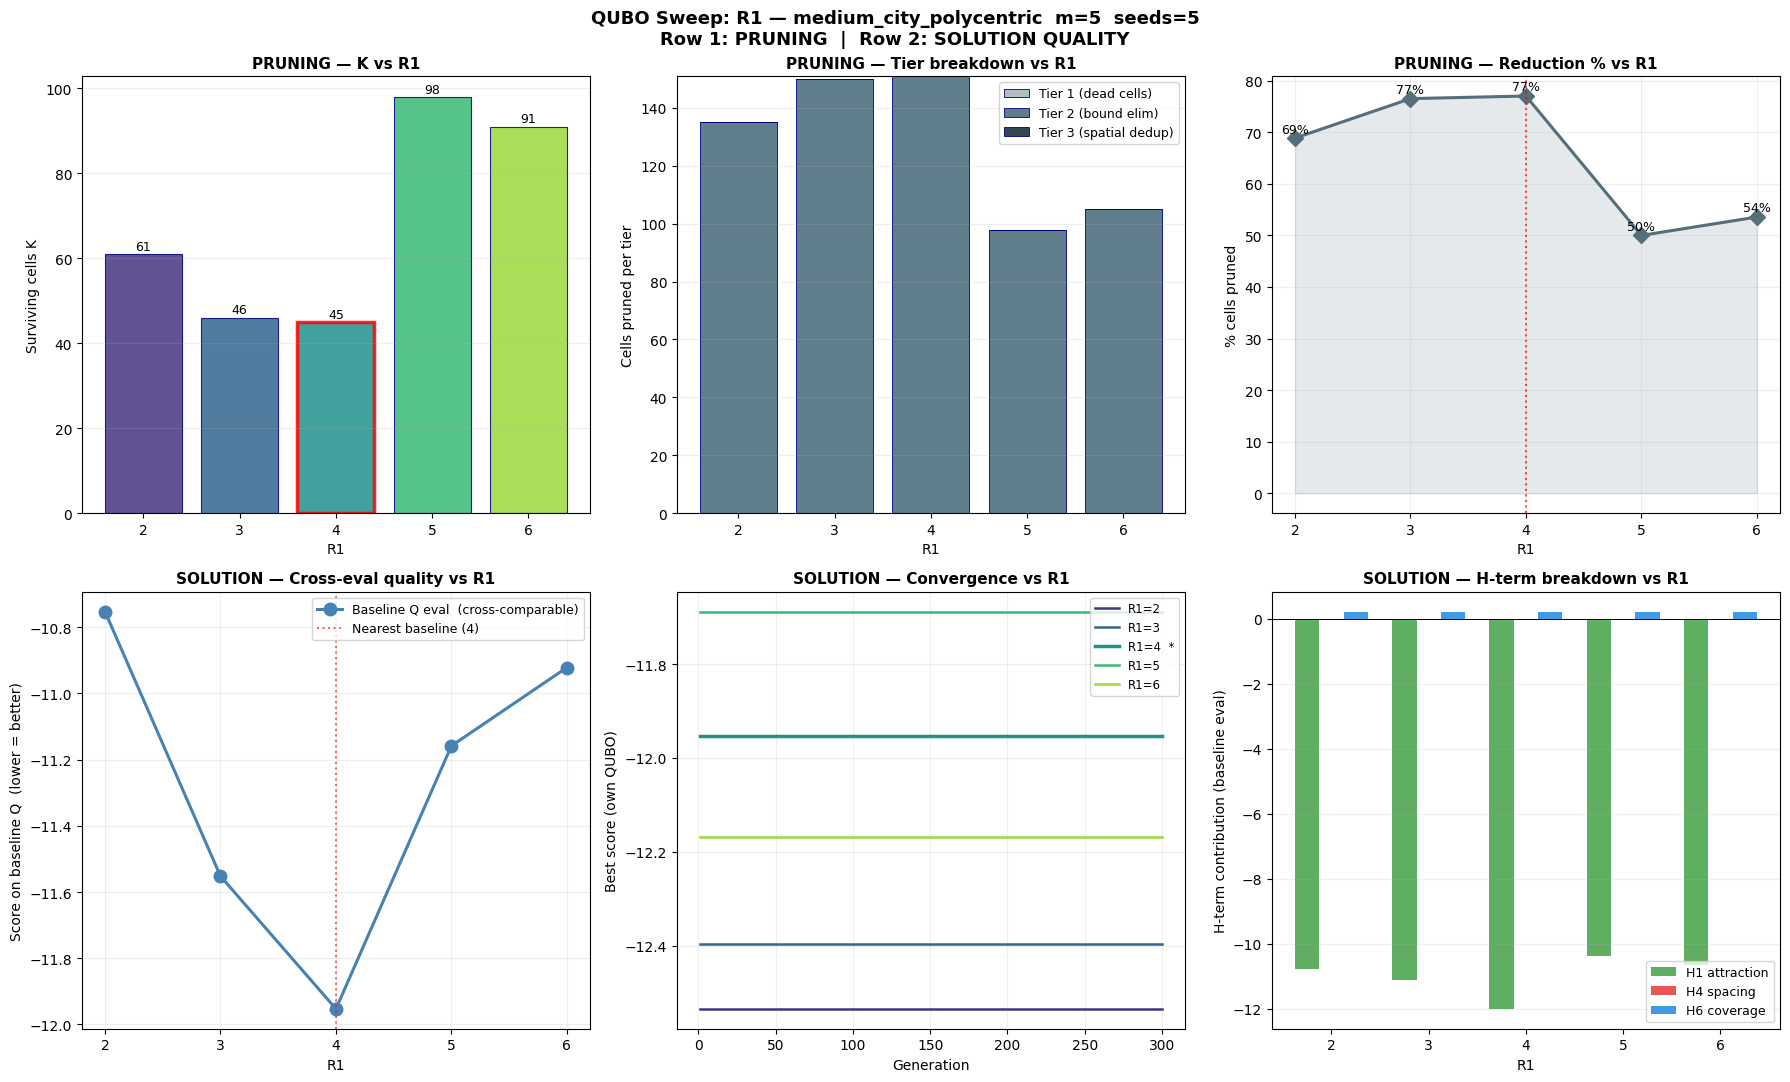

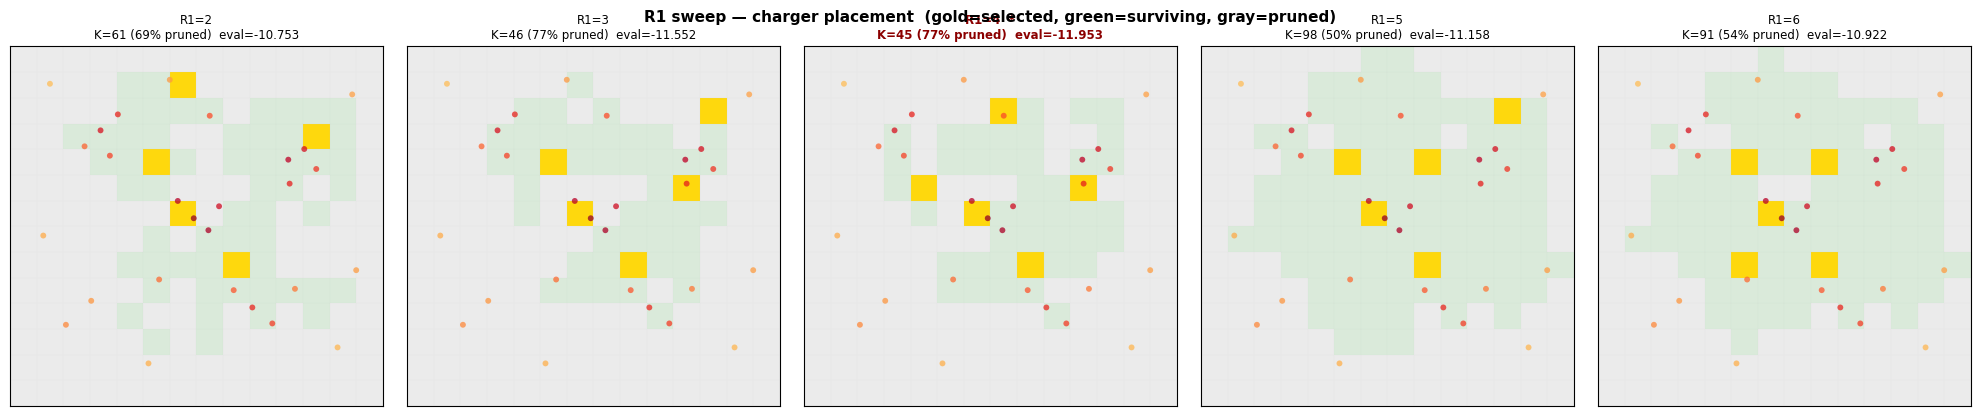

  qubo_R1.png + qubo_R1_solutions.png


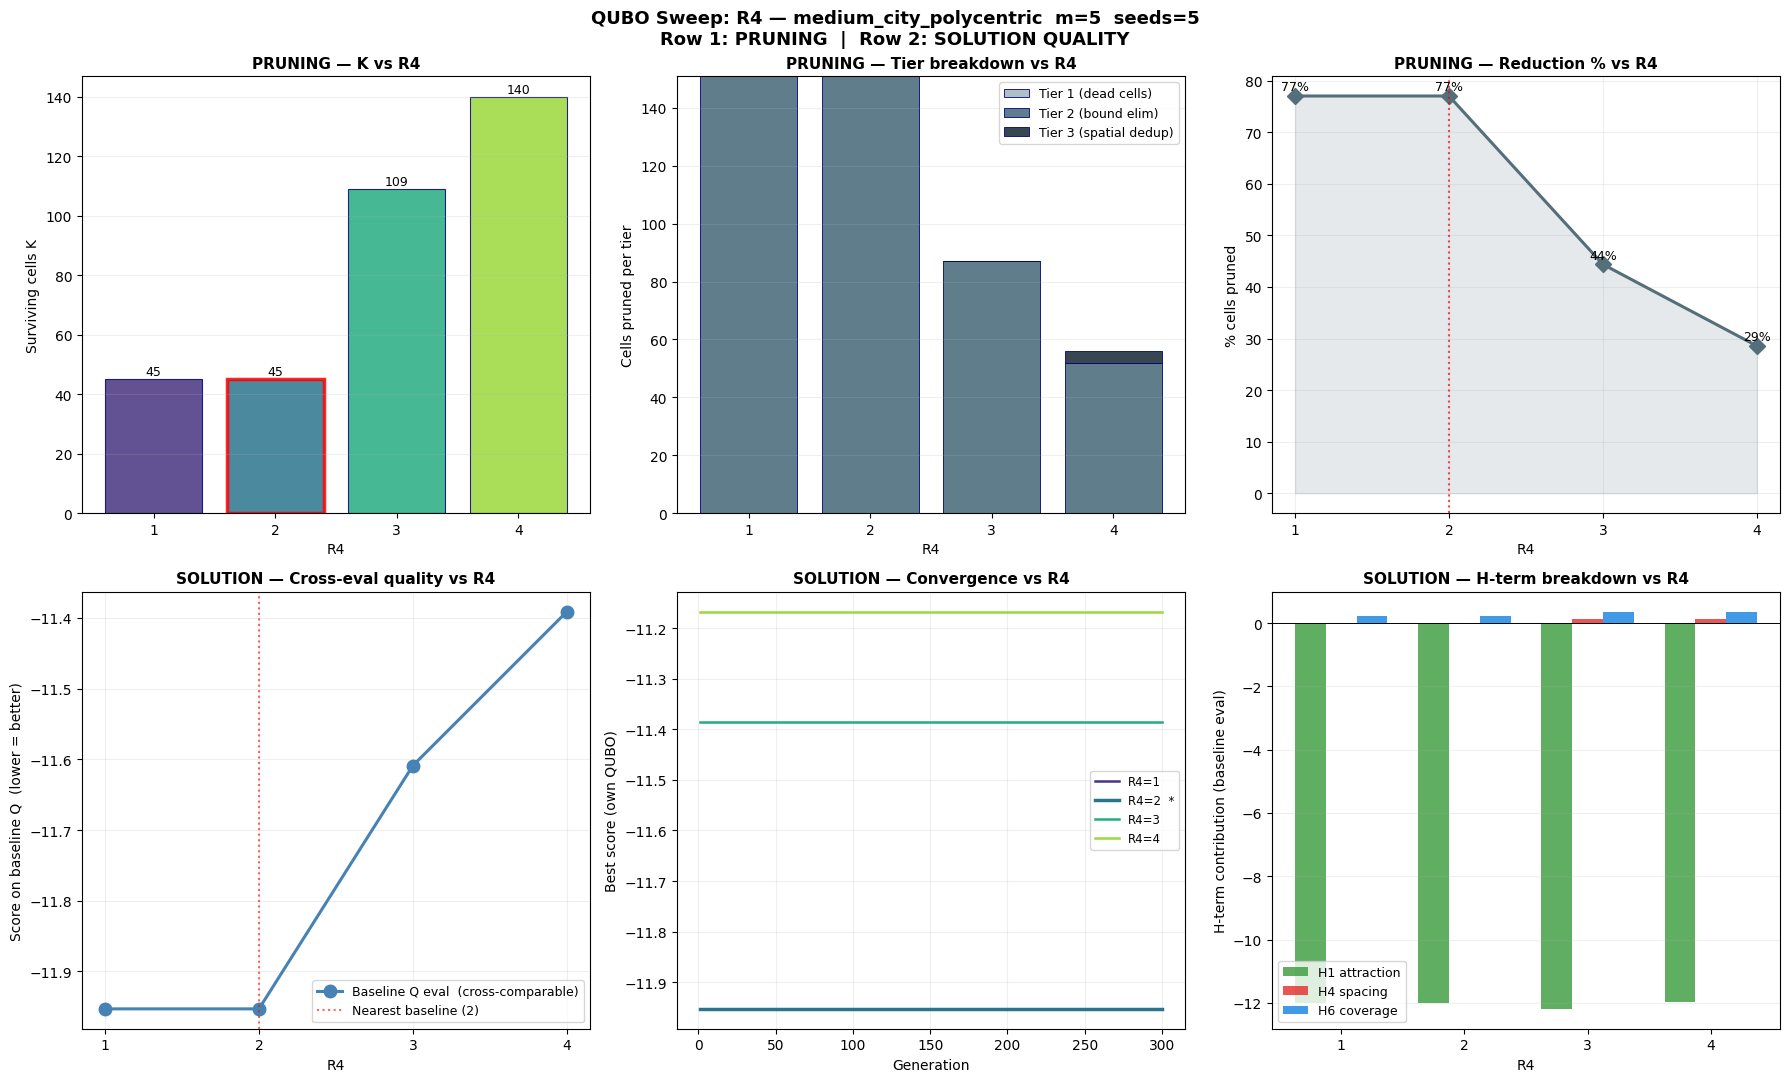

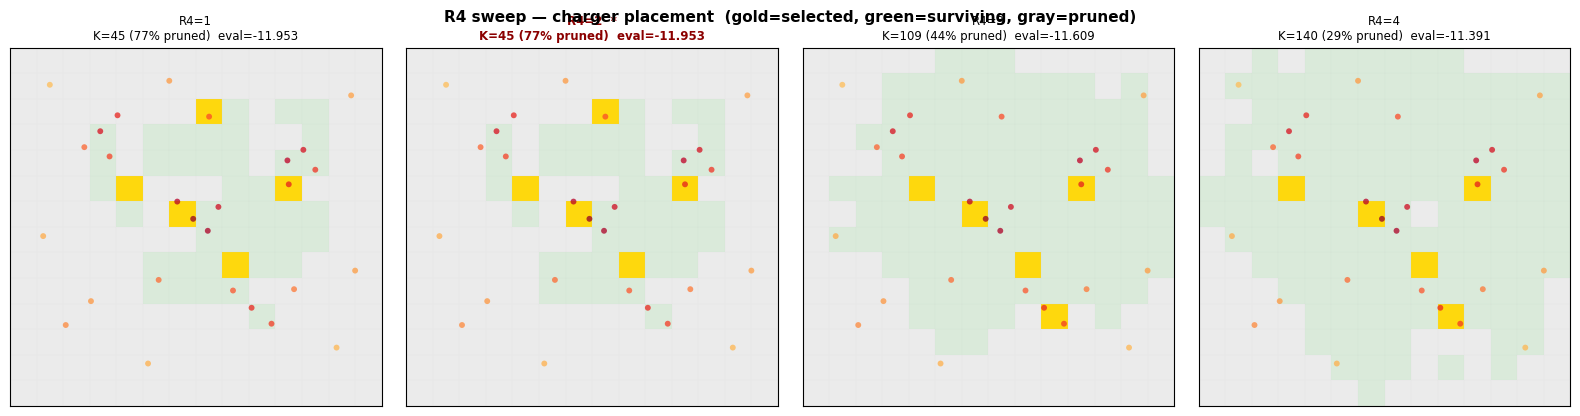

  qubo_R4.png + qubo_R4_solutions.png


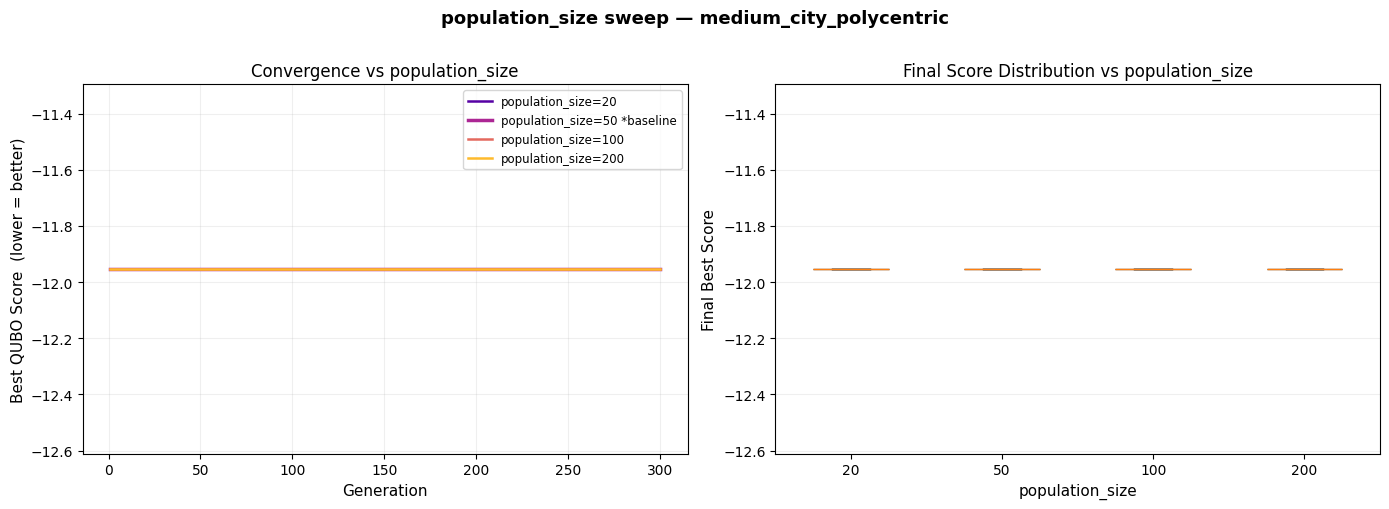

  ga_population_size.png


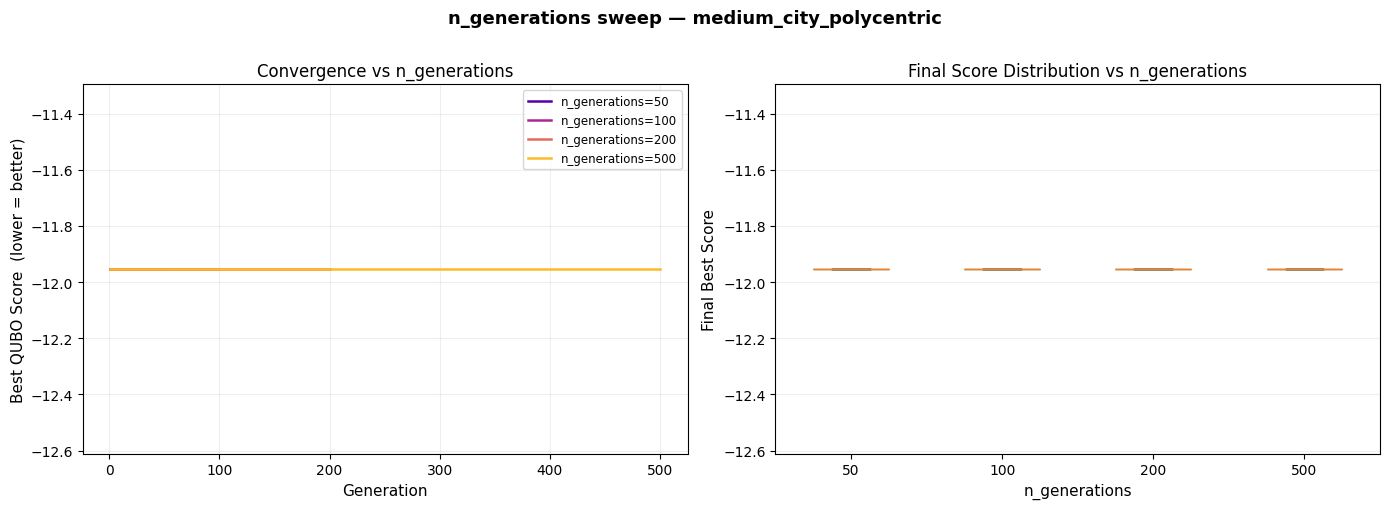

  ga_n_generations.png


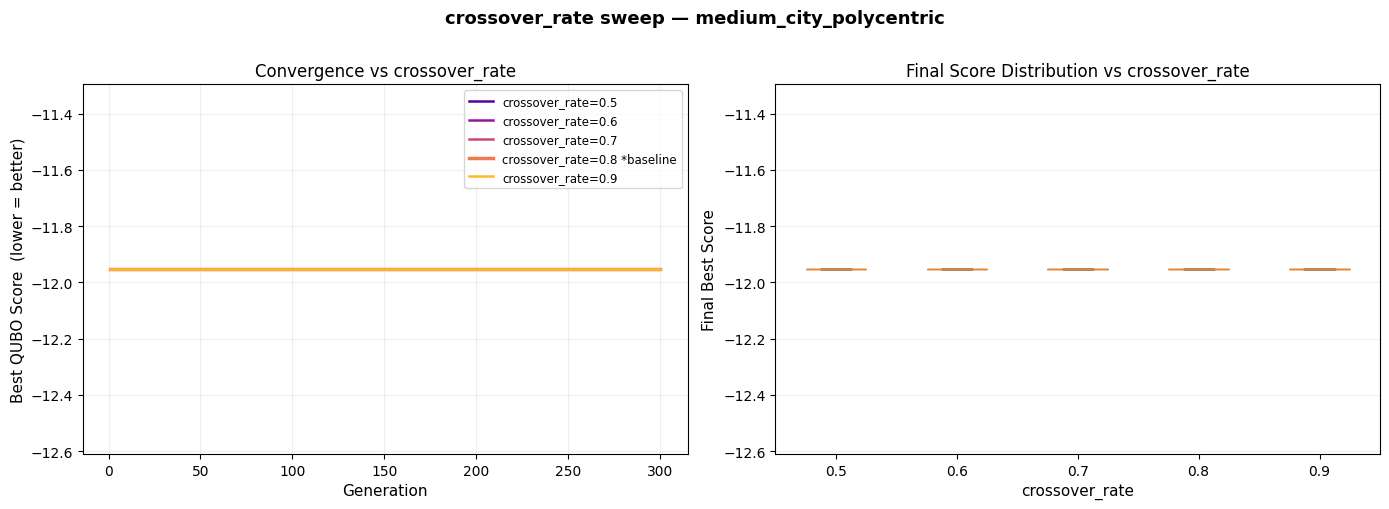

  ga_crossover_rate.png


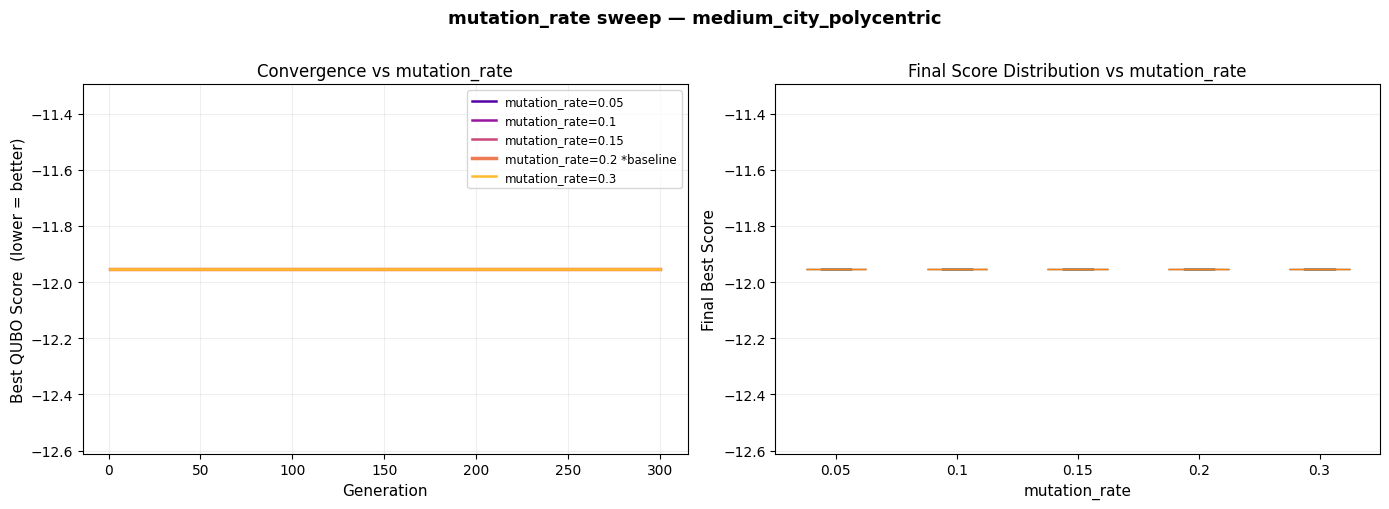

  ga_mutation_rate.png


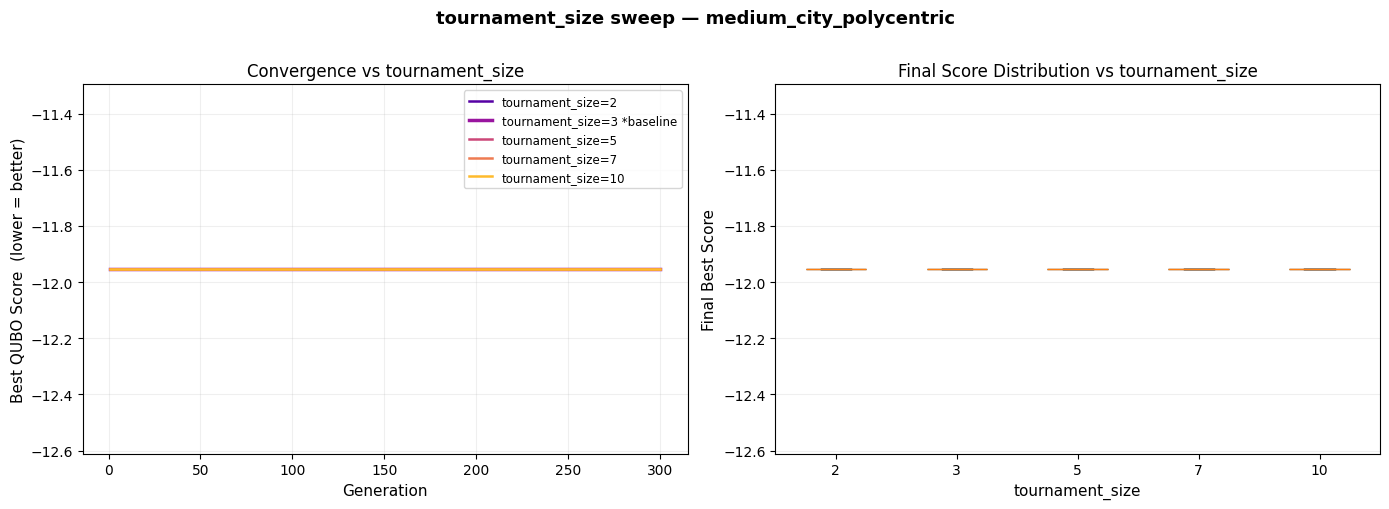

  ga_tournament_size.png
  ga_seed_mode.png
  pruning_effect.png
  best_solution.png
  summary.json

All results → /Users/abhimuvva/Documents/Proj_HGQA/results/classical_tuning/run_20260528_115540/medium_city_polycentric


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# Save results from interactive run
# Path: results/classical_tuning/run_YYYYMMDD_HHMMSS/{dataset_name}/
# ─────────────────────────────────────────────────────────────────────────────

_proj_root_r = _Path.cwd().parent
_ts          = datetime.now().strftime('%Y%m%d_%H%M%S')
_ds_name     = data['dataset_name']          # e.g. 'medium_city_polycentric'
_run_dir     = (_proj_root_r / 'results'
                / 'classical_tuning'
                / f'run_{_ts}'
                / _ds_name)
_run_dir.mkdir(parents=True, exist_ok=True)
print(f'Saving to: {_run_dir}')

# ── QUBO sweep figures ────────────────────────────────────────────────────────
for pname, sweep_res in ALL_QUBO_SWEEP_RESULTS.items():
    bval = _BASE_PARAMS[pname]
    _fig_q = plot_qubo_sweep(sweep_res, pname, bval)
    _fig_q.savefig(_run_dir / f'qubo_{pname}.png', dpi=150, bbox_inches='tight')
    plt.close(_fig_q)
    _fig_qs = plot_solution_comparison(sweep_res, pname, bval)
    _fig_qs.savefig(_run_dir / f'qubo_{pname}_solutions.png', dpi=150, bbox_inches='tight')
    plt.close(_fig_qs)
    print(f'  qubo_{pname}.png + qubo_{pname}_solutions.png')

# ── GA sweep figures ──────────────────────────────────────────────────────────
for param_name, sweep_res in ALL_SWEEP_RESULTS.items():
    if param_name == 'seed_mode':
        continue
    fig_saved = plot_sweep(
        sweep_res, param_name, BASELINE.get(param_name),
        fig_title=f'{param_name} sweep — {_ds_name}',
        save_path=str(_run_dir / f'ga_{param_name}.png'),
    )
    plt.close(fig_saved)
    print(f'  ga_{param_name}.png')

if 'seed_mode' in ALL_SWEEP_RESULTS:
    _sm = ALL_SWEEP_RESULTS['seed_mode']
    _fig_sm, _axes_sm = plt.subplots(1, 2, figsize=(14, 5))
    _mc = {'random': 'tomato', 'greedy': 'seagreen'}
    for _mode in ['random', 'greedy']:
        if _mode not in _sm: continue
        _col    = _mc[_mode]
        _curves = [rr['convergence'] for rr in _sm[_mode]]
        _ml     = max(len(c) for c in _curves)
        _pad    = np.array([c + [c[-1]] * (_ml - len(c)) for c in _curves])
        _mean   = _pad.mean(axis=0); _std = _pad.std(axis=0); _gens = np.arange(1, _ml + 1)
        _axes_sm[0].plot(_gens, _mean, color=_col, linewidth=2.5, label=_mode)
        _axes_sm[0].fill_between(_gens, _mean - _std, _mean + _std, color=_col, alpha=0.15)
        _z = min(50, _ml)
        _axes_sm[1].plot(np.arange(1, _z+1), _mean[:_z], color=_col, linewidth=2.5, label=_mode)
        _axes_sm[1].fill_between(np.arange(1, _z+1), _mean[:_z]-_std[:_z], _mean[:_z]+_std[:_z],
                                  color=_col, alpha=0.15)
    for _axi, _ttl in zip(_axes_sm, ['Full convergence', 'Early gens (first 50)']):
        _axi.set_xlabel('Generation'); _axi.set_ylabel('Best QUBO Score')
        _axi.set_title(_ttl); _axi.legend(); _axi.grid(True, alpha=0.2)
    _fig_sm.suptitle(f'Seed Mode — {_ds_name}', fontsize=13, fontweight='bold')
    _fig_sm.tight_layout()
    _fig_sm.savefig(_run_dir / 'ga_seed_mode.png', dpi=150, bbox_inches='tight')
    plt.close(_fig_sm)
    print('  ga_seed_mode.png')

# ── Pruning effect figure ──────────────────────────────────────────────────────
_fig_pe, _axes_pe = plt.subplots(1, 3, figsize=(18, 5))
for _label, _runs, _color, _ls in [
    (f'Full (K={N_QUBITS})', runs_full,   'tomato',   '--'),
    (f'Pruned (K={K})',      runs_pruned, 'steelblue', '-'),
]:
    _curves = [rr['convergence'] for rr in _runs]
    _ml  = max(len(c) for c in _curves)
    _pad = np.array([c + [c[-1]] * (_ml - len(c)) for c in _curves])
    _mean = _pad.mean(axis=0); _std = _pad.std(axis=0); _gens = np.arange(1, _ml+1)
    _axes_pe[0].plot(_gens, _mean, color=_color, linewidth=2.5, linestyle=_ls, label=_label)
    _axes_pe[0].fill_between(_gens, _mean - _std, _mean + _std, color=_color, alpha=0.15)
_axes_pe[0].set_xlabel('Generation'); _axes_pe[0].set_ylabel('Score (lower=better)')
_axes_pe[0].set_title('Convergence: Full vs Pruned'); _axes_pe[0].legend(); _axes_pe[0].grid(True, alpha=0.2)
_bp1 = _axes_pe[1].boxplot(
    [[rr['best_score'] for rr in runs_full], [rr['best_score'] for rr in runs_pruned]],
    tick_labels=[f'Full\n(K={N_QUBITS})', f'Pruned\n(K={K})'], patch_artist=True, widths=0.5)
_bp1['boxes'][0].set_facecolor('tomato');   _bp1['boxes'][0].set_alpha(0.7)
_bp1['boxes'][1].set_facecolor('steelblue'); _bp1['boxes'][1].set_alpha(0.7)
_axes_pe[1].set_ylabel('Final Best Score'); _axes_pe[1].set_title('Score Distribution'); _axes_pe[1].grid(True, alpha=0.2, axis='y')
_bp2 = _axes_pe[2].boxplot(
    [[rr['runtime_sec'] for rr in runs_full], [rr['runtime_sec'] for rr in runs_pruned]],
    tick_labels=[f'Full\n(K={N_QUBITS})', f'Pruned\n(K={K})'], patch_artist=True, widths=0.5)
_bp2['boxes'][0].set_facecolor('tomato');   _bp2['boxes'][0].set_alpha(0.7)
_bp2['boxes'][1].set_facecolor('steelblue'); _bp2['boxes'][1].set_alpha(0.7)
_axes_pe[2].set_ylabel('Runtime (s)'); _axes_pe[2].set_title('Runtime Comparison'); _axes_pe[2].grid(True, alpha=0.2, axis='y')
_fig_pe.suptitle(f'Pruning Effect — {_ds_name}  m={M}', fontsize=13, fontweight='bold')
_fig_pe.tight_layout()
_fig_pe.savefig(_run_dir / 'pruning_effect.png', dpi=150, bbox_inches='tight')
plt.close(_fig_pe)
print('  pruning_effect.png')

# ── Best solution grid ─────────────────────────────────────────────────────────
_fig_sol2, _ax2 = plt.subplots(figsize=(11, 9))
_ax2.set_facecolor('#f8f8f8')
for _i in range(plot_deets['num_cols'] + 1):
    _ax2.axvline(X_MIN + _i * cell_w, color='gray', linewidth=0.15)
for _j in range(plot_deets['num_rows'] + 1):
    _ax2.axhline(Y_MIN + _j * cell_h, color='gray', linewidth=0.15)
for _gid, _info in grid_details.items():
    _cx, _cy = _info['x_start'], _info['y_start']
    if _gid in best_cells_set:
        _c2, _a2, _e2, _w2 = 'gold', 0.95, 'darkorange', 1.2
    elif _gid in surv_set:
        _c2, _a2, _e2, _w2 = '#c8e6c9', 0.65, 'lightgray', 0.15
    else:
        _c2, _a2, _e2, _w2 = '#eeeeee', 0.30, 'lightgray', 0.10
    _ax2.add_patch(plt.Rectangle((_cx, _cy), cell_w, cell_h,
                                 facecolor=_c2, alpha=_a2, edgecolor=_e2, linewidth=_w2))
    if _gid in best_cells_set:
        _ax2.text(_cx + cell_w/2, _cy + cell_h/2, str(_gid),
                  ha='center', va='center', fontsize=7.5, fontweight='bold', color='darkred')
if points_of_interest:
    _ax2.scatter([p[0] for p in points_of_interest], [p[1] for p in points_of_interest],
                 c=[p[2] for p in points_of_interest], cmap='YlOrRd',
                 edgecolors='green', linewidths=1, s=60, vmin=0, vmax=1, zorder=5)
if existing_charging_points:
    _ax2.scatter(*zip(*existing_charging_points), color='blue', marker='s',
                 s=60, zorder=5, edgecolors='darkblue', linewidths=0.8)
if gas_stations:
    _ax2.scatter(*zip(*gas_stations), color='orange', marker='^',
                 s=60, zorder=5, edgecolors='darkorange', linewidths=0.8)
_ax2.legend(handles=[
    mpatches.Patch(color='gold',    label=f'Best GA — score={best_run["best_score"]:.4f}'),
    mpatches.Patch(color='#c8e6c9', label=f'Surviving (K={K})'),
    mpatches.Patch(color='#eeeeee', label='Pruned'),
], loc='upper right', fontsize=10)
_ax2.set_xlim(X_MIN, X_MAX); _ax2.set_ylim(Y_MIN, Y_MAX); _ax2.set_aspect('equal')
_ax2.set_title(f'{_ds_name} — Best GA  score={best_run["best_score"]:.4f}',
               fontsize=13, fontweight='bold')
_fig_sol2.tight_layout()
_fig_sol2.savefig(_run_dir / 'best_solution.png', dpi=150, bbox_inches='tight')
plt.close(_fig_sol2)
print('  best_solution.png')

# ── JSON summary ───────────────────────────────────────────────────────────────
def _run_to_dict(rr):
    return {'best_score': rr['best_score'], 'best_cells': rr['best_solution'],
            'runtime_sec': round(rr['runtime_sec'], 4), 'n_generations': rr['n_generations_run'],
            'conv_gen': _conv_gen(rr['convergence'])}

def _ga_sweep_to_dict(sweep_res):
    out = {}
    for val, runs in sweep_res.items():
        scores = [rr['best_score'] for rr in runs]
        times  = [rr['runtime_sec'] for rr in runs]
        cgens  = [_conv_gen(rr['convergence']) for rr in runs]
        out[str(val)] = {
            'mean_score': round(float(np.mean(scores)), 6),
            'std_score':  round(float(np.std(scores)), 6),
            'mean_time':  round(float(np.mean(times)), 4),
            'mean_conv_gen': round(float(np.mean(cgens)), 1),
        }
    return out

def _qubo_sweep_to_dict(sweep_res):
    out = {}
    for val, d in sweep_res.items():
        out[str(val)] = {
            'K':             d['K'],
            'best_score':    round(d['best_score'], 6),
            'mean_score':    round(d['mean_score'], 6),
            'std_score':     round(d['std_score'], 6),
            'baseline_eval': round(d['baseline_eval'], 6),
            'H1':            round(d['terms']['H1'], 6),
            'H4':            round(d['terms']['H4'], 6),
            'H6':            round(d['terms']['H6'], 6),
            'best_cells':    d['best_cells'],
            'mean_time':     round(d['mean_time'], 4),
        }
    return out

_summary = {
    'timestamp':    datetime.now().isoformat(timespec='seconds'),
    'run_id':       f'run_{_ts}',
    'dataset':      _ds_name,
    'N':            N_QUBITS,
    'K':            K,
    'm':            M,
    'baseline_qubo_params': {k: v for k, v in _BASE_PARAMS.items()},
    'baseline_ga_params':   BASELINE,
    'n_seeds':      N_SEEDS,
    'pruning': {
        'tier1_pruned':  prune_report['tier1']['pruned'],
        'tier2_pruned':  prune_report['tier2']['pruned'],
        'tier3_pruned':  prune_report['tier3']['pruned'],
        'reduction_pct': round(100*(1-K/N_QUBITS), 1),
    },
    'qubo_sweeps':    {p: _qubo_sweep_to_dict(r) for p, r in ALL_QUBO_SWEEP_RESULTS.items()},
    'ga_sweeps':      {p: _ga_sweep_to_dict(r)   for p, r in ALL_SWEEP_RESULTS.items()},
    'pruning_effect': {
        'full':   {'K': N_QUBITS,
                   'mean_score': round(float(np.mean([rr['best_score'] for rr in runs_full])), 6),
                   'mean_time':  round(float(np.mean([rr['runtime_sec'] for rr in runs_full])), 4)},
        'pruned': {'K': K,
                   'mean_score': round(float(np.mean([rr['best_score'] for rr in runs_pruned])), 6),
                   'mean_time':  round(float(np.mean([rr['runtime_sec'] for rr in runs_pruned])), 4)},
        'speedup': round(float(np.mean([rr['runtime_sec'] for rr in runs_full]) /
                               np.mean([rr['runtime_sec'] for rr in runs_pruned])), 2),
    },
    'best': {'score': best_run['best_score'], 'cells': best_run['best_solution']},
}
(_run_dir / 'summary.json').write_text(_json.dumps(_summary, indent=2))
print('  summary.json')
print(f'\nAll results → {_run_dir}')


---
## Section 5 — Batch Runner: All Datasets

Runs the full pipeline (QUBO sweeps + GA sweeps + pruning effect) on every dataset
in `DATASETS`, saves everything under a single timestamped folder:

```
results/mk08_classical_tuning/
  run_YYYYMMDD_HHMMSS/
    medium_city_polycentric/
      qubo_alpha1.png
      qubo_alpha4.png
      qubo_alpha3.png
      qubo_alpha6.png
      qubo_R1.png
      qubo_R4.png
      ga_population_size.png
      ga_n_generations.png
      ga_crossover_rate.png
      ga_mutation_rate.png
      ga_tournament_size.png
      ga_seed_mode.png
      pruning_effect.png
      best_solution.png
      summary.json
    medium_city_corridor/
      ...
    ...  (one subfolder per dataset)
  cross_dataset_summary.json
```

**To add more datasets**, edit `DATASETS` in `mk08-config` and re-run from there.


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Batch helper: run full analysis for one dataset, save to run_dir/ds_name/
# ─────────────────────────────────────────────────────────────────────────────

def run_one_dataset(ds_name, ds_file, n_qubits, run_dir):
    """
    Full pipeline + QUBO sweeps + GA sweeps + pruning effect for one dataset.
    All figures saved to run_dir/ds_name/. Nothing shown interactively.
    Returns a summary dict.
    """
    _sep = '=' * 70
    print(f'\n{_sep}')
    print(f'  {ds_name}  ({n_qubits}q)')
    print(_sep)
    t0 = time.perf_counter()

    dst = _Path(run_dir) / ds_name
    dst.mkdir(parents=True, exist_ok=True)

    # ── Pipeline ──────────────────────────────────────────────────────────────
    _data = load_dataset(ds_file)
    _grid, _pdeets = divide_graph_into_parts(
        x_min=_data['x_min'], x_max=_data['x_max'],
        y_min=_data['y_min'], y_max=_data['y_max'],
        num_qubits=n_qubits,
        points_of_interest=_data['pois'],
        existing_chargers=_data['existing_chargers'],
        gas_stations=_data['gas_stations'],
    )
    _cw = calculate_cell_weights(_grid, scale_factor=SCALE_FACTOR, min_weight=MIN_WEIGHT)
    _N  = _pdeets['total_cells']
    _sg = suggest_parameters(_grid, _cw, _pdeets, m=_data['m'])
    _M  = _data['m']
    _a  = _sg['alpha'];  _r = _sg['radii'];  _t = _sg['intra'];  _lv = _sg['lambda']

    _Qo, _, _diags = build_qubo(
        _grid, _cw, _pdeets, m=_M,
        alpha1=_a['a1'], alpha2=_a['a2'], alpha3=_a['a3'],
        alpha4=_a['a4'], alpha5=_a['a5'], alpha6=_a['a6'],
        beta=_t['beta'], gamma=_t['gamma'], delta=_t['delta'], epsilon=_t['epsilon'],
        lam=_lv, R1=_r['R1'], Rs=_r['Rs'], R3=_r['R3'], R4=_r['R4'], R6=_r['R6'],
    )
    _pf = {
        'alpha1': _a['a1'], 'alpha2': _a['a2'], 'alpha3': _a['a3'],
        'alpha4': _a['a4'], 'alpha5': _a['a5'], 'alpha6': _a['a6'],
        'beta': _t['beta'], 'gamma': _t['gamma'], 'delta': _t['delta'], 'epsilon': _t['epsilon'],
        'lam': _lv, 'R1': _r['R1'], 'Rs': _r['Rs'], 'R3': _r['R3'], 'R4': _r['R4'], 'R6': _r['R6'],
    }
    _pf, _nr = calibrate_alphas(_Qo, _pf, _diags, verbose=False)
    if _nr:
        _Qo, _, _ = build_qubo(_grid, _cw, _pdeets, m=_M, **_pf)

    _surv, _prep = prune_cells(_Qo, N=_N, m=_M, num_cols=_pdeets['num_cols'],
                                R4=_pf.get('R4', _r['R4']), tier3_keep=TIER3_KEEP, verbose=False)
    _K  = len(_surv)
    _Qp, _, _q2c = remap_qubo_for_qaoa(_Qo, _surv)
    _BP = dict(_pf)

    print(f'  Pipeline  N={_N}  K={_K}  M={_M}  |Q_obj|={len(_Qo)}  |Q_pruned|={len(_Qp)}')

    # ── Local helpers ──────────────────────────────────────────────────────────
    def _eq(Q, cells):
        cs = set(cells); s = 0.0
        for (i, j), v in Q.items():
            if i == j:
                if i in cs: s += v
            else:
                if i in cs and j in cs: s += v
        return s

    def _terms(cells):
        def _iso(**kw):
            Q_i, _, _ = build_qubo(_grid, _cw, _pdeets, m=_M, **{**_BP, **kw})
            return Q_i
        return {'H1': _eq(_iso(alpha2=0, alpha3=0, alpha4=0, alpha6=0), cells),
                'H4': _eq(_iso(alpha1=0, alpha2=0, alpha3=0, alpha6=0), cells),
                'H6': _eq(_iso(alpha1=0, alpha2=0, alpha3=0, alpha4=0), cells)}

    def _rar(override):
        p = {**_BP, **override}
        pr4 = override.get('R4', _BP.get('R4', _r['R4']))
        Qn, _, _ = build_qubo(_grid, _cw, _pdeets, m=_M, **p)
        sn, prn = prune_cells(Qn, N=_N, m=_M, num_cols=_pdeets['num_cols'],
                              R4=pr4, tier3_keep=TIER3_KEEP, verbose=False)
        if len(sn) < _M: return None
        Qpn, _, q2cn = remap_qubo_for_qaoa(Qn, sn)
        runs = [run_ga(Qpn, q2cn, K=len(sn), m=_M, **BASELINE, verbose=False, seed=s)
                for s in SEEDS]
        best = min(runs, key=lambda x: x['best_score'])
        return {'K': len(sn), 'surviving': sn, 'runs': runs,
                'tier1_pruned': prn['tier1']['pruned'],
                'tier2_pruned': prn['tier2']['pruned'],
                'tier3_pruned': prn['tier3']['pruned'],
                'best_cells': best['best_solution'], 'best_score': best['best_score'],
                'mean_score': float(np.mean([x['best_score'] for x in runs])),
                'std_score':  float(np.std([x['best_score']  for x in runs])),
                'baseline_eval': _eq(_Qo, best['best_solution']),
                'terms': _terms(best['best_solution']),
                'mean_time': float(np.mean([x['runtime_sec'] for x in runs]))}

    def _near(vals, tgt):
        return min(vals, key=lambda x: abs(float(x) - float(tgt)))

    def _conv_g(curve, tol=0.01):
        final = curve[-1]; denom = abs(final) if abs(final) > 1e-10 else 1.0
        for i, v in enumerate(curve):
            if abs(v-final)/denom <= tol: return i+1
        return len(curve)

    def _qubo_fig(sweep, pname, bval):
        vals  = sorted(sweep.keys())
        cmap  = plt.colormaps['viridis']
        cols  = [cmap(x) for x in np.linspace(0.15, 0.85, len(vals))]
        sv    = [str(v) for v in vals]
        nb_   = min(vals, key=lambda x: abs(float(x) - float(bval)))
        Ks    = [sweep[v]['K'] for v in vals]
        t1s   = [sweep[v].get('tier1_pruned', 0) for v in vals]
        t2s   = [sweep[v].get('tier2_pruned', 0) for v in vals]
        t3s   = [sweep[v].get('tier3_pruned', 0) for v in vals]
        pcts  = [100 * (1 - k / _N) for k in Ks]
        evs   = [sweep[v]['baseline_eval'] for v in vals]
        h1    = [sweep[v]['terms']['H1'] for v in vals]
        h4    = [sweep[v]['terms']['H4'] for v in vals]
        h6    = [sweep[v]['terms']['H6'] for v in vals]

        fig, axes = plt.subplots(2, 3, figsize=(18, 11))
        (ak, at, ap), (ae, ac, ah) = axes

        # [0,0] K bar
        brs = ak.bar(sv, Ks, color=cols, edgecolor='navy', lw=0.8, alpha=0.85)
        if nb_ in vals: brs[vals.index(nb_)].set_edgecolor('red'); brs[vals.index(nb_)].set_linewidth(2.5)
        [ak.text(i, v+0.3, str(v), ha='center', va='bottom', fontsize=9) for i, v in enumerate(Ks)]
        ak.set(xlabel=pname, ylabel='Surviving cells K', title=f'PRUNING — K vs {pname}'); ak.grid(True, alpha=0.2, axis='y')

        # [0,1] Tier stacked bar
        xi = np.arange(len(vals))
        at.bar(xi, t1s, label='Tier 1 (dead cells)', color='#B0BEC5', edgecolor='navy', lw=0.6)
        at.bar(xi, t2s, bottom=t1s, label='Tier 2 (bound elim)', color='#607D8B', edgecolor='navy', lw=0.6)
        t12 = [a+b for a, b in zip(t1s, t2s)]
        at.bar(xi, t3s, bottom=t12, label='Tier 3 (spatial dedup)', color='#37474F', edgecolor='navy', lw=0.6)
        at.set_xticks(xi); at.set_xticklabels(sv)
        at.set(xlabel=pname, ylabel='Cells pruned per tier', title=f'PRUNING — Tier breakdown vs {pname}')
        at.legend(fontsize=9); at.grid(True, alpha=0.2, axis='y')

        # [0,2] % reduction
        ap.plot(sv, pcts, 'D-', color='#546E7A', lw=2.2, ms=8)
        ap.fill_between(range(len(vals)), pcts, alpha=0.15, color='#546E7A')
        [ap.text(i, p+0.5, f'{p:.0f}%', ha='center', va='bottom', fontsize=9) for i, p in enumerate(pcts)]
        if nb_ in vals: ap.axvline(vals.index(nb_), color='red', ls=':', lw=1.5, alpha=0.7)
        ap.set(xlabel=pname, ylabel='% cells pruned', title=f'PRUNING — Reduction % vs {pname}'); ap.grid(True, alpha=0.2)

        # [1,0] Baseline cross-eval
        ae.plot(sv, evs, 'o-', color='steelblue', lw=2.2, ms=9, label='Baseline Q eval')
        if nb_ in vals: ae.axvline(vals.index(nb_), color='red', ls=':', lw=1.5, alpha=0.6, label=f'Nearest baseline ({nb_})')
        ae.set(xlabel=pname, ylabel='Score on baseline Q (lower=better)', title=f'SOLUTION — Cross-eval quality vs {pname}')
        ae.legend(fontsize=9); ae.grid(True, alpha=0.2)

        # [1,1] Convergence curves
        for val, col in zip(vals, cols):
            runs = sweep[val].get('runs', [])
            if not runs: continue
            curves = [r['convergence'] for r in runs]
            ml  = max(len(c) for c in curves)
            pad = np.array([c+[c[-1]]*(ml-len(c)) for c in curves])
            mn  = pad.mean(0); sd = pad.std(0); g = np.arange(1, ml+1)
            lbl = f'{pname}={val}' + ('  *' if val == nb_ else '')
            ac.plot(g, mn, color=col, lw=2.5 if val == nb_ else 1.8, label=lbl)
            ac.fill_between(g, mn-sd, mn+sd, color=col, alpha=0.12)
        ac.set(xlabel='Generation', ylabel='Best score (own QUBO)', title=f'SOLUTION — Convergence vs {pname}')
        ac.legend(fontsize=8.5); ac.grid(True, alpha=0.2)

        # [1,2] H-term breakdown
        xi2 = np.arange(len(vals)); w = 0.25
        ah.bar(xi2-w, h1, w, label='H1', color='#43A047', alpha=0.85)
        ah.bar(xi2,   h4, w, label='H4', color='#E53935', alpha=0.85)
        ah.bar(xi2+w, h6, w, label='H6', color='#1E88E5', alpha=0.85)
        ah.set_xticks(xi2); ah.set_xticklabels(sv); ah.axhline(0, color='black', lw=0.7)
        ah.set(xlabel=pname, ylabel='H-term (baseline)', title=f'SOLUTION — H-term breakdown vs {pname}')
        ah.legend(fontsize=9); ah.grid(True, alpha=0.2, axis='y')

        fig.suptitle(
            f'QUBO Sweep: {pname} — {ds_name}  m={_M}\n'
            f'Row 1: PRUNING  |  Row 2: SOLUTION QUALITY',
            fontsize=13, fontweight='bold'
        )
        plt.tight_layout()
        fig.savefig(dst / f'qubo_{pname}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)

    def _ga_fig(sweep, pname, bval):
        vals = sorted(sweep.keys())
        cmap = plt.colormaps['plasma']
        cols = [cmap(x) for x in np.linspace(0.15, 0.85, len(vals))]
        fig, (ac, ab) = plt.subplots(1, 2, figsize=(14, 5))
        for val, col in zip(vals, cols):
            curves = [rr['convergence'] for rr in sweep[val]]
            ml = max(len(c) for c in curves)
            pad = np.array([c + [c[-1]]*(ml-len(c)) for c in curves])
            mn = pad.mean(0); sd = pad.std(0); g = np.arange(1, ml+1)
            lbl = f'{pname}={val}' + (' *baseline' if val == bval else '')
            lw  = 2.5 if val == bval else 1.8
            ac.plot(g, mn, color=col, lw=lw, label=lbl)
            ac.fill_between(g, mn-sd, mn+sd, color=col, alpha=0.12)
        ac.set(xlabel='Generation', ylabel='Best QUBO Score', title=f'Convergence vs {pname}')
        ac.legend(fontsize=8.5); ac.grid(True, alpha=0.2)
        bp = ab.boxplot([[rr['best_score'] for rr in sweep[v]] for v in vals],
                        tick_labels=[str(v) for v in vals], patch_artist=True, widths=0.5)
        [p.set_facecolor(c) or p.set_alpha(0.75) for p, c in zip(bp['boxes'], cols)]
        ab.set(xlabel=pname, ylabel='Final Best Score', title=f'Score vs {pname}'); ab.grid(True, alpha=0.2, axis='y')
        fig.suptitle(f'{pname} sweep — {ds_name}', fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout()
        fig.savefig(dst / f'ga_{pname}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)

    # ── QUBO parameter sweeps ──────────────────────────────────────────────────
    qubo_res = {}
    print('  QUBO sweeps:', end='', flush=True)
    for pname, vals in QUBO_SWEEP_VALUES.items():
        bv = _BP[pname]
        sw = {}
        for val in vals:
            ov = {'R1': val, 'Rs': val} if pname == 'R1' else {pname: val}
            res = _rar(ov)
            if res: sw[val] = res
        qubo_res[pname] = sw
        _qubo_fig(sw, pname, bv)
        print(f'  {pname}', end='', flush=True)
    print()

    # ── GA hyperparameter sweeps ───────────────────────────────────────────────
    ga_res = {}
    print('  GA sweeps:', end='', flush=True)
    for pname, vals in SWEEP_VALUES.items():
        sw = {}
        for val in vals:
            kw = {**BASELINE, pname: val}
            runs = [run_ga(_Qp, _q2c, K=_K, m=_M,
                           population_size=kw['population_size'],
                           n_generations=kw['n_generations'],
                           crossover_rate=kw['crossover_rate'],
                           mutation_rate=kw['mutation_rate'],
                           tournament_size=kw['tournament_size'],
                           seed_mode=kw['seed_mode'],
                           verbose=False, seed=s) for s in SEEDS]
            sw[val] = runs
        ga_res[pname] = sw
        _ga_fig(sw, pname, BASELINE.get(pname))
        print(f'  {pname}', end='', flush=True)
    # seed_mode
    sm_sw = {mode: [run_ga(_Qp, _q2c, K=_K, m=_M,
                            population_size=BASELINE['population_size'],
                            n_generations=BASELINE['n_generations'],
                            crossover_rate=BASELINE['crossover_rate'],
                            mutation_rate=BASELINE['mutation_rate'],
                            tournament_size=BASELINE['tournament_size'],
                            seed_mode=mode, verbose=False, seed=s) for s in SEEDS]
             for mode in ['random', 'greedy']}
    ga_res['seed_mode'] = sm_sw
    _ga_fig(sm_sw, 'seed_mode', BASELINE['seed_mode'])
    print('  seed_mode')

    # ── Pruning effect ─────────────────────────────────────────────────────────
    print('  Pruning effect...', end='', flush=True)
    q2c_f   = {i: i for i in range(_N)}
    runs_f  = [run_ga(_Qo, q2c_f, K=_N, m=_M, **BASELINE, verbose=False, seed=s) for s in SEEDS]
    runs_p  = [run_ga(_Qp, _q2c,  K=_K, m=_M, **BASELINE, verbose=False, seed=s) for s in SEEDS]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for lbl, rns, col, ls in [(f'Full (K={_N})', runs_f, 'tomato', '--'), (f'Pruned (K={_K})', runs_p, 'steelblue', '-')]:
        cs = [r['convergence'] for r in rns]; ml = max(len(c) for c in cs)
        pad = np.array([c+[c[-1]]*(ml-len(c)) for c in cs])
        mn = pad.mean(0); sd = pad.std(0); g = np.arange(1, ml+1)
        axes[0].plot(g, mn, color=col, lw=2.5, ls=ls, label=lbl)
        axes[0].fill_between(g, mn-sd, mn+sd, color=col, alpha=0.15)
    axes[0].set(xlabel='Generation', ylabel='Score', title='Convergence'); axes[0].legend(); axes[0].grid(True, alpha=0.2)
    bp1 = axes[1].boxplot([[r['best_score'] for r in runs_f], [r['best_score'] for r in runs_p]],
                           tick_labels=[f'Full\n(K={_N})', f'Pruned\n(K={_K})'], patch_artist=True, widths=0.5)
    bp1['boxes'][0].set_facecolor('tomato'); bp1['boxes'][0].set_alpha(0.7)
    bp1['boxes'][1].set_facecolor('steelblue'); bp1['boxes'][1].set_alpha(0.7)
    axes[1].set(ylabel='Score', title='Score Distribution'); axes[1].grid(True, alpha=0.2, axis='y')
    bp2 = axes[2].boxplot([[r['runtime_sec'] for r in runs_f], [r['runtime_sec'] for r in runs_p]],
                           tick_labels=[f'Full\n(K={_N})', f'Pruned\n(K={_K})'], patch_artist=True, widths=0.5)
    bp2['boxes'][0].set_facecolor('tomato'); bp2['boxes'][0].set_alpha(0.7)
    bp2['boxes'][1].set_facecolor('steelblue'); bp2['boxes'][1].set_alpha(0.7)
    axes[2].set(ylabel='Runtime (s)', title='Runtime'); axes[2].grid(True, alpha=0.2, axis='y')
    fig.suptitle(f'Pruning Effect — {ds_name}  m={_M}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(dst / 'pruning_effect.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

    # Separate publication-ready pruning effect figures.
    _fs = [r['best_score'] for r in runs_f]
    _ps = [r['best_score'] for r in runs_p]
    _ft = [r['runtime_sec'] for r in runs_f]
    _pt = [r['runtime_sec'] for r in runs_p]
    _mt_f = float(np.mean(_ft)); _mt_p = float(np.mean(_pt))
    _speed = _mt_f / _mt_p if _mt_p else float('inf')

    fig_c, ax_c = plt.subplots(figsize=(7.2, 4.8))
    for lbl, rns, col, ls in [(f'Full QUBO (K={_N})', runs_f, '#D84315', '--'),
                              (f'Pruned QUBO (K={_K})', runs_p, '#1565C0', '-')]:
        cs = [r['convergence'] for r in rns]; ml = max(len(c) for c in cs)
        pad = np.array([c+[c[-1]]*(ml-len(c)) for c in cs])
        mn = pad.mean(0); sd = pad.std(0); g = np.arange(1, ml+1)
        ax_c.plot(g, mn, color=col, lw=2.2, ls=ls, label=lbl)
        ax_c.fill_between(g, mn-sd, mn+sd, color=col, alpha=0.14)
    ax_c.set(xlabel='Generation', ylabel='Best QUBO score (lower is better)',
             title='GA convergence: full vs pruned QUBO')
    ax_c.legend(framealpha=0.95); ax_c.grid(True, alpha=0.22)
    fig_c.tight_layout(); fig_c.savefig(dst / 'ga_convergence_full_vs_pruned.png', dpi=300, bbox_inches='tight'); plt.close(fig_c)

    fig_d, ax_d = plt.subplots(figsize=(5.4, 4.8))
    bp_d = ax_d.boxplot([_fs, _ps], tick_labels=[f'Full\nK={_N}', f'Pruned\nK={_K}'],
                        patch_artist=True, widths=0.45)
    for patch, color in zip(bp_d['boxes'], ['#EF9A9A', '#90CAF9']):
        patch.set_facecolor(color); patch.set_edgecolor('#333333')
    for med in bp_d['medians']:
        med.set_color('#111111'); med.set_linewidth(1.6)
    ax_d.set(ylabel='Final best QUBO score', title='Final GA score distribution')
    ax_d.grid(True, axis='y', alpha=0.22)
    fig_d.tight_layout(); fig_d.savefig(dst / 'ga_score_distribution.png', dpi=300, bbox_inches='tight'); plt.close(fig_d)

    fig_t, ax_t = plt.subplots(figsize=(5.6, 4.6))
    bars = ax_t.bar(['Full QUBO', 'Pruned QUBO'], [_mt_f, _mt_p],
                    yerr=[float(np.std(_ft)), float(np.std(_pt))],
                    color=['#EF9A9A', '#90CAF9'], edgecolor='#333333',
                    linewidth=0.8, capsize=5)
    for bar, val in zip(bars, [_mt_f, _mt_p]):
        ax_t.text(bar.get_x()+bar.get_width()/2, val, f'{val:.3f}s',
                  ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax_t.set(ylabel='Runtime per GA run (seconds)',
             title=f'GA runtime comparison (speedup {_speed:.2f}x)')
    ax_t.grid(True, axis='y', alpha=0.22)
    fig_t.tight_layout(); fig_t.savefig(dst / 'ga_runtime_comparison.png', dpi=300, bbox_inches='tight'); plt.close(fig_t)
    print(' done')


    # ── Publication-ready inventory + best solution maps ──────────────────────
    from matplotlib.lines import Line2D as _Line2D

    best_p  = min(runs_p, key=lambda r: r['best_score'])
    best_cs = set(best_p['best_solution'])
    surv_s  = set(_surv)
    cw_     = _pdeets['cell_w']; ch_ = _pdeets['cell_h']
    _mt_f   = float(np.mean([r['runtime_sec'] for r in runs_f]))
    _mt_p   = float(np.mean([r['runtime_sec'] for r in runs_p]))
    _speed  = _mt_f / _mt_p if _mt_p else float('inf')

    def _base_map(_ax, selected=None, show_survivors=True):
        selected = set(selected or [])
        _ax.set_facecolor('white')
        for gid, info in _grid.items():
            cx, cy = info['x_start'], info['y_start']
            if gid in selected:
                fc, al, ec, lw_ = '#FFD54F', 0.95, '#B26A00', 1.1
            elif show_survivors and gid in surv_s:
                fc, al, ec, lw_ = '#C8E6C9', 0.55, '#7CB342', 0.25
            elif show_survivors:
                fc, al, ec, lw_ = '#EEEEEE', 0.28, '#BDBDBD', 0.08
            else:
                fc, al, ec, lw_ = '#FAFAFA', 1.0, '#D0D0D0', 0.12
            _ax.add_patch(plt.Rectangle((cx, cy), cw_, ch_, facecolor=fc, alpha=al,
                                        edgecolor=ec, linewidth=lw_))
        for ii in range(_pdeets['num_cols'] + 1):
            _ax.axvline(_data['x_min'] + ii * cw_, color='#D9D9D9', linewidth=0.18, zorder=0)
        for jj in range(_pdeets['num_rows'] + 1):
            _ax.axhline(_data['y_min'] + jj * ch_, color='#D9D9D9', linewidth=0.18, zorder=0)
        _ax.set_xlim(_data['x_min'], _data['x_max']); _ax.set_ylim(_data['y_min'], _data['y_max'])
        _ax.set_aspect('equal'); _ax.set_xlabel('X coordinate'); _ax.set_ylabel('Y coordinate')

    def _annot(_ax, xs, ys, prefix, color, dx=0.18, dy=0.18):
        for idx_, (xx, yy) in enumerate(zip(xs, ys), start=1):
            _ax.annotate(f'{prefix}{idx_}', xy=(xx, yy), xytext=(xx+dx, yy+dy),
                         fontsize=8, color=color, weight='bold',
                         bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                                   edgecolor=color, linewidth=0.7, alpha=0.92),
                         arrowprops=dict(arrowstyle='-', color=color, linewidth=0.7,
                                         shrinkA=0, shrinkB=3))

    def _landmarks(_ax, annotate=True):
        poi_sc_ = None
        if _data['pois']:
            poi_sc_ = _ax.scatter([p[0] for p in _data['pois']], [p[1] for p in _data['pois']],
                                  c=[p[2] for p in _data['pois']], cmap='YlOrRd',
                                  edgecolors='#1B5E20', linewidths=0.8, s=62,
                                  vmin=0, vmax=1, marker='o', zorder=5)
        if _data['existing_chargers']:
            xs = [p[0] for p in _data['existing_chargers']]; ys = [p[1] for p in _data['existing_chargers']]
            _ax.scatter(xs, ys, color='#1565C0', marker='s', s=82, zorder=7,
                        edgecolors='white', linewidths=0.8)
            if annotate: _annot(_ax, xs, ys, 'EV', '#0D47A1')
        if _data['gas_stations']:
            xs = [p[0] for p in _data['gas_stations']]; ys = [p[1] for p in _data['gas_stations']]
            _ax.scatter(xs, ys, color='#E65100', marker='^', s=95, zorder=7,
                        edgecolors='white', linewidths=0.8)
            if annotate: _annot(_ax, xs, ys, 'F', '#BF360C', dx=0.18, dy=-0.45)
        return poi_sc_

    def _legend(_ax, solution=False):
        handles = [
            _Line2D([0], [0], marker='o', color='w', markerfacecolor='#F57C00',
                    markeredgecolor='#1B5E20', markersize=8, label='Point of interest'),
            _Line2D([0], [0], marker='s', color='w', markerfacecolor='#1565C0',
                    markeredgecolor='white', markersize=8, label='Existing EV charger'),
            _Line2D([0], [0], marker='^', color='w', markerfacecolor='#E65100',
                    markeredgecolor='white', markersize=9, label='Refuelling station'),
        ]
        if solution:
            handles = [mpatches.Patch(facecolor='#FFD54F', edgecolor='#B26A00', label='Selected new charger cell'),
                       mpatches.Patch(facecolor='#C8E6C9', edgecolor='#7CB342', label='Kept after pruning'),
                       mpatches.Patch(facecolor='#EEEEEE', edgecolor='#BDBDBD', label='Removed by pruning')] + handles
        _ax.legend(handles=handles, loc='upper right', fontsize=8.5, framealpha=0.95)

    fig_i, ax_i = plt.subplots(figsize=(8.5, 7.2))
    _base_map(ax_i, show_survivors=False)
    poi_i = _landmarks(ax_i, annotate=True)
    _legend(ax_i, solution=False)
    if poi_i is not None:
        plt.colorbar(poi_i, ax=ax_i, shrink=0.62, pad=0.015, label='POI demand weight')
    ax_i.set_title(f'{ds_name} - site inventory', fontsize=12, fontweight='bold')
    fig_i.tight_layout(); fig_i.savefig(dst / 'site_inventory_labeled.png', dpi=300, bbox_inches='tight'); plt.close(fig_i)

    fig_s, ax_s = plt.subplots(figsize=(9.2, 7.6))
    _base_map(ax_s, selected=best_cs, show_survivors=True)
    poi_s = _landmarks(ax_s, annotate=True)
    for idx_, gid in enumerate(sorted(best_cs), start=1):
        info = _grid[gid]
        ax_s.text(info['x_start']+cw_/2, info['y_start']+ch_/2, f'N{idx_}\n{gid}',
                  ha='center', va='center', fontsize=8, color='#4E2600', weight='bold', zorder=8)
    _legend(ax_s, solution=True)
    if poi_s is not None:
        plt.colorbar(poi_s, ax=ax_s, shrink=0.62, pad=0.015, label='POI demand weight')
    ax_s.text(0.02, 0.02,
              f'GA runtime, mean of {N_SEEDS} seeds\nFull QUBO:   {_mt_f:.3f} s\nPruned QUBO: {_mt_p:.3f} s\nSpeedup:     {_speed:.2f}x',
              transform=ax_s.transAxes, fontsize=8.5, va='bottom', ha='left',
              bbox=dict(boxstyle='round,pad=0.42', facecolor='white', edgecolor='#606060',
                        linewidth=0.8, alpha=0.94))
    ax_s.set_title(f'{ds_name} - best GA solution  score={best_p["best_score"]:.4f}',
                   fontsize=12, fontweight='bold')
    fig_s.tight_layout()
    fig_s.savefig(dst / 'best_solution_labeled.png', dpi=300, bbox_inches='tight')
    fig_s.savefig(dst / 'best_solution.png', dpi=300, bbox_inches='tight')
    plt.close(fig_s)

    # ── Summary JSON ───────────────────────────────────────────────────────────
    def _qsd(sw):
        return {str(v): {'K': d['K'], 'best_score': round(d['best_score'],6),
                          'mean_score': round(d['mean_score'],6), 'std_score': round(d['std_score'],6),
                          'baseline_eval': round(d['baseline_eval'],6),
                          'H1': round(d['terms']['H1'],6), 'H4': round(d['terms']['H4'],6),
                          'H6': round(d['terms']['H6'],6), 'best_cells': d['best_cells'],
                          'mean_time': round(d['mean_time'],4)} for v, d in sw.items()}

    def _gsd(sw):
        return {str(v): {'mean_score': round(float(np.mean([r['best_score'] for r in runs])),6),
                          'std_score':  round(float(np.std([r['best_score']  for r in runs])),6),
                          'mean_time':  round(float(np.mean([r['runtime_sec'] for r in runs])),4),
                          'mean_conv_gen': round(float(np.mean([_conv_g(r['convergence']) for r in runs])),1)}
                for v, runs in sw.items()}

    summary = {
        'timestamp': datetime.now().isoformat(timespec='seconds'),
        'dataset': ds_name, 'N': _N, 'K': _K, 'm': _M,
        'baseline_qubo_params': _BP, 'baseline_ga_params': BASELINE, 'n_seeds': N_SEEDS,
        'pruning': {'tier1': _prep['tier1']['pruned'], 'tier2': _prep['tier2']['pruned'],
                    'tier3': _prep['tier3']['pruned'], 'reduction_pct': round(100*(1-_K/_N),1)},
        'qubo_sweeps': {p: _qsd(s) for p, s in qubo_res.items()},
        'ga_sweeps':   {p: _gsd(s) for p, s in ga_res.items()},
        'pruning_effect': {
            'full':   {'K': _N,
                       'mean_score': round(float(np.mean([r['best_score'] for r in runs_f])),6),
                       'mean_time':  round(float(np.mean([r['runtime_sec'] for r in runs_f])),4)},
            'pruned': {'K': _K,
                       'mean_score': round(float(np.mean([r['best_score'] for r in runs_p])),6),
                       'mean_time':  round(float(np.mean([r['runtime_sec'] for r in runs_p])),4)},
            'speedup': round(np.mean([r['runtime_sec'] for r in runs_f]) /
                             np.mean([r['runtime_sec'] for r in runs_p]), 2),
        },
        'best': {'score': best_p['best_score'], 'cells': sorted(best_cs)},
    }
    (dst / 'summary.json').write_text(_json.dumps(summary, indent=2, default=str))

    elapsed = time.perf_counter() - t0
    print(f'  Saved {len(list(dst.iterdir()))} files  [{elapsed:.0f}s]  → {dst}')
    return summary


print('run_one_dataset() ready.')


run_one_dataset() ready.


Run ID    : run_20260528_115545
Output    : /Users/abhimuvva/Documents/Proj_HGQA/results/classical_tuning/run_20260528_115545
Datasets  : ['medium_city_polycentric', 'medium_city_corridor', 'medium_city_dense_core', 'medium_city_edge_growth', 'medium_city_sparse_suburban', 'medium_city_underserved_corner', 'medium_city', 'small_city_polycentric', 'small_city_corridor', 'small_city_dense_core', 'small_city_edge_growth', 'small_city_sparse_suburban', 'small_city_underserved_corner', 'small_city', 'large_city_polycentric', 'large_city_corridor', 'large_city_dense_core', 'large_city_edge_growth', 'large_city_sparse_suburban', 'large_city_underserved_corner', 'large_city', 'metro_region_polycentric', 'metro_region_corridor', 'metro_region_dense_core', 'metro_region_edge_growth', 'metro_region_sparse_suburban', 'metro_region_underserved_corner', 'metro_region']
Seeds/cfg : 5
QUBO params swept : ['alpha1', 'alpha4', 'alpha3', 'alpha6', 'R1', 'R4'] — 29 configs
GA params swept   : ['population

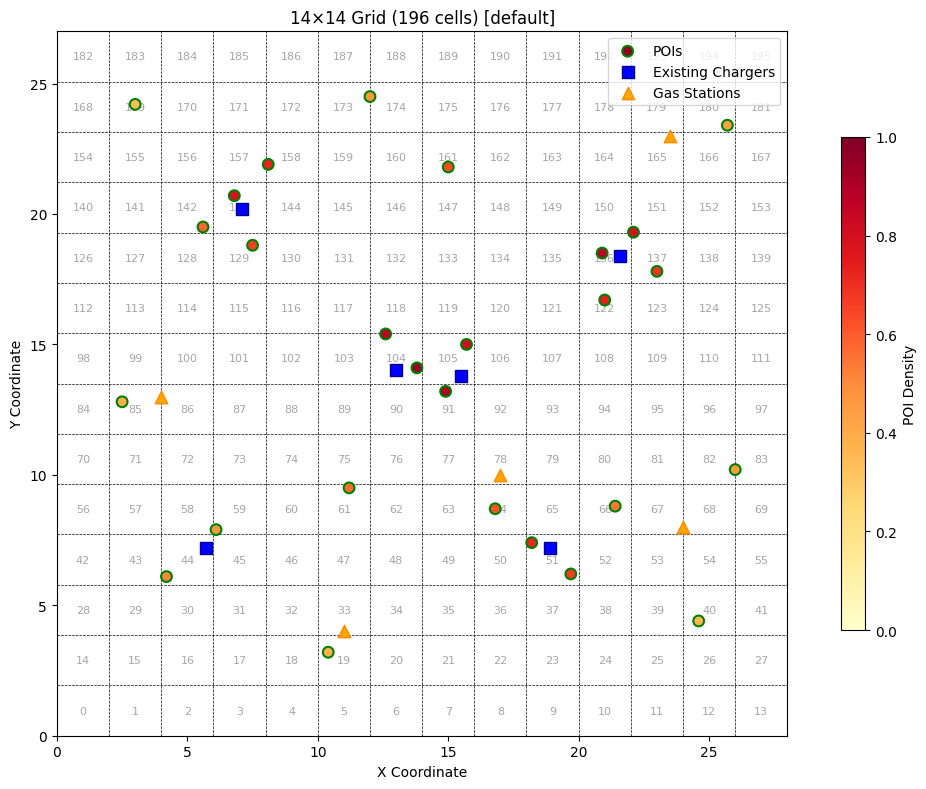

  Grid Info:
    Grid   19 (row=1, col=5): 1 POI(s) [densities: 0.38]
    Grid   33 (row=2, col=5): 1 gas station(s)
    Grid   40 (row=2, col=12): 1 POI(s) [densities: 0.36]
    Grid   44 (row=3, col=2): 1 POI(s) [densities: 0.51] | 1 charger(s)
    Grid   51 (row=3, col=9): 2 POI(s) [densities: 0.72, 0.67] | 1 charger(s)
    Grid   59 (row=4, col=3): 1 POI(s) [densities: 0.47]
    Grid   61 (row=4, col=5): 1 POI(s) [densities: 0.57]
    Grid   64 (row=4, col=8): 1 POI(s) [densities: 0.61]
    Grid   66 (row=4, col=10): 1 POI(s) [densities: 0.54]
    Grid   68 (row=4, col=12): 1 gas station(s)
    Grid   78 (row=5, col=8): 1 gas station(s)
    Grid   83 (row=5, col=13): 1 POI(s) [densities: 0.45]
    Grid   85 (row=6, col=1): 1 POI(s) [densities: 0.40]
    Grid   86 (row=6, col=2): 1 gas station(s)
    Grid   91 (row=6, col=7): 1 POI(s) [densities: 0.91]
    Grid  104 (row=7, col=6): 2 POI(s) [densities: 0.96, 0.88] | 1 charger(s)
    Grid  105 (row=7, col=7): 1 POI(s) [densities: 0.8

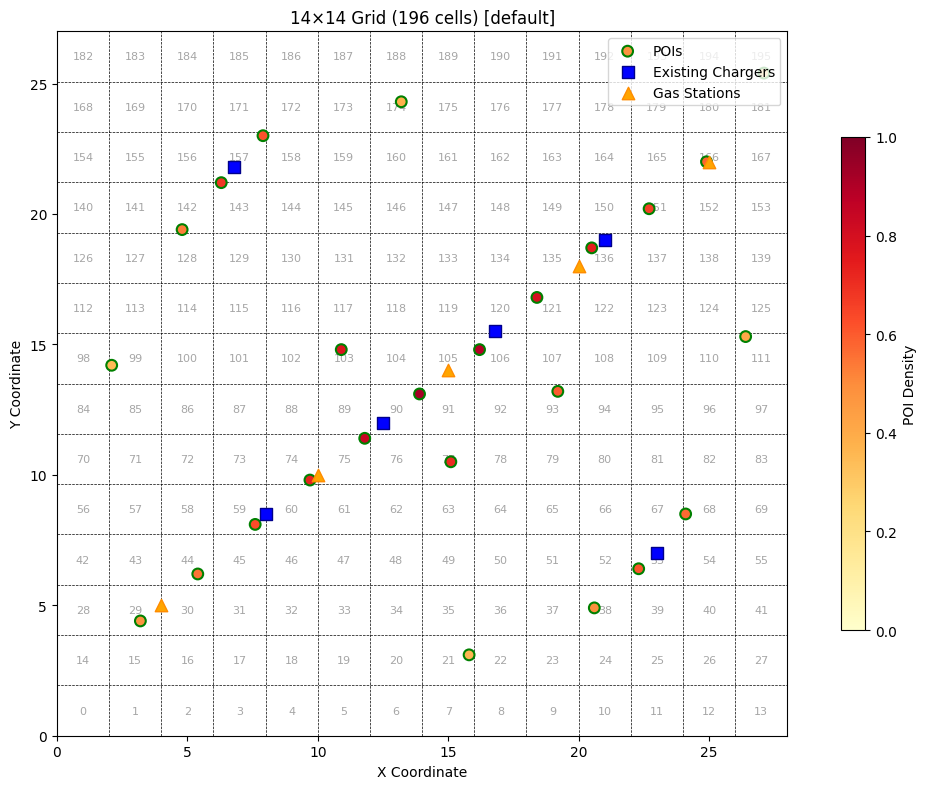

  Grid Info:
    Grid   21 (row=1, col=7): 1 POI(s) [densities: 0.36]
    Grid   29 (row=2, col=1): 1 POI(s) [densities: 0.48]
    Grid   30 (row=2, col=2): 1 gas station(s)
    Grid   38 (row=2, col=10): 1 POI(s) [densities: 0.49]
    Grid   44 (row=3, col=2): 1 POI(s) [densities: 0.55]
    Grid   53 (row=3, col=11): 1 POI(s) [densities: 0.61] | 1 charger(s)
    Grid   59 (row=4, col=3): 1 POI(s) [densities: 0.63]
    Grid   60 (row=4, col=4): 1 charger(s)
    Grid   68 (row=4, col=12): 1 POI(s) [densities: 0.57]
    Grid   74 (row=5, col=4): 1 POI(s) [densities: 0.73]
    Grid   75 (row=5, col=5): 1 POI(s) [densities: 0.84] | 1 gas station(s)
    Grid   77 (row=5, col=7): 1 POI(s) [densities: 0.71]
    Grid   90 (row=6, col=6): 1 POI(s) [densities: 0.92] | 1 charger(s)
    Grid   93 (row=6, col=9): 1 POI(s) [densities: 0.60]
    Grid   99 (row=7, col=1): 1 POI(s) [densities: 0.35]
    Grid  103 (row=7, col=5): 1 POI(s) [densities: 0.77]
    Grid  105 (row=7, col=7): 1 gas station(s)


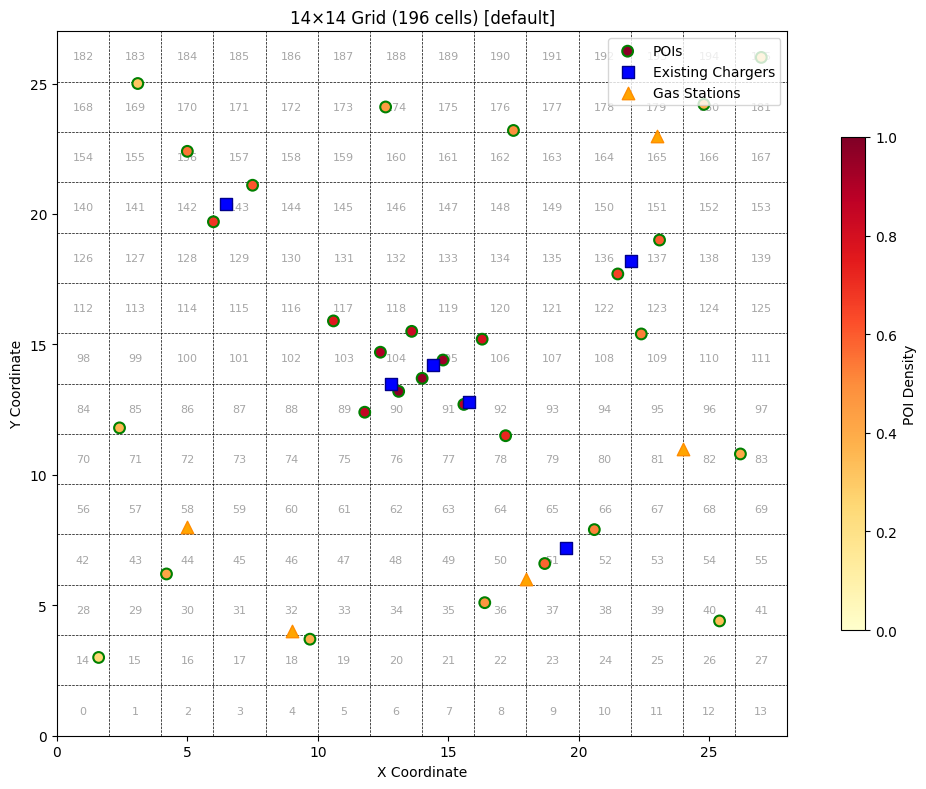

  Grid Info:
    Grid   14 (row=1, col=0): 1 POI(s) [densities: 0.25]
    Grid   18 (row=1, col=4): 1 POI(s) [densities: 0.39]
    Grid   32 (row=2, col=4): 1 gas station(s)
    Grid   36 (row=2, col=8): 1 POI(s) [densities: 0.47]
    Grid   40 (row=2, col=12): 1 POI(s) [densities: 0.34]
    Grid   44 (row=3, col=2): 1 POI(s) [densities: 0.42]
    Grid   51 (row=3, col=9): 1 POI(s) [densities: 0.58] | 1 charger(s) | 1 gas station(s)
    Grid   58 (row=4, col=2): 1 gas station(s)
    Grid   66 (row=4, col=10): 1 POI(s) [densities: 0.52]
    Grid   78 (row=5, col=8): 1 POI(s) [densities: 0.72]
    Grid   82 (row=5, col=12): 1 gas station(s)
    Grid   83 (row=5, col=13): 1 POI(s) [densities: 0.41]
    Grid   85 (row=6, col=1): 1 POI(s) [densities: 0.36]
    Grid   89 (row=6, col=5): 1 POI(s) [densities: 0.85]
    Grid   90 (row=6, col=6): 1 POI(s) [densities: 0.98]
    Grid   91 (row=6, col=7): 1 POI(s) [densities: 0.88] | 1 charger(s)
    Grid  104 (row=7, col=6): 1 POI(s) [densities: 0

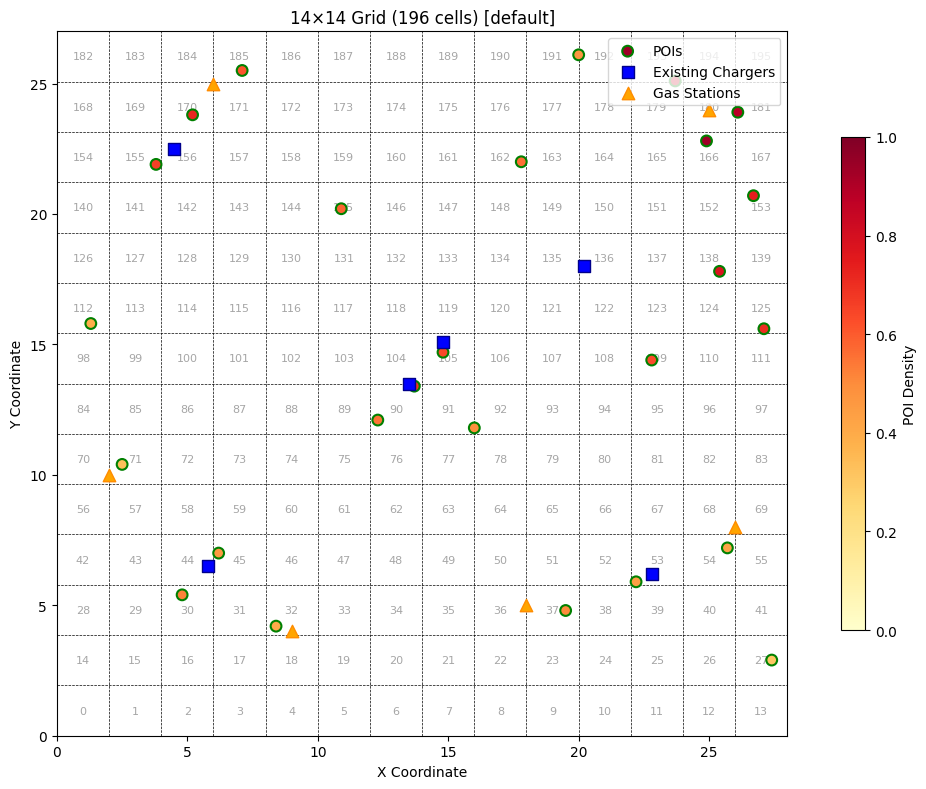

  Grid Info:
    Grid   27 (row=1, col=13): 1 POI(s) [densities: 0.31]
    Grid   30 (row=2, col=2): 1 POI(s) [densities: 0.52]
    Grid   32 (row=2, col=4): 1 POI(s) [densities: 0.40] | 1 gas station(s)
    Grid   37 (row=2, col=9): 1 POI(s) [densities: 0.50] | 1 gas station(s)
    Grid   44 (row=3, col=2): 1 charger(s)
    Grid   45 (row=3, col=3): 1 POI(s) [densities: 0.46]
    Grid   53 (row=3, col=11): 1 POI(s) [densities: 0.44] | 1 charger(s)
    Grid   54 (row=3, col=12): 1 POI(s) [densities: 0.42]
    Grid   69 (row=4, col=13): 1 gas station(s)
    Grid   71 (row=5, col=1): 1 POI(s) [densities: 0.33] | 1 gas station(s)
    Grid   90 (row=6, col=6): 2 POI(s) [densities: 0.69, 0.55]
    Grid   92 (row=6, col=8): 1 POI(s) [densities: 0.49]
    Grid  104 (row=7, col=6): 1 charger(s)
    Grid  105 (row=7, col=7): 1 POI(s) [densities: 0.64] | 1 charger(s)
    Grid  109 (row=7, col=11): 1 POI(s) [densities: 0.63]
    Grid  112 (row=8, col=0): 1 POI(s) [densities: 0.39]
    Grid  125 (

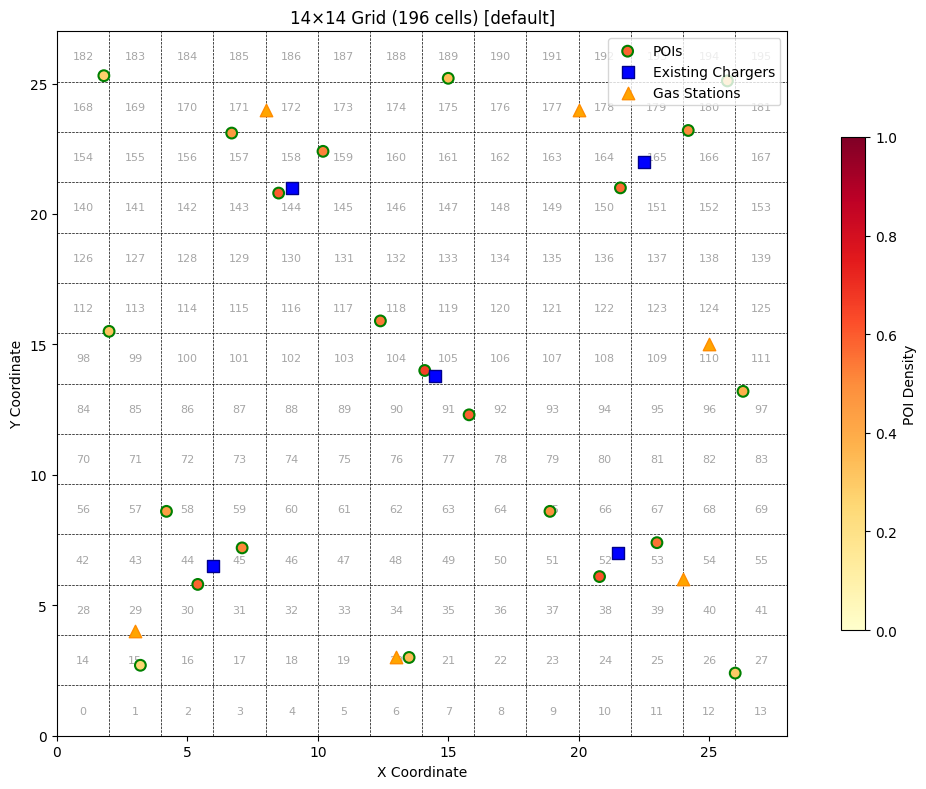

  Grid Info:
    Grid   15 (row=1, col=1): 1 POI(s) [densities: 0.26]
    Grid   20 (row=1, col=6): 1 POI(s) [densities: 0.35] | 1 gas station(s)
    Grid   27 (row=1, col=13): 1 POI(s) [densities: 0.30]
    Grid   29 (row=2, col=1): 1 gas station(s)
    Grid   44 (row=3, col=2): 1 POI(s) [densities: 0.58]
    Grid   45 (row=3, col=3): 1 POI(s) [densities: 0.51] | 1 charger(s)
    Grid   52 (row=3, col=10): 1 POI(s) [densities: 0.62] | 1 charger(s)
    Grid   53 (row=3, col=11): 1 POI(s) [densities: 0.55]
    Grid   54 (row=3, col=12): 1 gas station(s)
    Grid   58 (row=4, col=2): 1 POI(s) [densities: 0.44]
    Grid   65 (row=4, col=9): 1 POI(s) [densities: 0.49]
    Grid   91 (row=6, col=7): 1 POI(s) [densities: 0.59]
    Grid   97 (row=6, col=13): 1 POI(s) [densities: 0.38]
    Grid  105 (row=7, col=7): 1 POI(s) [densities: 0.66] | 1 charger(s)
    Grid  110 (row=7, col=12): 1 gas station(s)
    Grid  113 (row=8, col=1): 1 POI(s) [densities: 0.32]
    Grid  118 (row=8, col=6): 1 POI

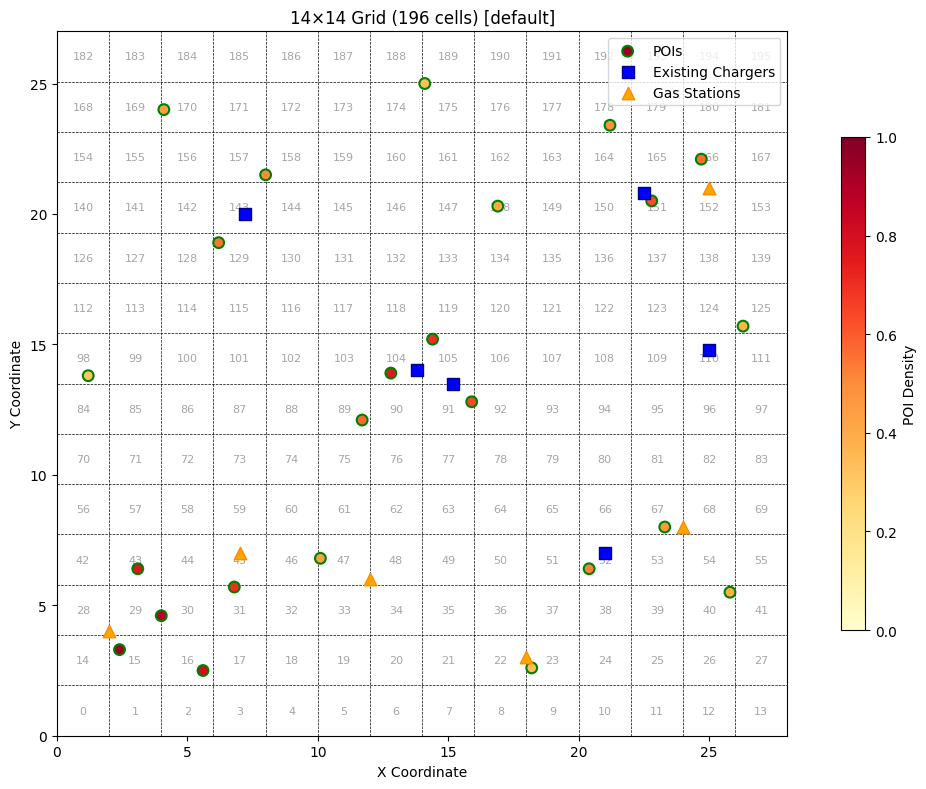

  Grid Info:
    Grid   15 (row=1, col=1): 1 POI(s) [densities: 0.93]
    Grid   16 (row=1, col=2): 1 POI(s) [densities: 0.81]
    Grid   23 (row=1, col=9): 1 POI(s) [densities: 0.34] | 1 gas station(s)
    Grid   29 (row=2, col=1): 1 gas station(s)
    Grid   30 (row=2, col=2): 1 POI(s) [densities: 0.88]
    Grid   31 (row=2, col=3): 1 POI(s) [densities: 0.70]
    Grid   40 (row=2, col=12): 1 POI(s) [densities: 0.39]
    Grid   43 (row=3, col=1): 1 POI(s) [densities: 0.77]
    Grid   45 (row=3, col=3): 1 gas station(s)
    Grid   47 (row=3, col=5): 1 POI(s) [densities: 0.44]
    Grid   48 (row=3, col=6): 1 gas station(s)
    Grid   52 (row=3, col=10): 1 POI(s) [densities: 0.52] | 1 charger(s)
    Grid   67 (row=4, col=11): 1 POI(s) [densities: 0.46]
    Grid   68 (row=4, col=12): 1 gas station(s)
    Grid   89 (row=6, col=5): 1 POI(s) [densities: 0.57]
    Grid   91 (row=6, col=7): 1 POI(s) [densities: 0.64]
    Grid   98 (row=7, col=0): 1 POI(s) [densities: 0.31]
    Grid  104 (row=7

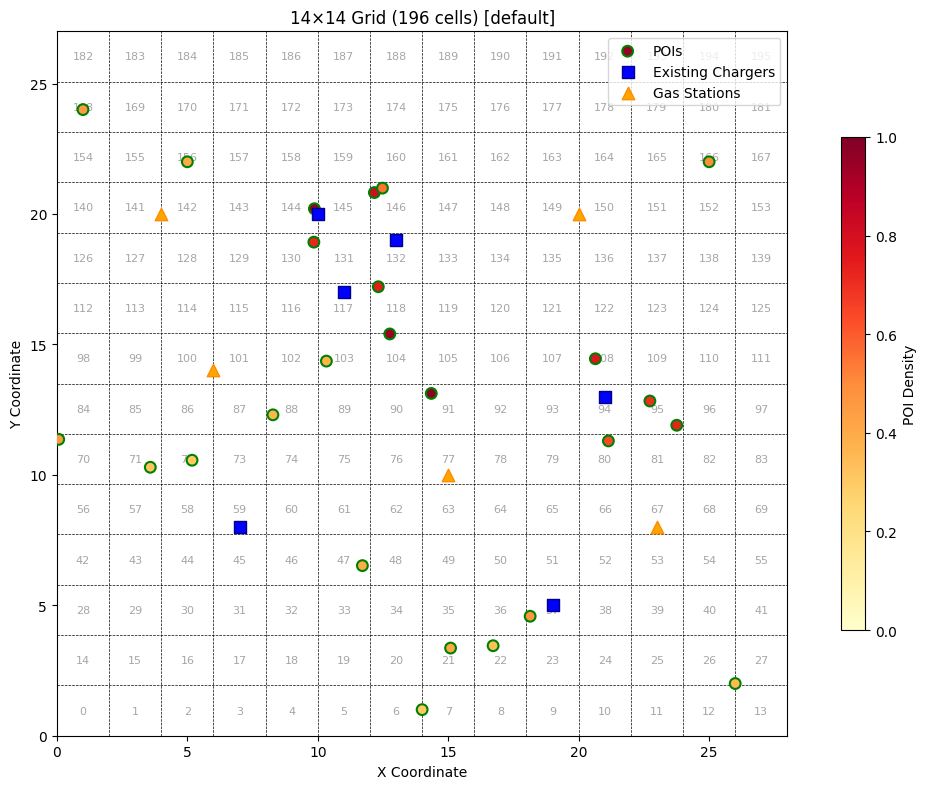

  Grid Info:
    Grid    7 (row=0, col=7): 1 POI(s) [densities: 0.30]
    Grid   21 (row=1, col=7): 1 POI(s) [densities: 0.41]
    Grid   22 (row=1, col=8): 1 POI(s) [densities: 0.33]
    Grid   27 (row=1, col=13): 1 POI(s) [densities: 0.35]
    Grid   37 (row=2, col=9): 1 POI(s) [densities: 0.47] | 1 charger(s)
    Grid   47 (row=3, col=5): 1 POI(s) [densities: 0.40]
    Grid   59 (row=4, col=3): 1 charger(s)
    Grid   67 (row=4, col=11): 1 gas station(s)
    Grid   70 (row=5, col=0): 1 POI(s) [densities: 0.46]
    Grid   71 (row=5, col=1): 1 POI(s) [densities: 0.32]
    Grid   72 (row=5, col=2): 1 POI(s) [densities: 0.30]
    Grid   77 (row=5, col=7): 1 gas station(s)
    Grid   80 (row=5, col=10): 1 POI(s) [densities: 0.64]
    Grid   88 (row=6, col=4): 1 POI(s) [densities: 0.36]
    Grid   91 (row=6, col=7): 1 POI(s) [densities: 0.97]
    Grid   94 (row=6, col=10): 1 charger(s)
    Grid   95 (row=6, col=11): 2 POI(s) [densities: 0.73, 0.70]
    Grid  101 (row=7, col=3): 1 gas stat

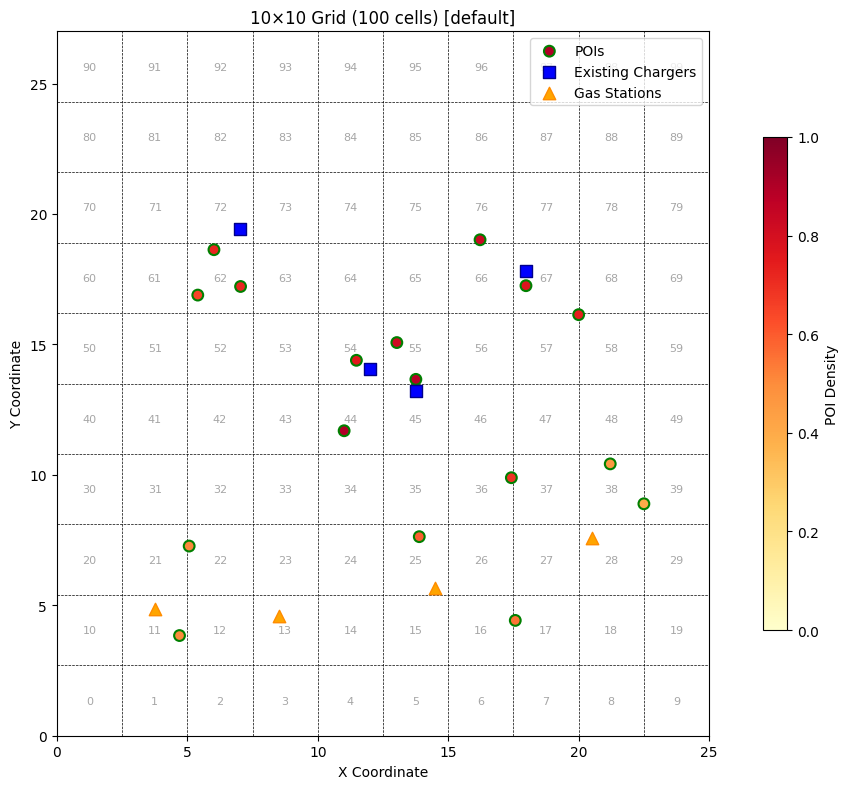

  Grid Info:
    Grid   11 (row=1, col=1): 1 POI(s) [densities: 0.50] | 1 gas station(s)
    Grid   13 (row=1, col=3): 1 gas station(s)
    Grid   17 (row=1, col=7): 1 POI(s) [densities: 0.55]
    Grid   22 (row=2, col=2): 1 POI(s) [densities: 0.51]
    Grid   25 (row=2, col=5): 1 POI(s) [densities: 0.59] | 1 gas station(s)
    Grid   28 (row=2, col=8): 1 gas station(s)
    Grid   36 (row=3, col=6): 1 POI(s) [densities: 0.69]
    Grid   38 (row=3, col=8): 1 POI(s) [densities: 0.46]
    Grid   39 (row=3, col=9): 1 POI(s) [densities: 0.40]
    Grid   44 (row=4, col=4): 1 POI(s) [densities: 0.90]
    Grid   45 (row=4, col=5): 1 charger(s)
    Grid   54 (row=5, col=4): 1 POI(s) [densities: 0.75] | 1 charger(s)
    Grid   55 (row=5, col=5): 2 POI(s) [densities: 0.89, 0.82]
    Grid   58 (row=5, col=8): 1 POI(s) [densities: 0.74]
    Grid   62 (row=6, col=2): 3 POI(s) [densities: 0.72, 0.72, 0.65]
    Grid   67 (row=6, col=7): 1 POI(s) [densities: 0.77] | 1 charger(s)
    Grid   72 (row=7, c

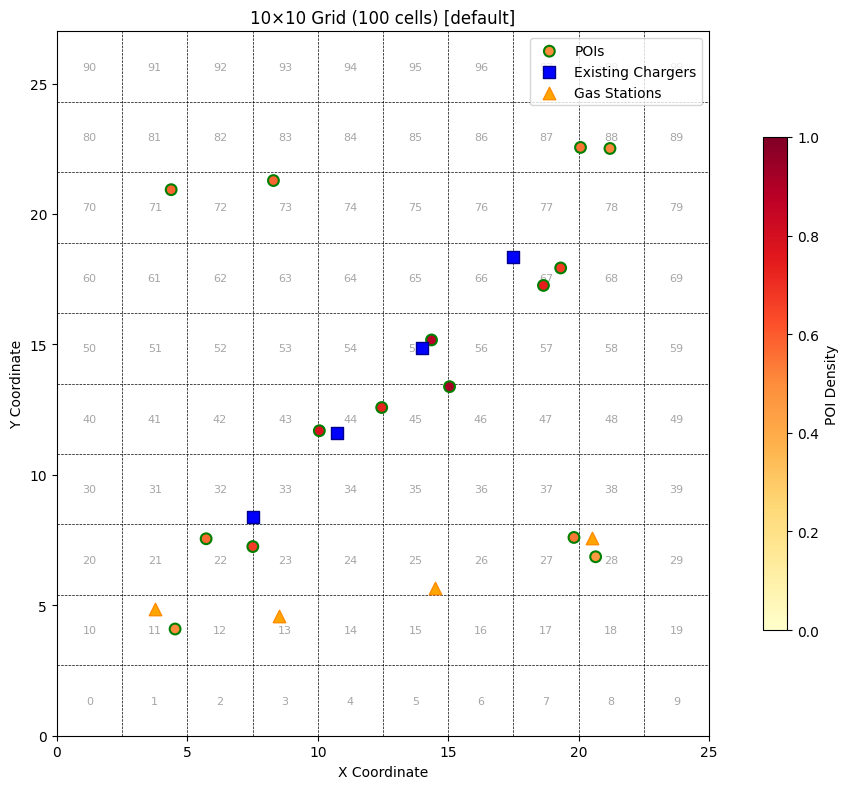

  Grid Info:
    Grid   11 (row=1, col=1): 1 POI(s) [densities: 0.50] | 1 gas station(s)
    Grid   13 (row=1, col=3): 1 gas station(s)
    Grid   22 (row=2, col=2): 1 POI(s) [densities: 0.57]
    Grid   23 (row=2, col=3): 1 POI(s) [densities: 0.67]
    Grid   25 (row=2, col=5): 1 gas station(s)
    Grid   27 (row=2, col=7): 1 POI(s) [densities: 0.54]
    Grid   28 (row=2, col=8): 1 POI(s) [densities: 0.46] | 1 gas station(s)
    Grid   33 (row=3, col=3): 1 charger(s)
    Grid   44 (row=4, col=4): 2 POI(s) [densities: 0.78, 0.73] | 1 charger(s)
    Grid   46 (row=4, col=6): 1 POI(s) [densities: 0.92]
    Grid   55 (row=5, col=5): 1 POI(s) [densities: 0.88] | 1 charger(s)
    Grid   67 (row=6, col=7): 2 POI(s) [densities: 0.74, 0.67] | 1 charger(s)
    Grid   71 (row=7, col=1): 1 POI(s) [densities: 0.58]
    Grid   73 (row=7, col=3): 1 POI(s) [densities: 0.58]
    Grid   88 (row=8, col=8): 2 POI(s) [densities: 0.55, 0.51]
  Pipeline  N=100  K=47  M=4  |Q_obj|=1007  |Q_pruned|=374
  QUBO

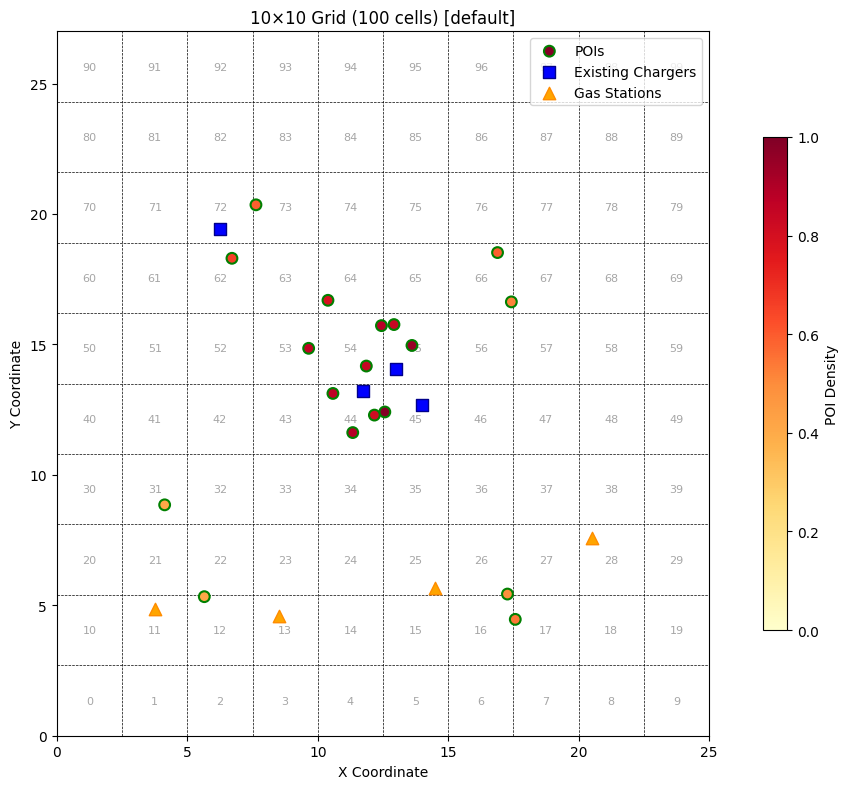

  Grid Info:
    Grid   11 (row=1, col=1): 1 gas station(s)
    Grid   12 (row=1, col=2): 1 POI(s) [densities: 0.41]
    Grid   13 (row=1, col=3): 1 gas station(s)
    Grid   17 (row=1, col=7): 1 POI(s) [densities: 0.54]
    Grid   25 (row=2, col=5): 1 gas station(s)
    Grid   26 (row=2, col=6): 1 POI(s) [densities: 0.49]
    Grid   28 (row=2, col=8): 1 gas station(s)
    Grid   31 (row=3, col=1): 1 POI(s) [densities: 0.41]
    Grid   44 (row=4, col=4): 3 POI(s) [densities: 0.89, 0.87, 0.82] | 1 charger(s)
    Grid   45 (row=4, col=5): 1 POI(s) [densities: 0.99] | 1 charger(s)
    Grid   53 (row=5, col=3): 1 POI(s) [densities: 0.86]
    Grid   54 (row=5, col=4): 2 POI(s) [densities: 0.88, 0.84]
    Grid   55 (row=5, col=5): 2 POI(s) [densities: 0.95, 0.84] | 1 charger(s)
    Grid   62 (row=6, col=2): 1 POI(s) [densities: 0.66]
    Grid   64 (row=6, col=4): 1 POI(s) [densities: 0.79]
    Grid   66 (row=6, col=6): 2 POI(s) [densities: 0.59, 0.52]
    Grid   72 (row=7, col=2): 1 charger(

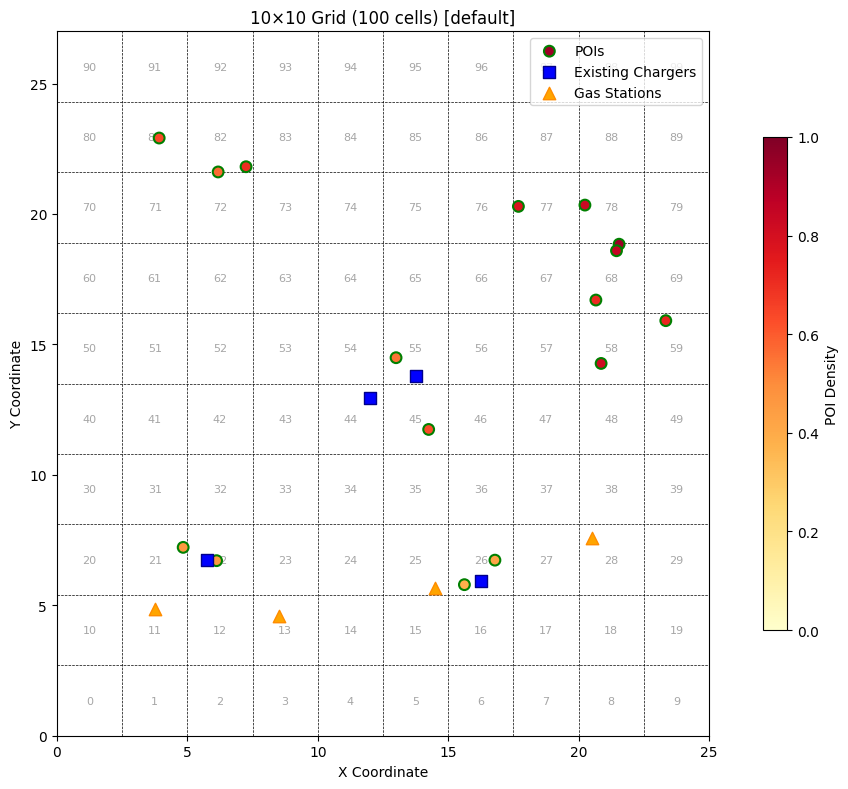

  Grid Info:
    Grid   11 (row=1, col=1): 1 gas station(s)
    Grid   13 (row=1, col=3): 1 gas station(s)
    Grid   21 (row=2, col=1): 1 POI(s) [densities: 0.46]
    Grid   22 (row=2, col=2): 1 POI(s) [densities: 0.46] | 1 charger(s)
    Grid   25 (row=2, col=5): 1 gas station(s)
    Grid   26 (row=2, col=6): 2 POI(s) [densities: 0.42, 0.38] | 1 charger(s)
    Grid   28 (row=2, col=8): 1 gas station(s)
    Grid   44 (row=4, col=4): 1 charger(s)
    Grid   45 (row=4, col=5): 1 POI(s) [densities: 0.63]
    Grid   55 (row=5, col=5): 1 POI(s) [densities: 0.55] | 1 charger(s)
    Grid   58 (row=5, col=8): 1 POI(s) [densities: 0.82]
    Grid   59 (row=5, col=9): 1 POI(s) [densities: 0.72]
    Grid   68 (row=6, col=8): 3 POI(s) [densities: 0.94, 0.85, 0.71]
    Grid   77 (row=7, col=7): 1 POI(s) [densities: 0.78]
    Grid   78 (row=7, col=8): 1 POI(s) [densities: 0.83]
    Grid   81 (row=8, col=1): 1 POI(s) [densities: 0.64]
    Grid   82 (row=8, col=2): 2 POI(s) [densities: 0.70, 0.57]
  P

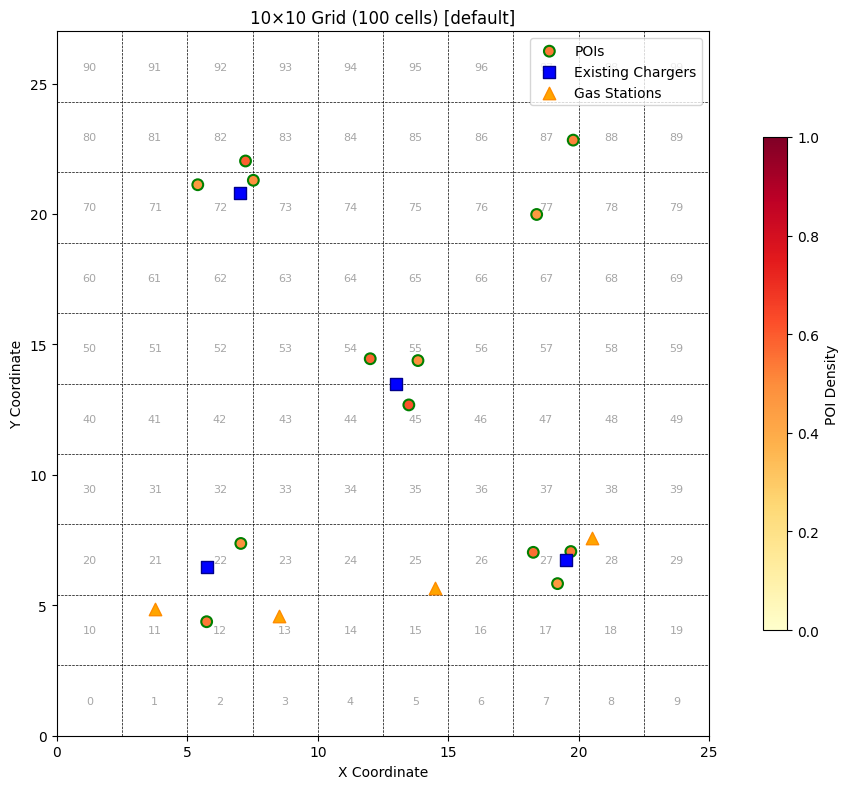

  Grid Info:
    Grid   11 (row=1, col=1): 1 gas station(s)
    Grid   12 (row=1, col=2): 1 POI(s) [densities: 0.54]
    Grid   13 (row=1, col=3): 1 gas station(s)
    Grid   22 (row=2, col=2): 1 POI(s) [densities: 0.49] | 1 charger(s)
    Grid   25 (row=2, col=5): 1 gas station(s)
    Grid   27 (row=2, col=7): 3 POI(s) [densities: 0.56, 0.54, 0.46] | 1 charger(s)
    Grid   28 (row=2, col=8): 1 gas station(s)
    Grid   45 (row=4, col=5): 1 POI(s) [densities: 0.62]
    Grid   54 (row=5, col=4): 1 POI(s) [densities: 0.58]
    Grid   55 (row=5, col=5): 1 POI(s) [densities: 0.49] | 1 charger(s)
    Grid   72 (row=7, col=2): 1 POI(s) [densities: 0.46] | 1 charger(s)
    Grid   73 (row=7, col=3): 1 POI(s) [densities: 0.49]
    Grid   77 (row=7, col=7): 1 POI(s) [densities: 0.46]
    Grid   82 (row=8, col=2): 1 POI(s) [densities: 0.59]
    Grid   87 (row=8, col=7): 1 POI(s) [densities: 0.52]
  Pipeline  N=100  K=12  M=4  |Q_obj|=1002  |Q_pruned|=40
  QUBO sweeps:  alpha1  alpha4  alpha3  al

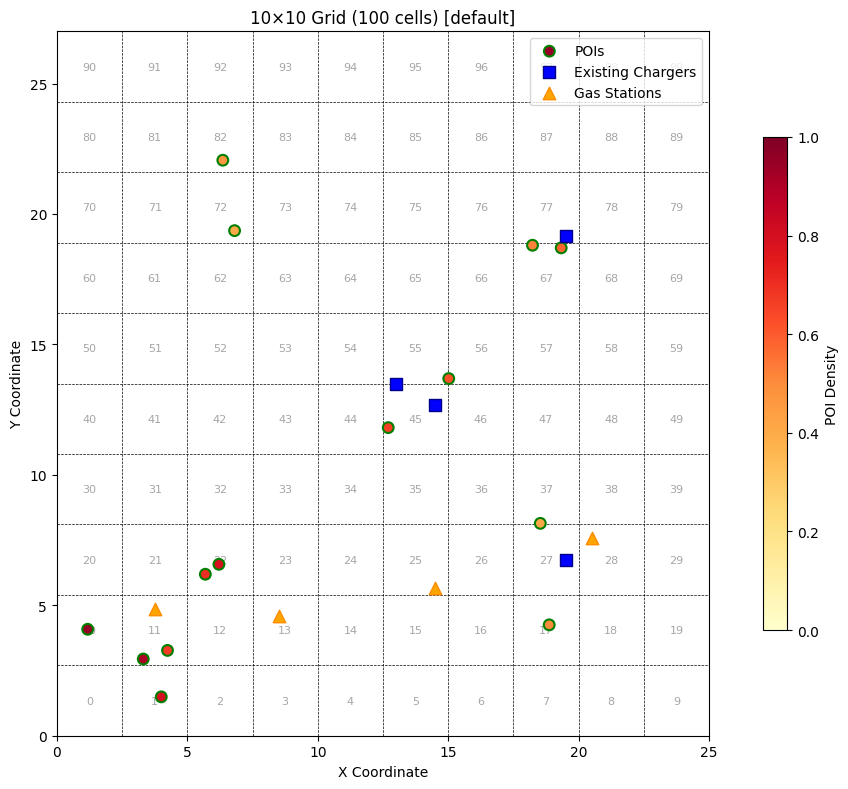

  Grid Info:
    Grid    1 (row=0, col=1): 1 POI(s) [densities: 0.80]
    Grid   10 (row=1, col=0): 1 POI(s) [densities: 0.95]
    Grid   11 (row=1, col=1): 2 POI(s) [densities: 0.91, 0.67] | 1 gas station(s)
    Grid   13 (row=1, col=3): 1 gas station(s)
    Grid   17 (row=1, col=7): 1 POI(s) [densities: 0.50]
    Grid   22 (row=2, col=2): 2 POI(s) [densities: 0.79, 0.70]
    Grid   25 (row=2, col=5): 1 gas station(s)
    Grid   27 (row=2, col=7): 1 charger(s)
    Grid   28 (row=2, col=8): 1 gas station(s)
    Grid   37 (row=3, col=7): 1 POI(s) [densities: 0.41]
    Grid   45 (row=4, col=5): 1 POI(s) [densities: 0.66] | 1 charger(s)
    Grid   55 (row=5, col=5): 1 charger(s)
    Grid   56 (row=5, col=6): 1 POI(s) [densities: 0.62]
    Grid   67 (row=6, col=7): 2 POI(s) [densities: 0.58, 0.52]
    Grid   72 (row=7, col=2): 1 POI(s) [densities: 0.41]
    Grid   77 (row=7, col=7): 1 charger(s)
    Grid   82 (row=8, col=2): 1 POI(s) [densities: 0.47]
  Pipeline  N=100  K=60  M=4  |Q_obj|=

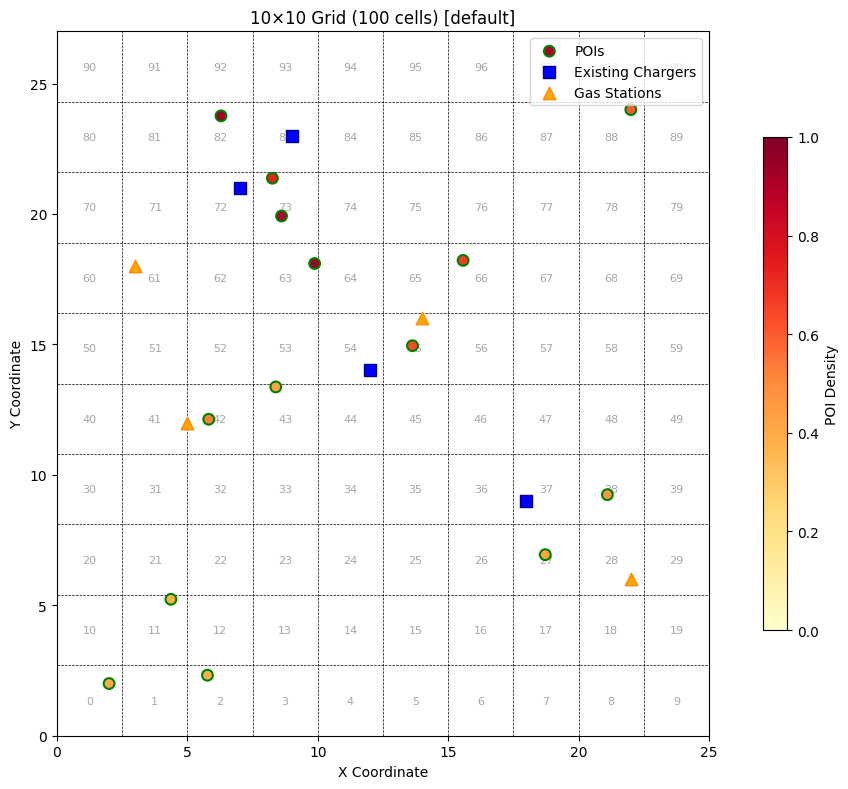

  Grid Info:
    Grid    0 (row=0, col=0): 1 POI(s) [densities: 0.40]
    Grid    2 (row=0, col=2): 1 POI(s) [densities: 0.38]
    Grid   11 (row=1, col=1): 1 POI(s) [densities: 0.38]
    Grid   27 (row=2, col=7): 1 POI(s) [densities: 0.42]
    Grid   28 (row=2, col=8): 1 gas station(s)
    Grid   29 (row=2, col=9): 1 POI(s) [densities: 0.38]
    Grid   37 (row=3, col=7): 1 charger(s)
    Grid   38 (row=3, col=8): 1 POI(s) [densities: 0.47]
    Grid   42 (row=4, col=2): 1 POI(s) [densities: 0.53] | 1 gas station(s)
    Grid   43 (row=4, col=3): 1 POI(s) [densities: 0.42]
    Grid   54 (row=5, col=4): 1 charger(s)
    Grid   55 (row=5, col=5): 1 POI(s) [densities: 0.63] | 1 gas station(s)
    Grid   61 (row=6, col=1): 1 gas station(s)
    Grid   63 (row=6, col=3): 1 POI(s) [densities: 0.94]
    Grid   66 (row=6, col=6): 1 POI(s) [densities: 0.67]
    Grid   72 (row=7, col=2): 1 charger(s)
    Grid   73 (row=7, col=3): 2 POI(s) [densities: 0.91, 0.73]
    Grid   82 (row=8, col=2): 1 POI(

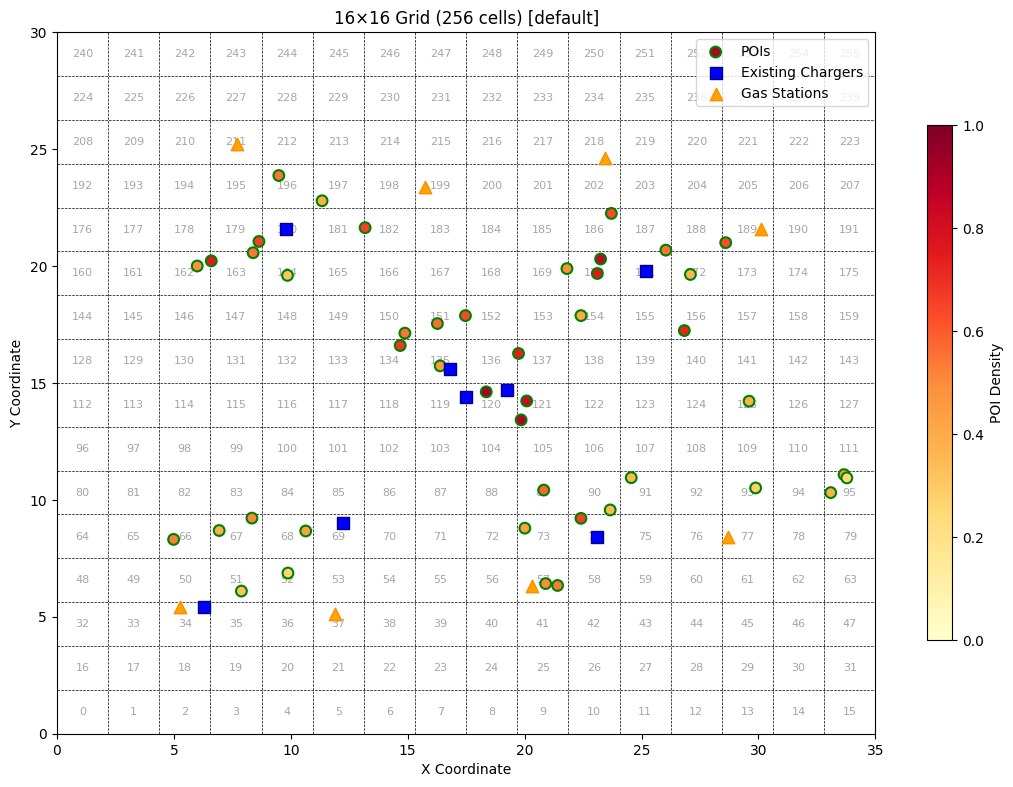

  Grid Info:
    Grid   34 (row=2, col=2): 1 charger(s) | 1 gas station(s)
    Grid   37 (row=2, col=5): 1 gas station(s)
    Grid   51 (row=3, col=3): 1 POI(s) [densities: 0.33]
    Grid   52 (row=3, col=4): 1 POI(s) [densities: 0.26]
    Grid   57 (row=3, col=9): 2 POI(s) [densities: 0.54, 0.50] | 1 gas station(s)
    Grid   66 (row=4, col=2): 1 POI(s) [densities: 0.53]
    Grid   67 (row=4, col=3): 2 POI(s) [densities: 0.51, 0.39]
    Grid   68 (row=4, col=4): 1 POI(s) [densities: 0.43]
    Grid   69 (row=4, col=5): 1 charger(s)
    Grid   73 (row=4, col=9): 1 POI(s) [densities: 0.44]
    Grid   74 (row=4, col=10): 1 POI(s) [densities: 0.66] | 1 charger(s)
    Grid   77 (row=4, col=13): 1 gas station(s)
    Grid   89 (row=5, col=9): 1 POI(s) [densities: 0.58]
    Grid   90 (row=5, col=10): 1 POI(s) [densities: 0.35]
    Grid   91 (row=5, col=11): 1 POI(s) [densities: 0.35]
    Grid   93 (row=5, col=13): 1 POI(s) [densities: 0.28]
    Grid   95 (row=5, col=15): 3 POI(s) [densities: 0

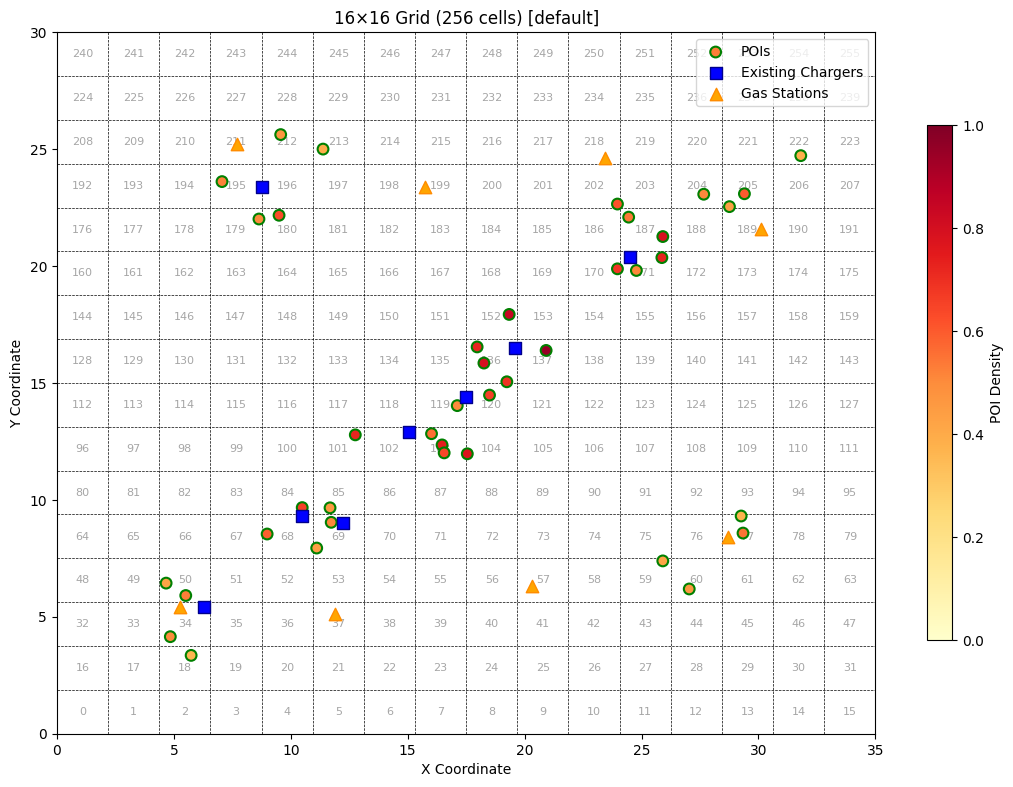

  Grid Info:
    Grid   18 (row=1, col=2): 1 POI(s) [densities: 0.36]
    Grid   34 (row=2, col=2): 1 POI(s) [densities: 0.50] | 1 charger(s) | 1 gas station(s)
    Grid   37 (row=2, col=5): 1 gas station(s)
    Grid   50 (row=3, col=2): 2 POI(s) [densities: 0.53, 0.42]
    Grid   57 (row=3, col=9): 1 gas station(s)
    Grid   59 (row=3, col=11): 1 POI(s) [densities: 0.42]
    Grid   60 (row=3, col=12): 1 POI(s) [densities: 0.46]
    Grid   68 (row=4, col=4): 1 POI(s) [densities: 0.59] | 1 charger(s)
    Grid   69 (row=4, col=5): 2 POI(s) [densities: 0.51, 0.44] | 1 charger(s)
    Grid   77 (row=4, col=13): 2 POI(s) [densities: 0.55, 0.37] | 1 gas station(s)
    Grid   84 (row=5, col=4): 1 POI(s) [densities: 0.66]
    Grid   85 (row=5, col=5): 1 POI(s) [densities: 0.46]
    Grid  101 (row=6, col=5): 1 POI(s) [densities: 0.72]
    Grid  102 (row=6, col=6): 1 charger(s)
    Grid  103 (row=6, col=7): 3 POI(s) [densities: 0.74, 0.64, 0.56]
    Grid  104 (row=6, col=8): 1 POI(s) [densities:

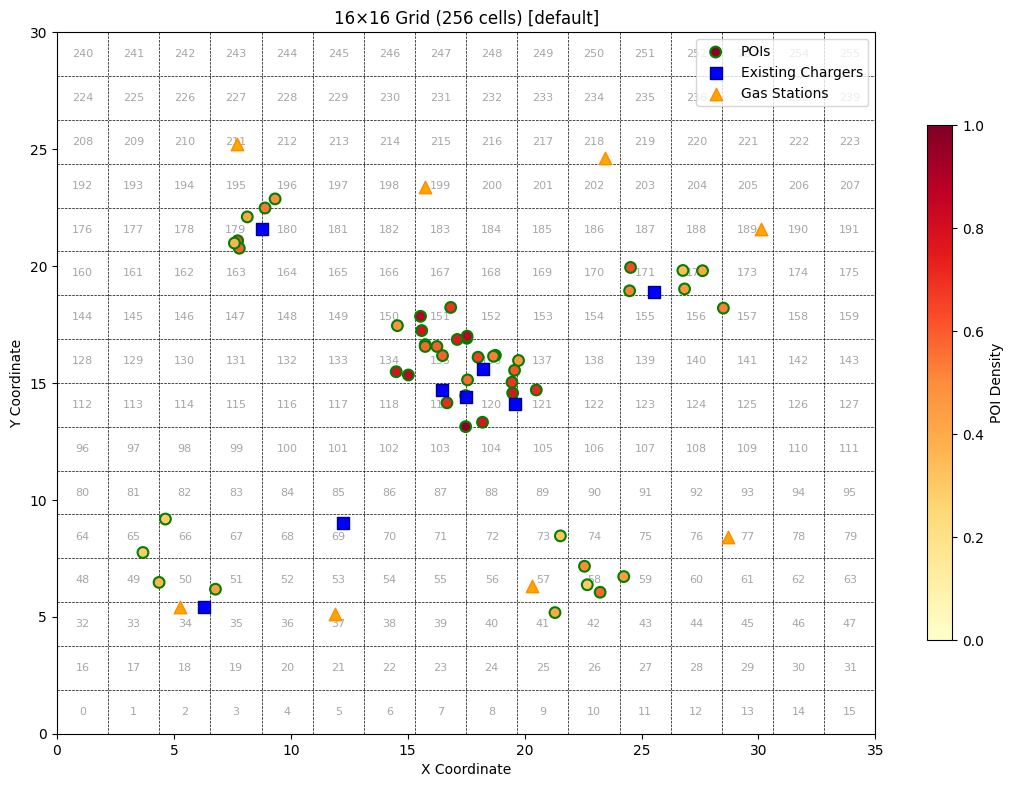

  Grid Info:
    Grid   34 (row=2, col=2): 1 charger(s) | 1 gas station(s)
    Grid   37 (row=2, col=5): 1 gas station(s)
    Grid   41 (row=2, col=9): 1 POI(s) [densities: 0.41]
    Grid   49 (row=3, col=1): 1 POI(s) [densities: 0.36]
    Grid   51 (row=3, col=3): 1 POI(s) [densities: 0.44]
    Grid   57 (row=3, col=9): 1 gas station(s)
    Grid   58 (row=3, col=10): 3 POI(s) [densities: 0.58, 0.50, 0.30]
    Grid   59 (row=3, col=11): 1 POI(s) [densities: 0.45]
    Grid   65 (row=4, col=1): 1 POI(s) [densities: 0.29]
    Grid   66 (row=4, col=2): 1 POI(s) [densities: 0.29]
    Grid   69 (row=4, col=5): 1 charger(s)
    Grid   73 (row=4, col=9): 1 POI(s) [densities: 0.32]
    Grid   77 (row=4, col=13): 1 gas station(s)
    Grid  119 (row=7, col=7): 3 POI(s) [densities: 0.97, 0.71, 0.83] | 1 charger(s)
    Grid  120 (row=7, col=8): 2 POI(s) [densities: 0.78, 0.78] | 2 charger(s)
    Grid  121 (row=7, col=9): 1 POI(s) [densities: 0.72]
    Grid  134 (row=8, col=6): 2 POI(s) [densities: 

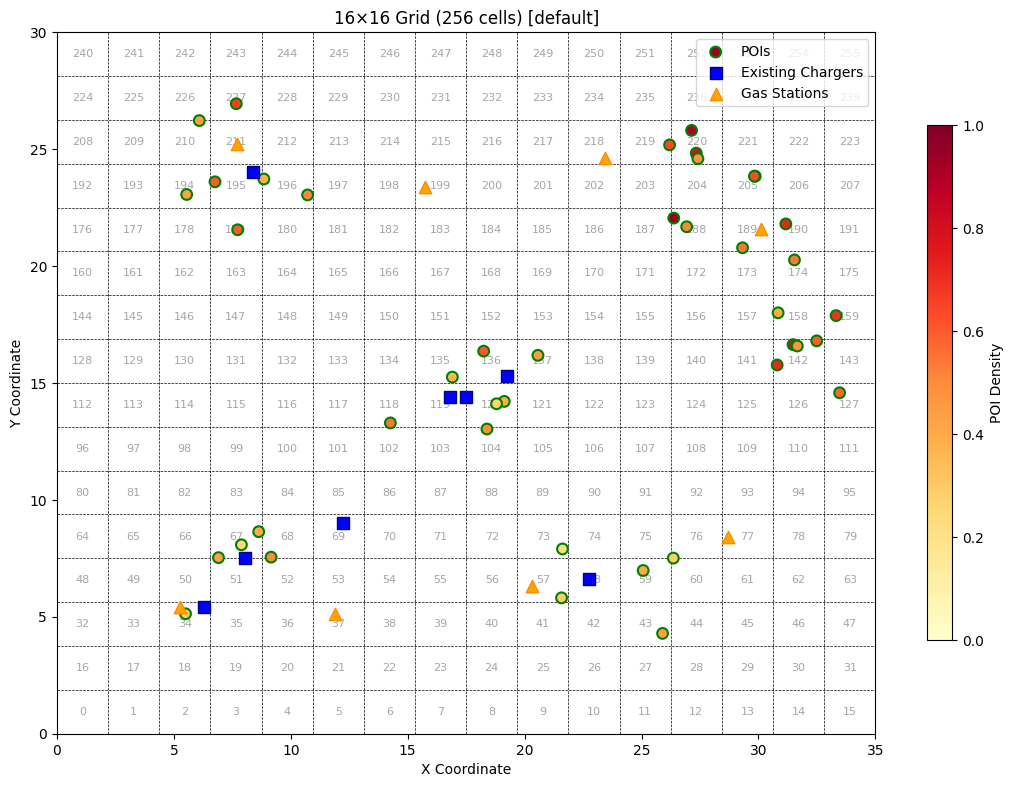

  Grid Info:
    Grid   34 (row=2, col=2): 1 POI(s) [densities: 0.30] | 1 charger(s) | 1 gas station(s)
    Grid   37 (row=2, col=5): 1 gas station(s)
    Grid   43 (row=2, col=11): 1 POI(s) [densities: 0.43]
    Grid   57 (row=3, col=9): 1 POI(s) [densities: 0.29] | 1 gas station(s)
    Grid   58 (row=3, col=10): 1 charger(s)
    Grid   59 (row=3, col=11): 1 POI(s) [densities: 0.40]
    Grid   67 (row=4, col=3): 3 POI(s) [densities: 0.43, 0.40, 0.25] | 1 charger(s)
    Grid   68 (row=4, col=4): 1 POI(s) [densities: 0.51]
    Grid   69 (row=4, col=5): 1 charger(s)
    Grid   73 (row=4, col=9): 1 POI(s) [densities: 0.22]
    Grid   76 (row=4, col=12): 1 POI(s) [densities: 0.29]
    Grid   77 (row=4, col=13): 1 gas station(s)
    Grid  104 (row=6, col=8): 1 POI(s) [densities: 0.49]
    Grid  118 (row=7, col=6): 1 POI(s) [densities: 0.55]
    Grid  119 (row=7, col=7): 1 charger(s)
    Grid  120 (row=7, col=8): 2 POI(s) [densities: 0.39, 0.27] | 1 charger(s)
    Grid  127 (row=7, col=15): 

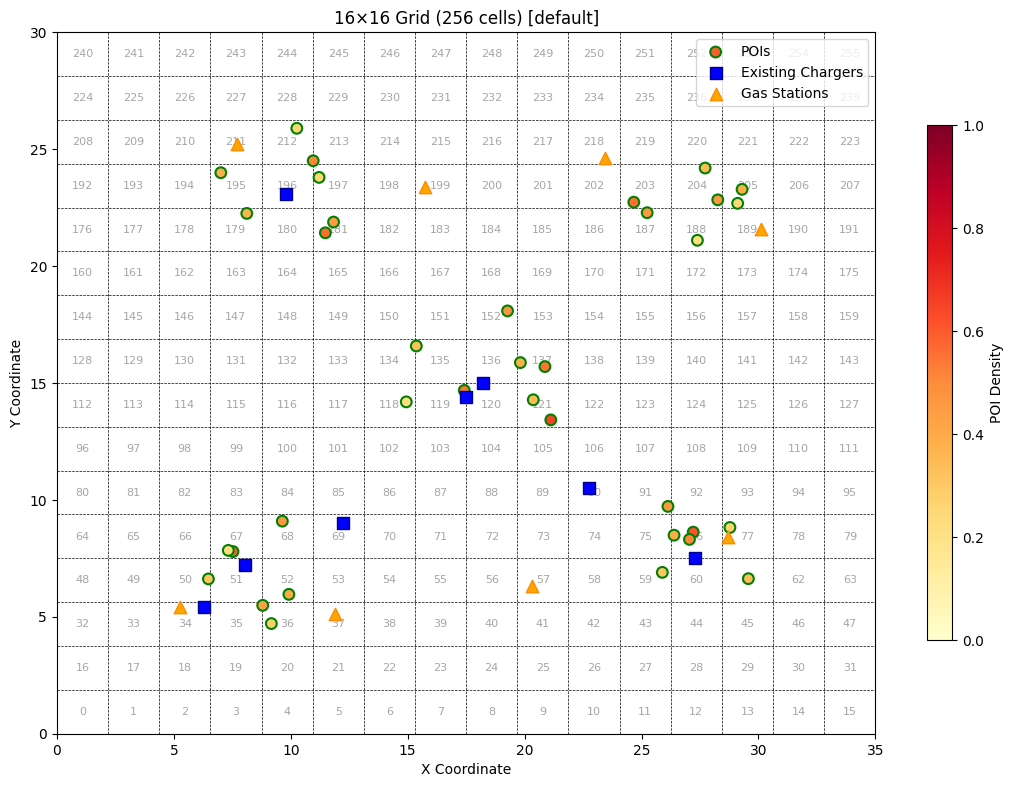

  Grid Info:
    Grid   34 (row=2, col=2): 1 charger(s) | 1 gas station(s)
    Grid   36 (row=2, col=4): 2 POI(s) [densities: 0.43, 0.28]
    Grid   37 (row=2, col=5): 1 gas station(s)
    Grid   50 (row=3, col=2): 1 POI(s) [densities: 0.31]
    Grid   51 (row=3, col=3): 1 charger(s)
    Grid   52 (row=3, col=4): 1 POI(s) [densities: 0.41]
    Grid   57 (row=3, col=9): 1 gas station(s)
    Grid   59 (row=3, col=11): 1 POI(s) [densities: 0.31]
    Grid   61 (row=3, col=13): 1 POI(s) [densities: 0.34]
    Grid   67 (row=4, col=3): 2 POI(s) [densities: 0.59, 0.23]
    Grid   68 (row=4, col=4): 1 POI(s) [densities: 0.47]
    Grid   69 (row=4, col=5): 1 charger(s)
    Grid   76 (row=4, col=12): 3 POI(s) [densities: 0.62, 0.51, 0.40] | 1 charger(s)
    Grid   77 (row=4, col=13): 1 POI(s) [densities: 0.27] | 1 gas station(s)
    Grid   90 (row=5, col=10): 1 charger(s)
    Grid   91 (row=5, col=11): 1 POI(s) [densities: 0.47]
    Grid  118 (row=7, col=6): 1 POI(s) [densities: 0.22]
    Grid  1

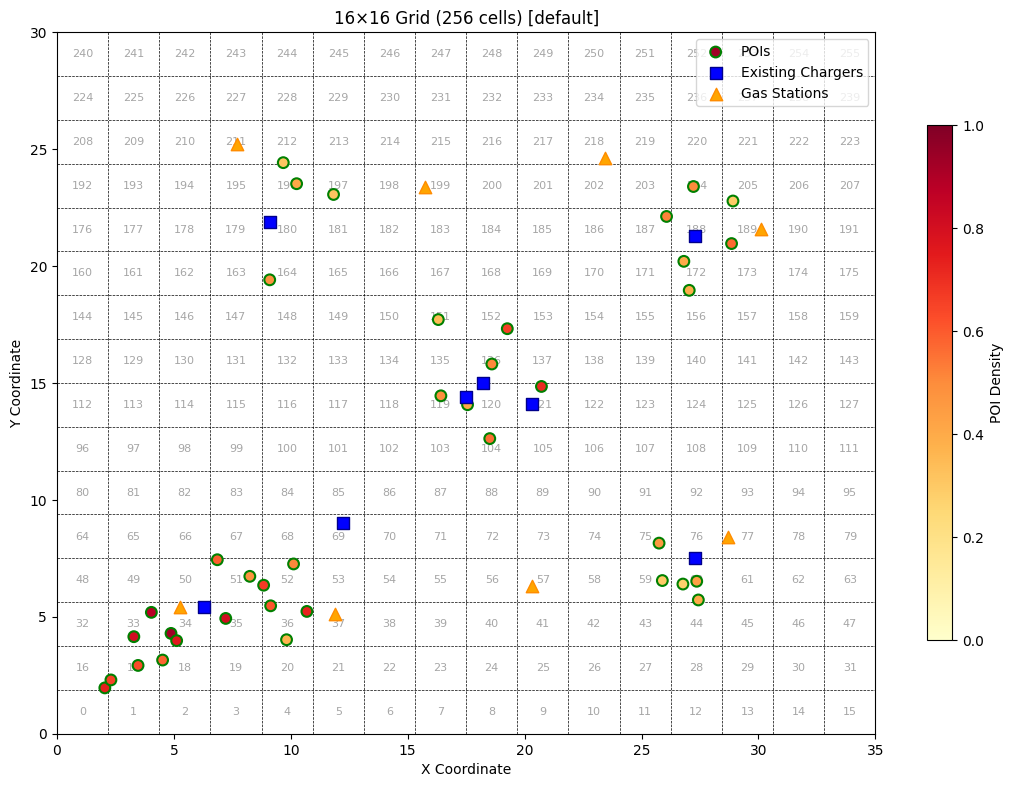

  Grid Info:
    Grid   16 (row=1, col=0): 1 POI(s) [densities: 0.74]
    Grid   17 (row=1, col=1): 2 POI(s) [densities: 0.65, 0.63]
    Grid   18 (row=1, col=2): 1 POI(s) [densities: 0.58]
    Grid   33 (row=2, col=1): 2 POI(s) [densities: 0.88, 0.81]
    Grid   34 (row=2, col=2): 2 POI(s) [densities: 0.93, 0.76] | 1 charger(s) | 1 gas station(s)
    Grid   35 (row=2, col=3): 1 POI(s) [densities: 0.81]
    Grid   36 (row=2, col=4): 3 POI(s) [densities: 0.73, 0.61, 0.37]
    Grid   37 (row=2, col=5): 1 gas station(s)
    Grid   51 (row=3, col=3): 2 POI(s) [densities: 0.59, 0.48]
    Grid   52 (row=3, col=4): 2 POI(s) [densities: 0.67, 0.51]
    Grid   57 (row=3, col=9): 1 gas station(s)
    Grid   59 (row=3, col=11): 1 POI(s) [densities: 0.30]
    Grid   60 (row=3, col=12): 3 POI(s) [densities: 0.43, 0.40, 0.28]
    Grid   69 (row=4, col=5): 1 charger(s)
    Grid   75 (row=4, col=11): 1 POI(s) [densities: 0.46]
    Grid   76 (row=4, col=12): 1 charger(s)
    Grid   77 (row=4, col=13): 

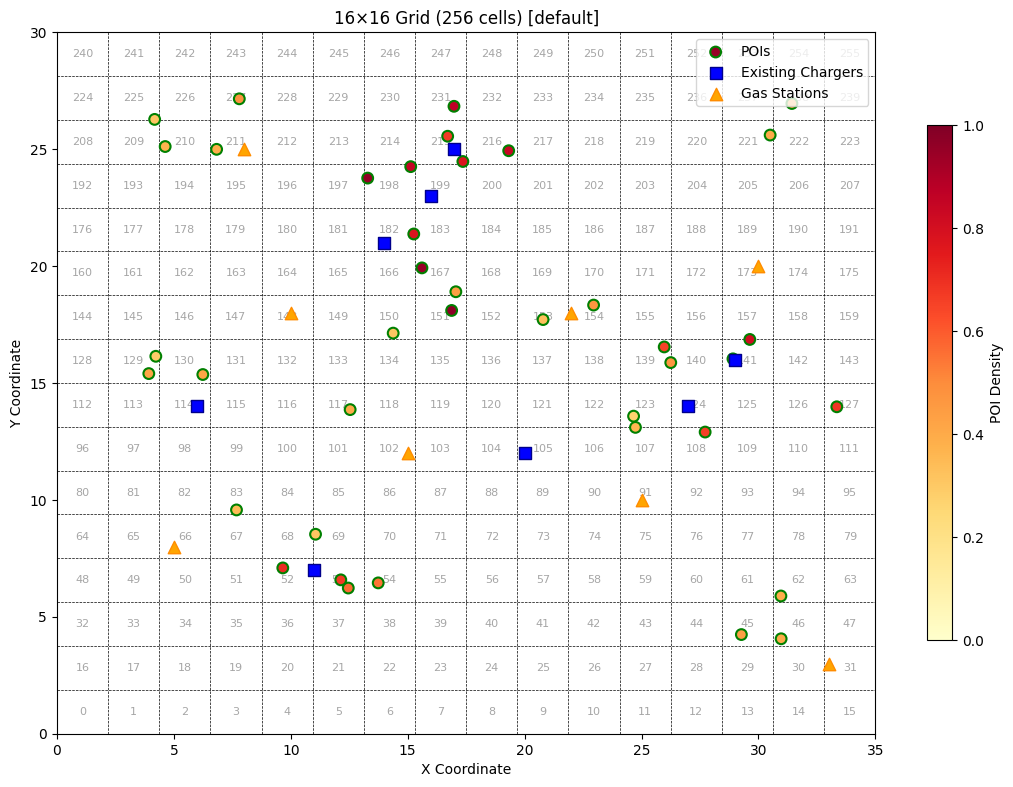

  Grid Info:
    Grid   31 (row=1, col=15): 1 gas station(s)
    Grid   45 (row=2, col=13): 1 POI(s) [densities: 0.44]
    Grid   46 (row=2, col=14): 1 POI(s) [densities: 0.40]
    Grid   52 (row=3, col=4): 1 POI(s) [densities: 0.71]
    Grid   53 (row=3, col=5): 2 POI(s) [densities: 0.57, 0.67] | 1 charger(s)
    Grid   54 (row=3, col=6): 1 POI(s) [densities: 0.55]
    Grid   62 (row=3, col=14): 1 POI(s) [densities: 0.39]
    Grid   66 (row=4, col=2): 1 gas station(s)
    Grid   69 (row=4, col=5): 1 POI(s) [densities: 0.31]
    Grid   83 (row=5, col=3): 1 POI(s) [densities: 0.34]
    Grid   91 (row=5, col=11): 1 gas station(s)
    Grid  102 (row=6, col=6): 1 gas station(s)
    Grid  105 (row=6, col=9): 1 charger(s)
    Grid  107 (row=6, col=11): 1 POI(s) [densities: 0.36]
    Grid  108 (row=6, col=12): 1 POI(s) [densities: 0.66]
    Grid  114 (row=7, col=2): 1 charger(s)
    Grid  117 (row=7, col=5): 1 POI(s) [densities: 0.40]
    Grid  123 (row=7, col=11): 1 POI(s) [densities: 0.27]


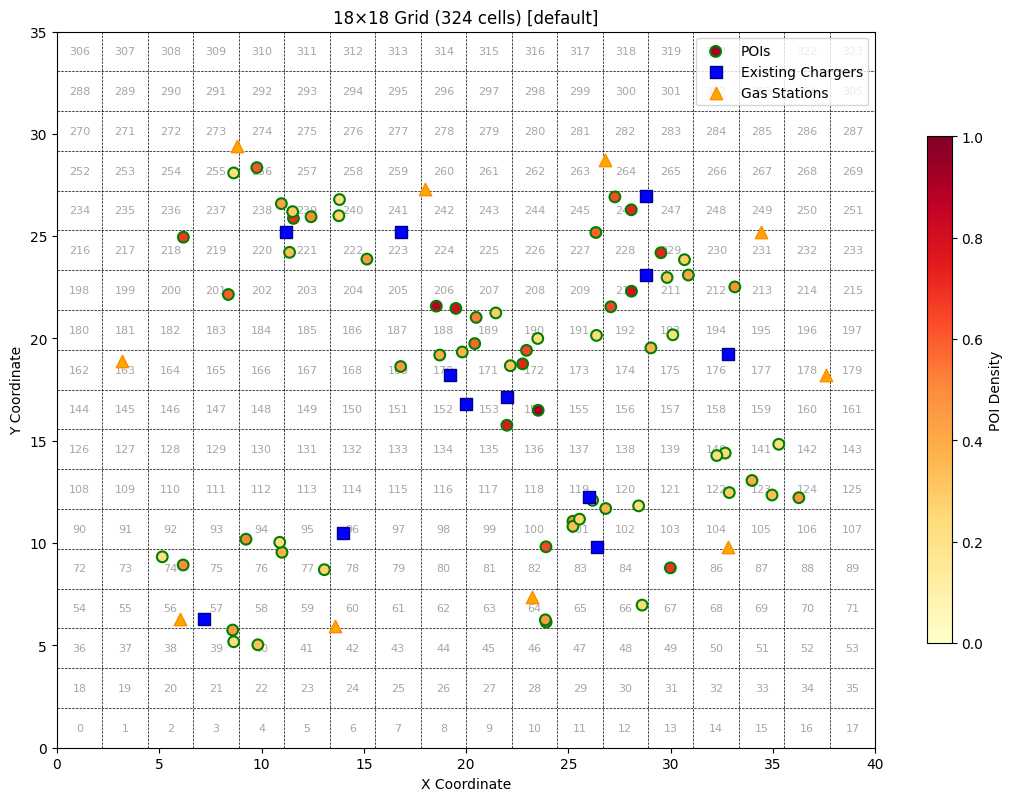

  Grid Info:
    Grid   39 (row=2, col=3): 2 POI(s) [densities: 0.45, 0.22]
    Grid   40 (row=2, col=4): 1 POI(s) [densities: 0.33]
    Grid   56 (row=3, col=2): 1 gas station(s)
    Grid   57 (row=3, col=3): 1 charger(s)
    Grid   60 (row=3, col=6): 1 gas station(s)
    Grid   64 (row=3, col=10): 2 POI(s) [densities: 0.52, 0.45] | 1 gas station(s)
    Grid   66 (row=3, col=12): 1 POI(s) [densities: 0.24]
    Grid   74 (row=4, col=2): 2 POI(s) [densities: 0.50, 0.22]
    Grid   76 (row=4, col=4): 1 POI(s) [densities: 0.38]
    Grid   77 (row=4, col=5): 1 POI(s) [densities: 0.27]
    Grid   85 (row=4, col=13): 1 POI(s) [densities: 0.69]
    Grid   94 (row=5, col=4): 2 POI(s) [densities: 0.51, 0.22]
    Grid   96 (row=5, col=6): 1 charger(s)
    Grid  100 (row=5, col=10): 1 POI(s) [densities: 0.64]
    Grid  101 (row=5, col=11): 3 POI(s) [densities: 0.48, 0.34, 0.26] | 1 charger(s)
    Grid  104 (row=5, col=14): 1 gas station(s)
    Grid  119 (row=6, col=11): 1 POI(s) [densities: 0.22]

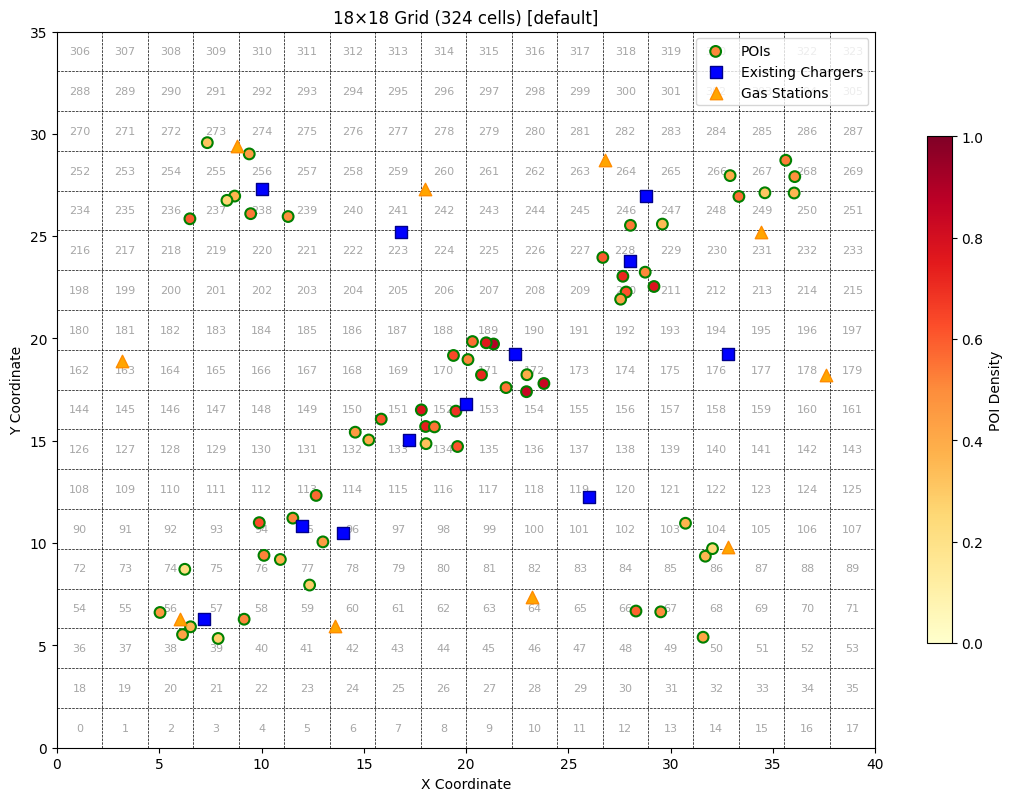

  Grid Info:
    Grid   38 (row=2, col=2): 1 POI(s) [densities: 0.43]
    Grid   39 (row=2, col=3): 1 POI(s) [densities: 0.28]
    Grid   50 (row=2, col=14): 1 POI(s) [densities: 0.42]
    Grid   56 (row=3, col=2): 2 POI(s) [densities: 0.46, 0.36] | 1 gas station(s)
    Grid   57 (row=3, col=3): 1 charger(s)
    Grid   58 (row=3, col=4): 1 POI(s) [densities: 0.51]
    Grid   60 (row=3, col=6): 1 gas station(s)
    Grid   64 (row=3, col=10): 1 gas station(s)
    Grid   66 (row=3, col=12): 1 POI(s) [densities: 0.58]
    Grid   67 (row=3, col=13): 1 POI(s) [densities: 0.50]
    Grid   74 (row=4, col=2): 1 POI(s) [densities: 0.22]
    Grid   76 (row=4, col=4): 2 POI(s) [densities: 0.52, 0.39]
    Grid   77 (row=4, col=5): 1 POI(s) [densities: 0.29]
    Grid   86 (row=4, col=14): 1 POI(s) [densities: 0.36]
    Grid   94 (row=5, col=4): 1 POI(s) [densities: 0.63]
    Grid   95 (row=5, col=5): 2 POI(s) [densities: 0.51, 0.45] | 1 charger(s)
    Grid   96 (row=5, col=6): 1 charger(s)
    Grid 

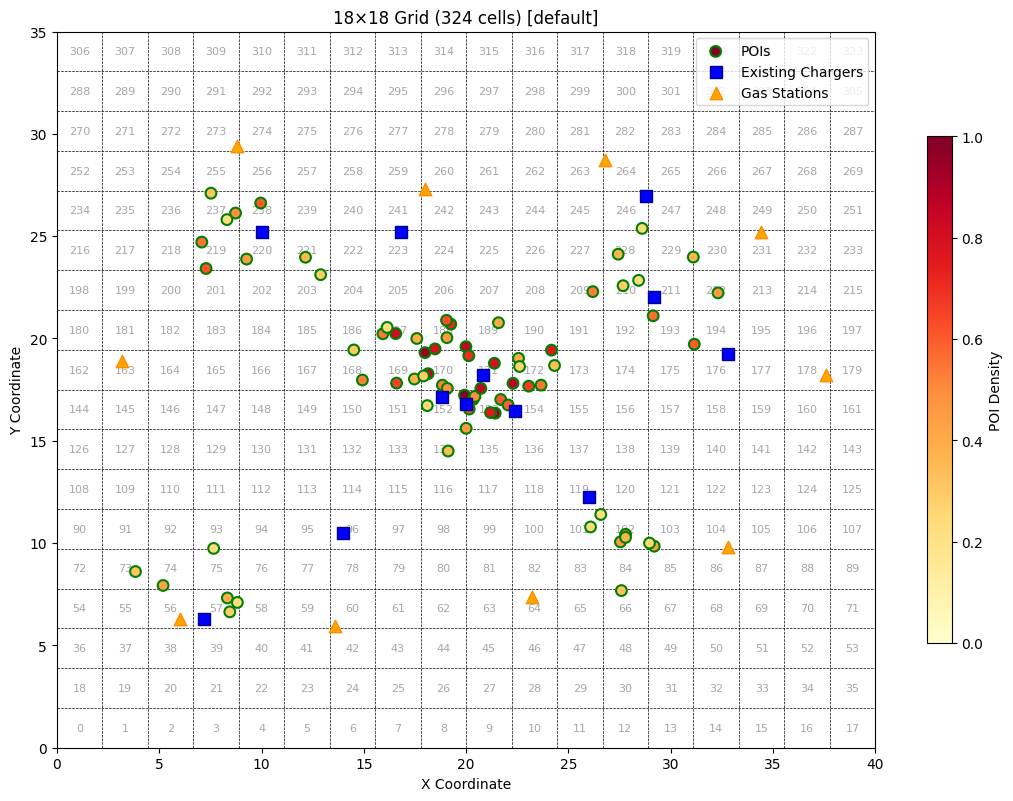

  Grid Info:
    Grid   56 (row=3, col=2): 1 gas station(s)
    Grid   57 (row=3, col=3): 3 POI(s) [densities: 0.38, 0.29, 0.23] | 1 charger(s)
    Grid   60 (row=3, col=6): 1 gas station(s)
    Grid   64 (row=3, col=10): 1 gas station(s)
    Grid   66 (row=3, col=12): 1 POI(s) [densities: 0.32]
    Grid   73 (row=4, col=1): 1 POI(s) [densities: 0.32]
    Grid   74 (row=4, col=2): 1 POI(s) [densities: 0.43]
    Grid   93 (row=5, col=3): 1 POI(s) [densities: 0.22]
    Grid   96 (row=5, col=6): 1 charger(s)
    Grid  101 (row=5, col=11): 2 POI(s) [densities: 0.24, 0.22]
    Grid  102 (row=5, col=12): 3 POI(s) [densities: 0.58, 0.46, 0.37]
    Grid  103 (row=5, col=13): 2 POI(s) [densities: 0.43, 0.25]
    Grid  104 (row=5, col=14): 1 gas station(s)
    Grid  119 (row=6, col=11): 1 charger(s)
    Grid  134 (row=7, col=8): 1 POI(s) [densities: 0.35]
    Grid  152 (row=8, col=8): 2 POI(s) [densities: 0.99, 0.24] | 1 charger(s)
    Grid  153 (row=8, col=9): 8 POI(s) [densities: 0.77, 0.63, 0

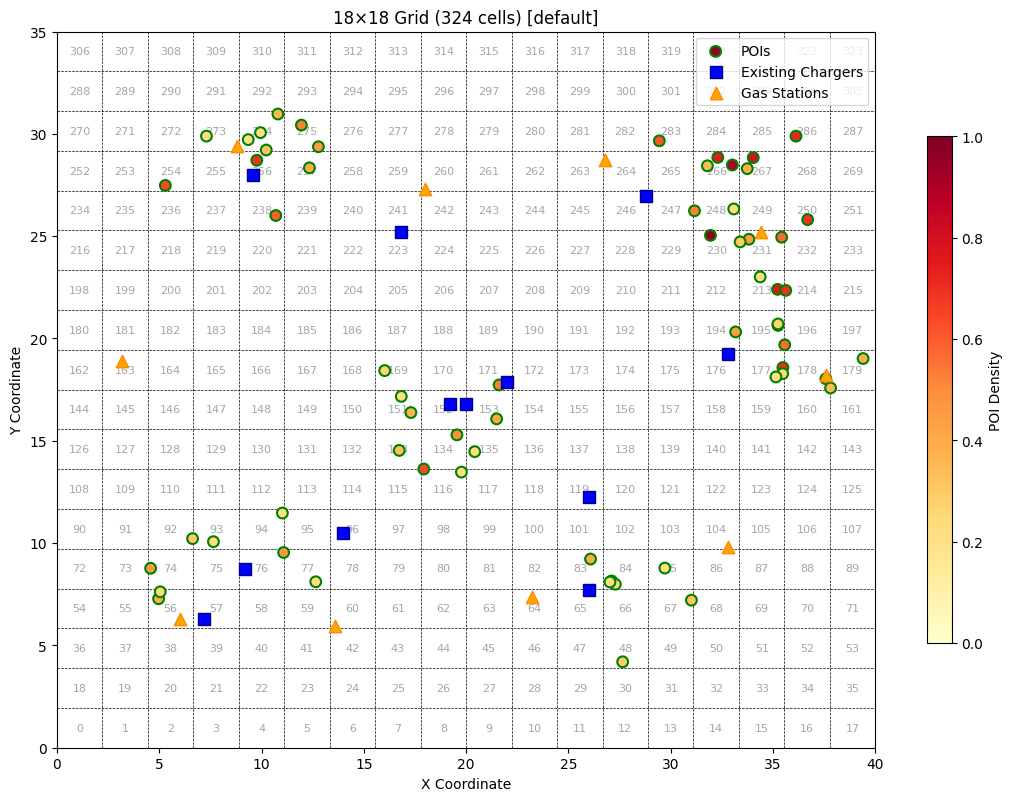

  Grid Info:
    Grid   48 (row=2, col=12): 1 POI(s) [densities: 0.29]
    Grid   56 (row=3, col=2): 2 POI(s) [densities: 0.38, 0.25] | 1 gas station(s)
    Grid   57 (row=3, col=3): 1 charger(s)
    Grid   60 (row=3, col=6): 1 gas station(s)
    Grid   64 (row=3, col=10): 1 gas station(s)
    Grid   65 (row=3, col=11): 1 charger(s)
    Grid   67 (row=3, col=13): 1 POI(s) [densities: 0.32]
    Grid   74 (row=4, col=2): 1 POI(s) [densities: 0.45]
    Grid   76 (row=4, col=4): 1 POI(s) [densities: 0.46] | 1 charger(s)
    Grid   77 (row=4, col=5): 1 POI(s) [densities: 0.22]
    Grid   83 (row=4, col=11): 1 POI(s) [densities: 0.40]
    Grid   84 (row=4, col=12): 3 POI(s) [densities: 0.40, 0.22, 0.22]
    Grid   85 (row=4, col=13): 1 POI(s) [densities: 0.22]
    Grid   92 (row=5, col=2): 1 POI(s) [densities: 0.30]
    Grid   93 (row=5, col=3): 1 POI(s) [densities: 0.22]
    Grid   94 (row=5, col=4): 1 POI(s) [densities: 0.22]
    Grid   96 (row=5, col=6): 1 charger(s)
    Grid  104 (row=5,

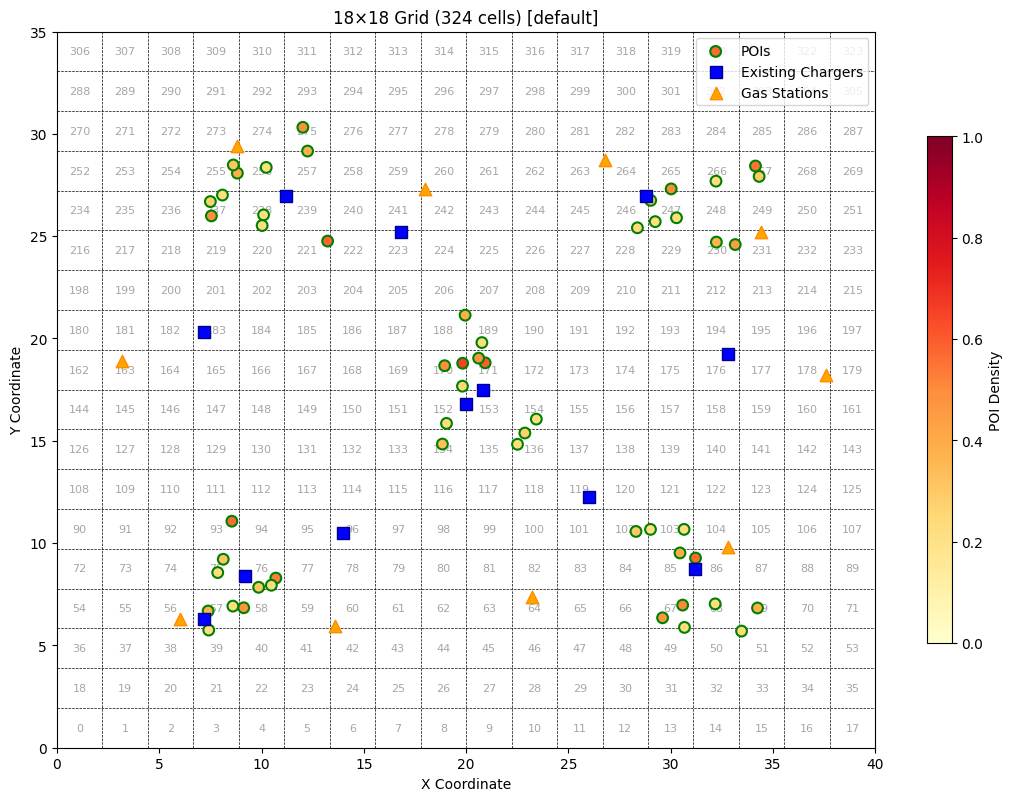

  Grid Info:
    Grid   39 (row=2, col=3): 1 POI(s) [densities: 0.22]
    Grid   51 (row=2, col=15): 1 POI(s) [densities: 0.24]
    Grid   56 (row=3, col=2): 1 gas station(s)
    Grid   57 (row=3, col=3): 2 POI(s) [densities: 0.37, 0.22] | 1 charger(s)
    Grid   58 (row=3, col=4): 1 POI(s) [densities: 0.48]
    Grid   60 (row=3, col=6): 1 gas station(s)
    Grid   64 (row=3, col=10): 1 gas station(s)
    Grid   67 (row=3, col=13): 3 POI(s) [densities: 0.51, 0.47, 0.22]
    Grid   68 (row=3, col=14): 1 POI(s) [densities: 0.22]
    Grid   69 (row=3, col=15): 1 POI(s) [densities: 0.39]
    Grid   75 (row=4, col=3): 2 POI(s) [densities: 0.31, 0.22]
    Grid   76 (row=4, col=4): 3 POI(s) [densities: 0.52, 0.31, 0.22] | 1 charger(s)
    Grid   85 (row=4, col=13): 1 POI(s) [densities: 0.40]
    Grid   86 (row=4, col=14): 1 POI(s) [densities: 0.57] | 1 charger(s)
    Grid   93 (row=5, col=3): 1 POI(s) [densities: 0.57]
    Grid   96 (row=5, col=6): 1 charger(s)
    Grid  102 (row=5, col=12): 

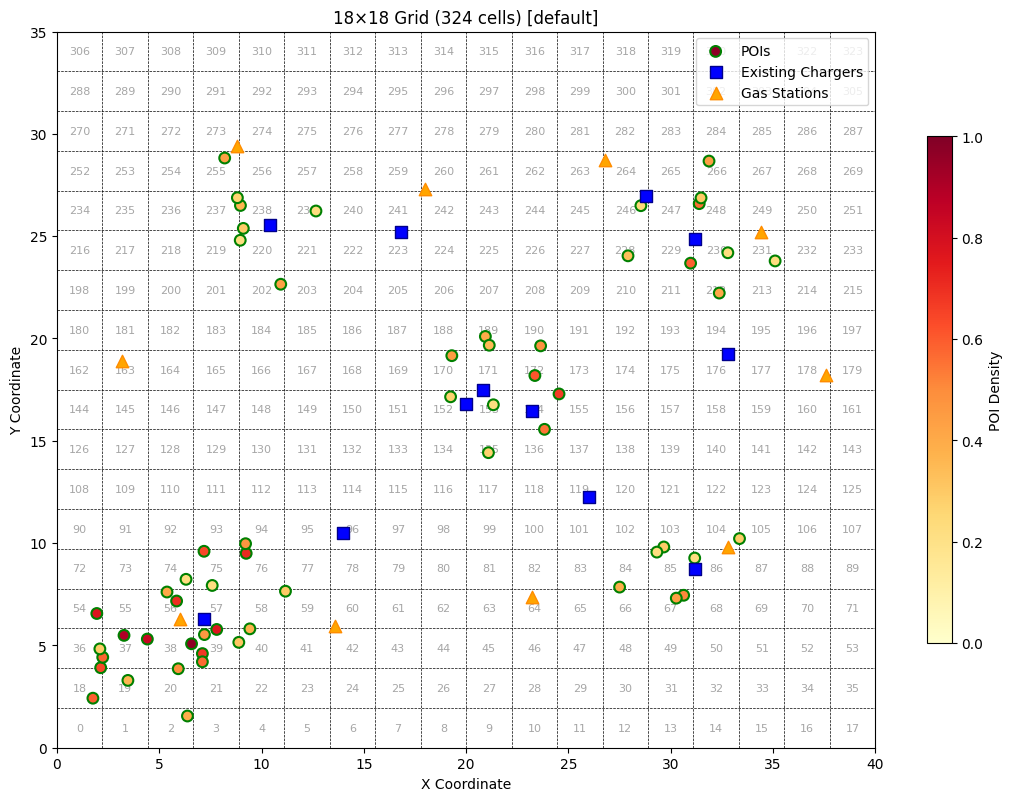

  Grid Info:
    Grid    2 (row=0, col=2): 1 POI(s) [densities: 0.39]
    Grid   18 (row=1, col=0): 1 POI(s) [densities: 0.59]
    Grid   19 (row=1, col=1): 1 POI(s) [densities: 0.36]
    Grid   20 (row=1, col=2): 1 POI(s) [densities: 0.49]
    Grid   36 (row=2, col=0): 2 POI(s) [densities: 0.64, 0.29]
    Grid   37 (row=2, col=1): 3 POI(s) [densities: 0.90, 0.84, 0.58]
    Grid   38 (row=2, col=2): 1 POI(s) [densities: 0.97]
    Grid   39 (row=2, col=3): 4 POI(s) [densities: 0.77, 0.68, 0.57, 0.46]
    Grid   40 (row=2, col=4): 2 POI(s) [densities: 0.37, 0.31]
    Grid   54 (row=3, col=0): 1 POI(s) [densities: 0.77]
    Grid   56 (row=3, col=2): 2 POI(s) [densities: 0.70, 0.41] | 1 gas station(s)
    Grid   57 (row=3, col=3): 1 charger(s)
    Grid   59 (row=3, col=5): 1 POI(s) [densities: 0.30]
    Grid   60 (row=3, col=6): 1 gas station(s)
    Grid   64 (row=3, col=10): 1 gas station(s)
    Grid   67 (row=3, col=13): 2 POI(s) [densities: 0.51, 0.44]
    Grid   74 (row=4, col=2): 1 PO

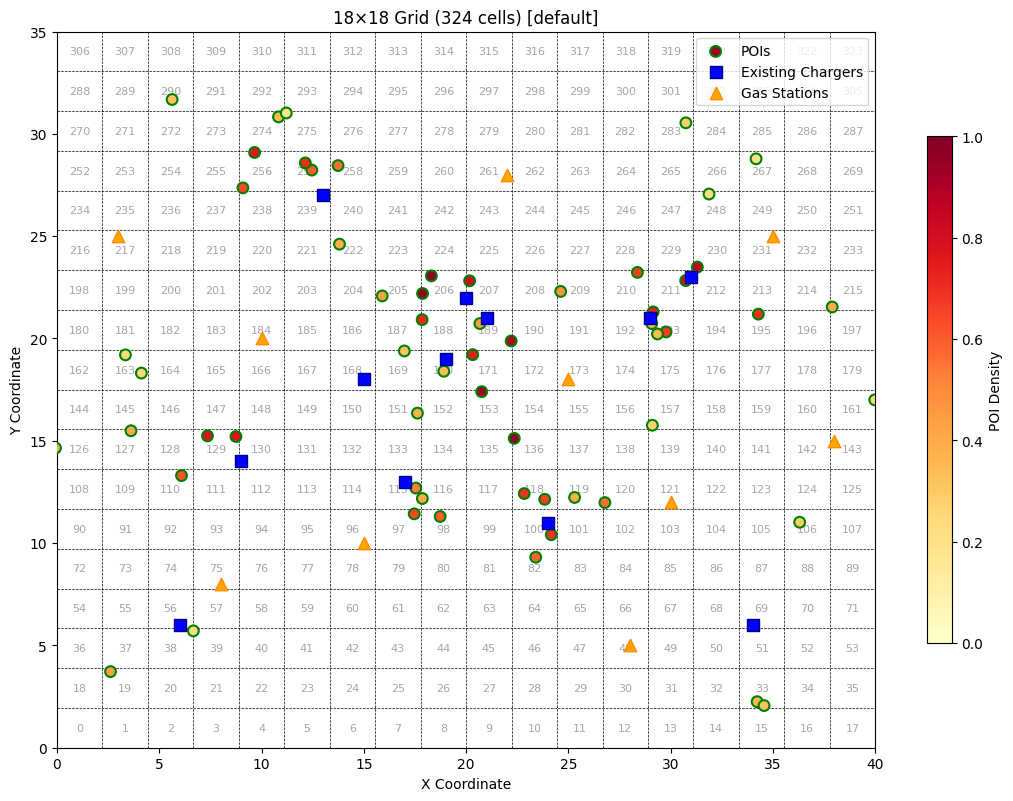

  Grid Info:
    Grid   19 (row=1, col=1): 1 POI(s) [densities: 0.43]
    Grid   33 (row=1, col=15): 2 POI(s) [densities: 0.35, 0.32]
    Grid   39 (row=2, col=3): 1 POI(s) [densities: 0.23]
    Grid   48 (row=2, col=12): 1 gas station(s)
    Grid   56 (row=3, col=2): 1 charger(s)
    Grid   69 (row=3, col=15): 1 charger(s)
    Grid   75 (row=4, col=3): 1 gas station(s)
    Grid   82 (row=4, col=10): 1 POI(s) [densities: 0.58]
    Grid   96 (row=5, col=6): 1 gas station(s)
    Grid   97 (row=5, col=7): 1 POI(s) [densities: 0.64]
    Grid   98 (row=5, col=8): 1 POI(s) [densities: 0.60]
    Grid  100 (row=5, col=10): 1 POI(s) [densities: 0.69] | 1 charger(s)
    Grid  106 (row=5, col=16): 1 POI(s) [densities: 0.28]
    Grid  110 (row=6, col=2): 1 POI(s) [densities: 0.61]
    Grid  115 (row=6, col=7): 1 POI(s) [densities: 0.53] | 1 charger(s)
    Grid  116 (row=6, col=8): 1 POI(s) [densities: 0.40]
    Grid  118 (row=6, col=10): 2 POI(s) [densities: 0.69, 0.65]
    Grid  119 (row=6, col=1

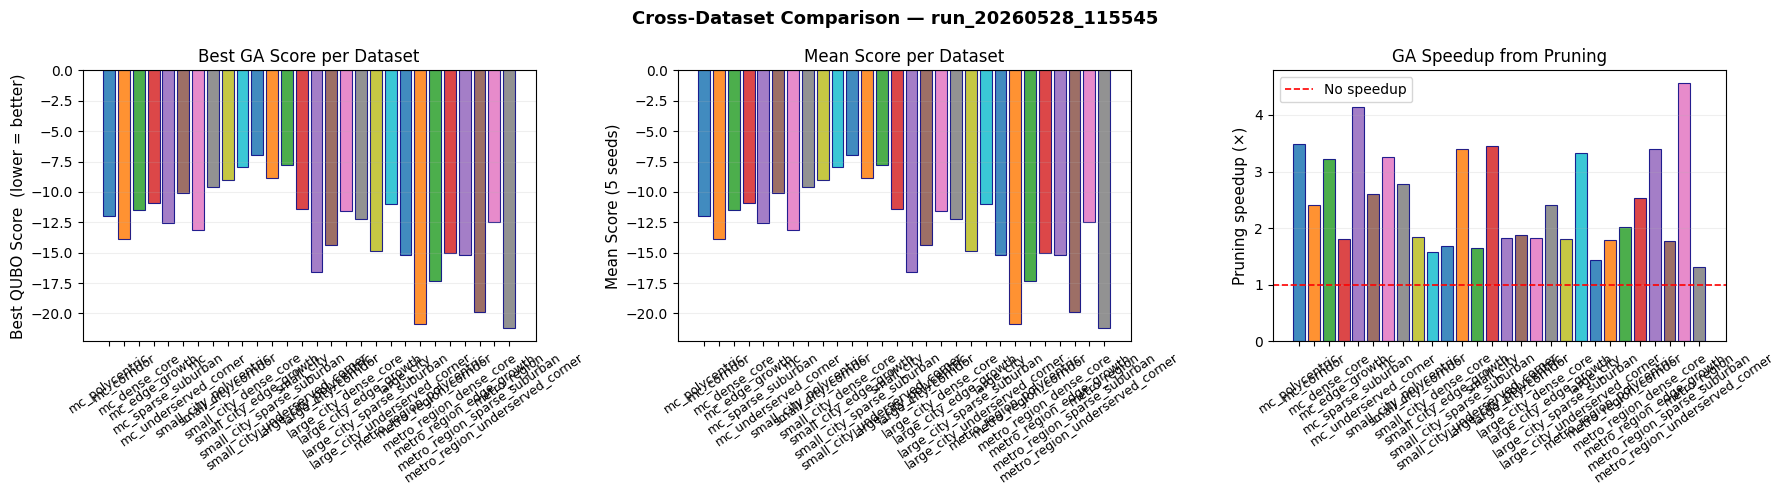

  cross_dataset_comparison.png  saved
  cross_dataset_summary.json  saved

All results → /Users/abhimuvva/Documents/Proj_HGQA/results/classical_tuning/run_20260528_115545


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Run all datasets in DATASETS registry
# Results: results/classical_tuning/{dataset_name}/
# ─────────────────────────────────────────────────────────────────────────────

_RUN_TS  = datetime.now().strftime('%Y%m%d_%H%M%S')
_RUN_DIR = _Path.cwd().parent / 'results' / 'classical_tuning' / f'run_{_RUN_TS}'
_RUN_DIR.mkdir(parents=True, exist_ok=True)

print(f'Run ID    : run_{_RUN_TS}')
print(f'Output    : {_RUN_DIR}')
print(f'Datasets  : {list(DATASETS.keys())}')
print(f'Seeds/cfg : {N_SEEDS}')
print(f'QUBO params swept : {list(QUBO_SWEEP_VALUES.keys())} — {sum(len(v) for v in QUBO_SWEEP_VALUES.values())} configs')
print(f'GA params swept   : {list(SWEEP_VALUES.keys())} + seed_mode — {sum(len(v) for v in SWEEP_VALUES.values())+2} configs')
print()

_all_summaries = {}
_t_batch = time.perf_counter()

for _ds_name, _ds_cfg in DATASETS.items():
    _ds_file   = os.path.join(DATA_DIR, _ds_cfg['file'])
    _n_qubits  = _ds_cfg['n_qubits']
    _summary   = run_one_dataset(_ds_name, _ds_file, _n_qubits, _RUN_DIR)
    _all_summaries[_ds_name] = _summary

# ── Cross-dataset comparison table ────────────────────────────────────────────
_sep2 = '=' * 90
print(f'\n{_sep2}')
print('CROSS-DATASET SUMMARY')
print(f'Run: run_{_RUN_TS}   Total time: {time.perf_counter()-_t_batch:.0f}s')
print(_sep2)

_rows = []
for _ds, _s in _all_summaries.items():
    _eff = _s['pruning_effect']
    _rows.append([
        _ds,
        _s['N'], _s['K'],
        f'{_s["pruning"]["reduction_pct"]:.0f}%',
        f'{_s["best"]["score"]:.4f}',
        str(_s['best']['cells']),
        f'{_eff["pruned"]["mean_score"]:.4f}',
        f'{_eff["full"]["mean_score"]:.4f}',
        f'{_eff["speedup"]:.1f}x',
    ])

print(tabulate(_rows,
               headers=['Dataset', 'N', 'K', 'Pruned%', 'Best', 'Best Cells',
                        'Pruned mean', 'Full mean', 'Speedup'],
               tablefmt='simple'))
print()

# ── Cross-dataset bar chart: best score per variant ───────────────────────────
_ds_labels = list(_all_summaries.keys())
_best_scores = [_all_summaries[d]['best']['score'] for d in _ds_labels]
_mean_scores = [_all_summaries[d]['pruning_effect']['pruned']['mean_score'] for d in _ds_labels]
_speedups    = [_all_summaries[d]['pruning_effect']['speedup'] for d in _ds_labels]

fig_cross, axes_c = plt.subplots(1, 3, figsize=(18, 5))

cmap_c = plt.colormaps['tab10']
cols_c = [cmap_c(i % 10) for i in range(len(_ds_labels))]
short_labels = [d.replace('medium_city_', 'mc_').replace('medium_city', 'mc') for d in _ds_labels]

axes_c[0].bar(short_labels, _best_scores, color=cols_c, edgecolor='navy', lw=0.8, alpha=0.85)
axes_c[0].set_ylabel('Best QUBO Score  (lower = better)', fontsize=11)
axes_c[0].set_title('Best GA Score per Dataset', fontsize=12)
axes_c[0].tick_params(axis='x', rotation=35, labelsize=9)
axes_c[0].grid(True, alpha=0.2, axis='y')

axes_c[1].bar(short_labels, _mean_scores, color=cols_c, edgecolor='navy', lw=0.8, alpha=0.85)
axes_c[1].set_ylabel('Mean Score (5 seeds)', fontsize=11)
axes_c[1].set_title('Mean Score per Dataset', fontsize=12)
axes_c[1].tick_params(axis='x', rotation=35, labelsize=9)
axes_c[1].grid(True, alpha=0.2, axis='y')

axes_c[2].bar(short_labels, _speedups, color=cols_c, edgecolor='navy', lw=0.8, alpha=0.85)
axes_c[2].axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='No speedup')
axes_c[2].set_ylabel('Pruning speedup (×)', fontsize=11)
axes_c[2].set_title('GA Speedup from Pruning', fontsize=12)
axes_c[2].tick_params(axis='x', rotation=35, labelsize=9)
axes_c[2].legend(fontsize=10)
axes_c[2].grid(True, alpha=0.2, axis='y')

fig_cross.suptitle(f'Cross-Dataset Comparison — run_{_RUN_TS}', fontsize=13, fontweight='bold')
plt.tight_layout()
fig_cross.savefig(_RUN_DIR / 'cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('  cross_dataset_comparison.png  saved')

# ── Save cross-dataset JSON ────────────────────────────────────────────────────
(_RUN_DIR / 'cross_dataset_summary.json').write_text(
    _json.dumps({'run_id': f'run_{_RUN_TS}', 'datasets': list(_ds_labels),
                 'summaries': _all_summaries}, indent=2, default=str)
)
print('  cross_dataset_summary.json  saved')
print(f'\nAll results → {_RUN_DIR}')
